# Structure–Activity Modeling of DPPH Antioxidants and Sulfonamide–Tyrosine–Glycine Case Studies

## Project Overview

This notebook develops and critically evaluates a quantitative structure–activity relationship (QSAR) workflow for prediction of DPPH radical-scavenging activity across a curated, chemically diverse small-molecule dataset.

The computational workflow combines:

- quality-controlled experimental DPPH activity data;
- RDKit molecular descriptors;
- 2,048-bit Morgan molecular fingerprints;
- Random Forest regression as the primary model;
- Extra Trees regression as an additional nonlinear baseline;
- random, Bemis–Murcko scaffold-aware, and DOI-grouped cross-validation;
- an internal random held-out test evaluation;
- structural applicability-domain analysis; and
- exploratory evaluation of two experimentally synthesized sulfonamide–tyrosine–glycine derivatives.

The external DPPH dataset is used for model development. Compounds 50 and 51 from the experimental BSc study are retained as separate case-study molecules and are not used for model training.

Importantly, the external training data represent broad small-molecule antioxidant chemistry rather than a peptide-specific dataset. Machine-learning predictions for Compounds 50 and 51 are therefore interpreted as exploratory case-study extrapolations and are assessed together with their structural applicability-domain status rather than treated as replacements for experimental measurements.


## Notebook Workflow

1. Project setup and imports
2. Experimental case-study provenance and activity standardization
3. External DPPH dataset provenance, loading, and quality control
4. Molecular descriptor calculation and exploratory structure–activity analysis
5. Morgan fingerprint generation and machine-learning feature preparation
6. Random cross-validation and molecular-representation comparison
7. Bemis–Murcko scaffold-aware validation
8. DOI-grouped cross-study validation
9. Additional Extra Trees nonlinear baseline
10. Scaffold-aware hyperparameter assessment
11. Internal random held-out test evaluation
12. Structural novelty and applicability-domain analysis
13. Compounds 50 and 51 case study
14. Descriptor and fingerprint interpretation
15. Export of final datasets, figures, and result tables
16. Conclusions


In [1]:
# Core scientific Python, cheminformatics, and machine-learning imports

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from rdkit import Chem, DataStructs
from rdkit.Chem import Descriptors, Lipinski, rdMolDescriptors, rdFingerprintGenerator
from rdkit.Chem.Scaffolds import MurckoScaffold

from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.model_selection import (
    GroupKFold,
    KFold,
    RandomizedSearchCV,
    cross_validate,
    train_test_split,
)

print("Imports loaded successfully.")


Imports loaded successfully.


In [2]:
# Reproducible project-path setup
#
# This resolves the project whether Jupyter is launched from the repository
# root, the notebooks folder, or the parent directory containing the project.

cwd = Path.cwd().resolve()

candidate_roots = [
    cwd,
    cwd.parent,
    cwd / "Project_1_Peptide_Antioxidant_SAR",
    cwd.parent / "Project_1_Peptide_Antioxidant_SAR",
]

project_dir = None
for candidate in candidate_roots:
    if (candidate / "data" / "raw" / "DPPH_30min_Dataset.xlsx").exists():
        project_dir = candidate
        break

if project_dir is None:
    raise FileNotFoundError(
        "Could not locate Project_1_Peptide_Antioxidant_SAR. "
        "Ensure data/raw/DPPH_30min_Dataset.xlsx exists in the project."
    )

project_root = project_dir
raw_data_dir = project_dir / "data" / "raw"
processed_data_dir = project_dir / "data" / "processed"
processed_dir = processed_data_dir
notebooks_dir = project_dir / "notebooks"
figures_dir = project_dir / "figures"
results_dir = project_dir / "results"

for folder in [processed_data_dir, notebooks_dir, figures_dir, results_dir]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project directory:", project_dir)


Project directory: C:\Users\user\Project_1_Peptide_Antioxidant_SAR


## Experimental Case-Study Provenance

The IC50 values for Compounds 50 and 51 were obtained experimentally from the
DPPH antioxidant assay conducted in the original BSc research project.

Molecular descriptors including molecular weight, LogP, hydrogen-bond donors,
hydrogen-bond acceptors, TPSA, and rotatable bonds were calculated
computationally from the molecular structures using RDKit.

These two compounds are used as experimental case-study molecules and are not
sufficient on their own for training a machine-learning model.


## Activity Standardization

Antioxidant activity values reported in different concentration units cannot be
directly compared. To obtain a consistent activity scale, IC50 values are first
converted to molar concentration and subsequently transformed to pIC50:

\[
pIC_{50} = -\log_{10}(IC_{50}\,[M])
\]

Higher pIC50 values therefore correspond to greater apparent antioxidant potency.

The IC50 values for Compounds 50 and 51 used in this section are the values
reported in the original BSc project. Because these values fall below the
lowest experimentally tested concentration, they are retained as reported
values and interpreted cautiously.

## Dataset Provenance and Study Scope

The external antioxidant dataset used in this study was obtained from the
public repository accompanying the work of Ghironi et al. (2025):

Ghironi, S., Viganò, E. L., Selvestrel, G., & Benfenati, E. (2025).
*QSAR Models for Predicting the Antioxidant Potential of Chemical Substances*.
Journal of Xenobiotics, 15(3), 80.
https://doi.org/10.3390/jox15030080

The published study reports a dataset of 1,911 chemical substances associated
with DPPH radical-scavenging IC50 measurements. The accompanying repository
provides the dataset and computational resources used in that work.

For the present analysis, the file `DPPH_30min_Dataset.xlsx` was used as the
starting dataset. After assay-time filtering and molecular-structure quality
control, 1,891 compounds were retained for modeling.

Importantly, this dataset represents a chemically diverse collection of
small-molecule antioxidants rather than a peptide-specific dataset.
Consequently, the machine-learning models developed here should be interpreted
as broad small-molecule DPPH QSAR models.

The two sulfonamide–Tyr–Gly derivatives investigated experimentally in the
underlying project are therefore treated as case-study compounds evaluated
against this broader antioxidant chemical space, rather than as members of a
peptide-trained predictive model.

The accompanying publication is distributed under the CC BY 4.0 license.
No separate license statement for the dataset itself was identified during
the present documentation review, and therefore no independent licensing
claim is made for the dataset.

## External DPPH Dataset Scope and Curation Criteria

The machine-learning analysis uses publicly available experimental antioxidant records rather than the two synthesized case-study compounds alone.

The primary curation criteria applied in this workflow are:

1. Small-molecule compounds with valid chemical structures.
2. Antioxidant activity measured using the DPPH radical-scavenging assay.
3. Quantitative IC50 measurements.
4. Clearly defined activity units.
5. Experimental records rather than purely predicted values.
6. Exclusion of undefined measurements such as "<", ">", or qualitative-only activity annotations.
7. Retention and review of assay-condition information where available to reduce experimental heterogeneity.

The external dataset is used for model development, while Compounds 50 and 51 from the original BSc project remain separately labelled experimental case-study molecules.


## External DPPH Dataset Inspection

The published DPPH dataset is first inspected in its original form before any
cleaning or transformation is performed.

This step examines the workbook structure, column names, dataset dimensions,
sample records, missing values, and potential duplicate entries.

The original file stored in `data/raw/` is not modified.

In [3]:
# Locate, load, and inspect the untouched published DPPH workbook

raw_file = raw_data_dir / "DPPH_30min_Dataset.xlsx"

print("Dataset path:", raw_file)
print("File exists:", raw_file.exists())

excel_file = pd.ExcelFile(raw_file)
print("\nWorkbook sheets:", excel_file.sheet_names)

raw_df = pd.read_excel(raw_file, sheet_name="Foglio1")
print("\nRaw dataset loaded successfully.")
print("Shape:", raw_df.shape)

print("\nOriginal column names:")
for column in raw_df.columns:
    print("-", repr(column))

print("\nSample records:")
display(raw_df.head())

print("\nDATA TYPES")
print(raw_df.dtypes)

print("\nMISSING VALUES")
print(raw_df.isna().sum())

# Remove accidental leading/trailing spaces from column names in memory only.
raw_df.columns = raw_df.columns.str.strip()

print("\nCleaned column names:")
for column in raw_df.columns:
    print("-", repr(column))


Dataset path: C:\Users\user\Project_1_Peptide_Antioxidant_SAR\data\raw\DPPH_30min_Dataset.xlsx
File exists: True

Workbook sheets: ['Foglio1']

Raw dataset loaded successfully.
Shape: (1911, 8)

Original column names:
- 'row ID'
- 'inChI'
- 'Molecular Weight'
- 'ChEMBL ID'
- 'DOI'
- 'Assay Description'
- 'minusLogIC50 (M)'
- 'Canonical SMILES '

Sample records:


,row ID,inChI,Molecular Weight,ChEMBL ID,DOI,Assay Description,minusLogIC50 (M),Canonical SMILES
0,1,InChI=1S/C18H15NO3/c20-9-19-6-5-12-8-15-18(22-...,293.3,CHEMBL1170090,10.1016/j.bmc.2010.05.045,Antioxidant activity assessed as DPPH free rad...,3.915781,O=CN1CCc2cc3c(c4c2C1Cc1ccccc1-4)OCO3
1,3,InChI=1S/C18H17N3O/c1-14-17(19-13-15-9-5-3-6-1...,291.4,CHEMBL2088268,10.1016/j.bmc.2012.04.058,Antioxidant activity assessed as DPPH free rad...,4.505011,Cc1c(N=Cc2ccccc2)c(=O)n(-c2ccccc2)n1C
2,4,InChI=1S/C18H16ClN3O/c1-13-17(20-12-14-8-10-15...,325.8,CHEMBL2088269,10.1016/j.bmc.2012.04.058,Antioxidant activity assessed as DPPH free rad...,4.499215,Cc1c(N=Cc2ccc(Cl)cc2)c(=O)n(-c2ccccc2)n1C
3,5,InChI=1S/C20H22N4O/c1-15-19(21-14-16-10-12-17(...,334.4,CHEMBL2088270,10.1016/j.bmc.2012.04.058,Antioxidant activity assessed as DPPH free rad...,5.614394,Cc1c(N=Cc2ccc(N(C)C)cc2)c(=O)n(-c2ccccc2)n1C
4,6,InChI=1S/C18H17N3O2/c1-13-17(19-12-14-8-10-16(...,307.4,CHEMBL2088271,10.1016/j.bmc.2012.04.058,Antioxidant activity assessed as DPPH free rad...,4.725842,Cc1c(N=Cc2ccc(O)cc2)c(=O)n(-c2ccccc2)n1C



DATA TYPES
row ID                 int64
inChI                    str
Molecular Weight     float64
ChEMBL ID                str
DOI                      str
Assay Description        str
minusLogIC50 (M)     float64
Canonical SMILES         str
dtype: object

MISSING VALUES
row ID               0
inChI                0
Molecular Weight     0
ChEMBL ID            0
DOI                  0
Assay Description    0
minusLogIC50 (M)     0
Canonical SMILES     0
dtype: int64

Cleaned column names:
- 'row ID'
- 'inChI'
- 'Molecular Weight'
- 'ChEMBL ID'
- 'DOI'
- 'Assay Description'
- 'minusLogIC50 (M)'
- 'Canonical SMILES'


In [4]:
# Audit duplicates, target distribution, assay descriptions, and SMILES validity

duplicate_smiles_count = raw_df["Canonical SMILES"].duplicated().sum()
unique_smiles_count = raw_df["Canonical SMILES"].nunique()

print("STRUCTURE AUDIT")
print("---------------")
print(f"Total records: {len(raw_df)}")
print(f"Unique SMILES: {unique_smiles_count}")
print(f"Duplicate SMILES records: {duplicate_smiles_count}")

target_column = "minusLogIC50 (M)"
print("\npIC50 SUMMARY")
print(raw_df[target_column].describe())

assay_counts = raw_df["Assay Description"].value_counts(dropna=False)
print("\nNumber of unique assay descriptions:", raw_df["Assay Description"].nunique())
print("Most common assay descriptions:")
print(assay_counts.head(10))

def is_valid_smiles(smiles):
    molecule = Chem.MolFromSmiles(str(smiles))
    return molecule is not None

raw_df["Valid_SMILES"] = raw_df["Canonical SMILES"].apply(is_valid_smiles)
print("\nValid SMILES:", int(raw_df["Valid_SMILES"].sum()))
print("Invalid SMILES:", int((~raw_df["Valid_SMILES"]).sum()))


STRUCTURE AUDIT
---------------
Total records: 1911
Unique SMILES: 1911
Duplicate SMILES records: 0

pIC50 SUMMARY
count    1911.000000
mean        4.152294
std         0.902748
min        -0.096910
25%         3.833423
50%         4.266572
75%         4.638272
max         7.667562
Name: minusLogIC50 (M), dtype: float64

Number of unique assay descriptions: 125
Most common assay descriptions:
Assay Description
Antioxidant activity assessed as DPPH radical scavenging activity after 30 mins                                        162
Antioxidant activity assessed as DPPH free radical scavenging activity after 30 mins                                   152
Antioxidant activity assessed as DPPH radical scavenging activity 30 min (manual check)                                145
Antioxidant activity assessed as DPPH free radical scavenging activity after 30 mins by spectrophotometric analysis     80
Antioxidant activity assessed as DPPH radical scavenging activity after 30 mins by spectrophot

In [5]:
# Harmonize DPPH assay timing and create the strict ~30-minute cohort

assay_text = raw_df["Assay Description"].str.lower()

raw_df["Mentions_DPPH"] = assay_text.str.contains("dpph", na=False)
raw_df["Mentions_30min"] = assay_text.str.contains(
    r"30\s*(?:min|mins|minute|minutes)",
    regex=True,
    na=False,
)

print("DPPH / ASSAY-TIME AUDIT")
print("-----------------------")
print("Records mentioning DPPH:", raw_df["Mentions_DPPH"].sum())
print("Records mentioning approximately 30 minutes:", raw_df["Mentions_30min"].sum())
print(
    "Records mentioning both:",
    (raw_df["Mentions_DPPH"] & raw_df["Mentions_30min"]).sum(),
)

non_30min_records = raw_df[~raw_df["Mentions_30min"]].copy()
print("\nRecords requiring assay-time review:", len(non_30min_records))
print("Unique unmatched assay descriptions:")
for description in non_30min_records["Assay Description"].unique():
    print("-", description)

non_30min_summary = non_30min_records["Assay Description"].value_counts()
print("\nNON-STRICT 30-MINUTE ASSAY RECORDS")
print(non_30min_summary)
print("Total:", non_30min_summary.sum())

strict_30min_df = raw_df[
    raw_df["Mentions_DPPH"] & raw_df["Mentions_30min"]
].copy()

print("\nOriginal dataset:", len(raw_df), "records")
print("Strict 30-minute dataset:", len(strict_30min_df), "records")
print("Separate assay-time records:", len(non_30min_records), "records")


DPPH / ASSAY-TIME AUDIT
-----------------------
Records mentioning DPPH: 1911
Records mentioning approximately 30 minutes: 1891
Records mentioning both: 1891

Records requiring assay-time review: 20
Unique unmatched assay descriptions:
- Antioxidant activity assessed as DPPH free radical scavenging activity after 30 to 60 mins by UV-vis spectrophotometric analysis
- Antioxidant activity against DPPH free radical assessed as compound able to consume half the initial amount of DPPH free radical after 30 to 60 mins by spectrophotometry
- Antioxidant activity assessed as DPPH radical scavenging activity measured up to 300 mins
- Antioxidant activity assessed as DPPH radical scavenging activity measured at 30 to 60 mins by UV-Visible spectrophotometric method

NON-STRICT 30-MINUTE ASSAY RECORDS
Assay Description
Antioxidant activity against DPPH free radical assessed as compound able to consume half the initial amount of DPPH free radical after 30 to 60 mins by spectrophotometry    9
Antiox

In [6]:
# Validate the strict cohort, inspect activity extremes, and freeze the QC-passed dataset

strict_30min_df["Valid_SMILES"] = (
    strict_30min_df["Canonical SMILES"].apply(is_valid_smiles)
)

valid_count = strict_30min_df["Valid_SMILES"].sum()
invalid_count = (~strict_30min_df["Valid_SMILES"]).sum()
print("STRICT-COHORT STRUCTURE VALIDATION")
print("----------------------------------")
print(f"Valid SMILES: {valid_count}")
print(f"Invalid SMILES: {invalid_count}")

lowest_activity = strict_30min_df.nsmallest(10, target_column)
highest_activity = strict_30min_df.nlargest(10, target_column)

print("\n10 LOWEST pIC50 VALUES")
display(lowest_activity[["row ID", "ChEMBL ID", "DOI", target_column, "Canonical SMILES"]])

print("\n10 HIGHEST pIC50 VALUES")
display(highest_activity[["row ID", "ChEMBL ID", "DOI", target_column, "Canonical SMILES"]])

# Extreme activity values are retained: inspection did not establish that they
# were erroneous, and later residual analysis explicitly evaluates extremes.
clean_df = strict_30min_df.copy()

print("\nQC-passed modelling records:", len(clean_df))


STRICT-COHORT STRUCTURE VALIDATION
----------------------------------
Valid SMILES: 1891
Invalid SMILES: 0

10 LOWEST pIC50 VALUES


,row ID,ChEMBL ID,DOI,minusLogIC50 (M),Canonical SMILES
602,717,CHEMBL3397958,10.1016/j.bmcl.2015.01.010,-0.096910,O=C(O)CCCc1nc2ccccc2c(=O)[nH]1
603,718,CHEMBL1892587,10.1016/j.bmcl.2015.01.010,-0.041393,O=C(O)CCc1nc(O)c2ccccc2n1
601,716,CHEMBL3397959,10.1016/j.bmcl.2015.01.010,0.064493,COC(=O)CCc1nc2ccccc2c(=O)[nH]1
600,715,CHEMBL3397960,10.1016/j.bmcl.2015.01.010,0.112383,COC(=O)CCCc1nc2ccccc2c(=O)[nH]1
604,719,CHEMBL3397961,10.1016/j.bmcl.2015.01.010,0.134304,O=C(CCc1nc2ccccc2c(=O)[nH]1)NN=Cc1ccccc1
605,720,CHEMBL3397962,10.1016/j.bmcl.2015.01.010,0.245652,O=C(CCCc1nc2ccccc2c(=O)[nH]1)NN=Cc1ccccc1
1379,1568,CHEMBL4210269,10.1039/C6MD00006A,0.283387,CC(C)CC(NC(=O)C(CCC(=O)O)NC(=O)CN)C(=O)O
709,826,CHEMBL14193,10.1021/acs.jnatprod.7b00085,0.322758,O=Cc1ccc(O)cc1
1378,1567,CHEMBL371315,10.1039/C6MD00006A,0.328448,NCC(=O)N1CCCC1C(=O)NC(CCC(=O)O)C(=O)O
606,721,CHEMBL3397963,10.1016/j.bmcl.2015.01.010,0.419075,O=C(CCc1nc2ccccc2c(=O)[nH]1)NN=Cc1ccc(Cl)cc1



10 HIGHEST pIC50 VALUES


,row ID,ChEMBL ID,DOI,minusLogIC50 (M),Canonical SMILES
844,967,CHEMBL242739,10.1016/j.bmcl.2008.08.016,7.667562,O=c1c(-c2ccc(O)cc2)coc2c(O)c(O)ccc12
632,747,CHEMBL3410951,10.1016/j.ejmech.2015.01.058,7.517126,Cc1c(C)c2c(c(C)c1O)CCC(C)(C(=O)NCCNc1c3c(nc4cc...
846,969,CHEMBL239156,10.1016/j.bmcl.2008.08.016,7.486782,O=c1c(-c2ccc(O)cc2)coc2cc(O)c(O)cc12
634,749,CHEMBL3410953,10.1016/j.ejmech.2015.01.058,7.390406,Cc1c(C)c2c(c(C)c1O)CCC(C)(C(=O)NCCCCCNc1c3c(nc...
638,753,CHEMBL3410957,10.1016/j.ejmech.2015.01.058,7.364516,Cc1c(C)c2c(c(C)c1O)CCC(C)(C(=O)NCCCCCCCCCCNc1c...
633,748,CHEMBL3410952,10.1016/j.ejmech.2015.01.058,7.354578,Cc1c(C)c2c(c(C)c1O)CCC(C)(C(=O)NCCCCNc1c3c(nc4...
636,751,CHEMBL3410955,10.1016/j.ejmech.2015.01.058,7.328827,Cc1c(C)c2c(c(C)c1O)CCC(C)(C(=O)NCCCCCCCNc1c3c(...
637,752,CHEMBL3410956,10.1016/j.ejmech.2015.01.058,7.325139,Cc1c(C)c2c(c(C)c1O)CCC(C)(C(=O)NCCCCCCCCNc1c3c...
635,750,CHEMBL3410954,10.1016/j.ejmech.2015.01.058,7.312471,Cc1c(C)c2c(c(C)c1O)CCC(C)(C(=O)NCCCCCCNc1c3c(n...
989,1142,CHEMBL2337361,10.1016/j.bmc.2013.01.026,6.638272,COc1cc2c(c3c1C(=O)C(=Cc1ccc(O)c(O)c1)O3)CC(C(C...



QC-passed modelling records: 1891


In [7]:
# Save the strict primary cohort and the broader-time records separately

qc_dataset_path = processed_data_dir / "dpph_strict_30min_qc.csv"
excluded_path = processed_data_dir / "dpph_non_strict_assay_time_records.csv"

clean_df.to_csv(qc_dataset_path, index=False)
non_30min_records.to_csv(excluded_path, index=False)

print("QC-passed dataset saved to:", qc_dataset_path)
print("Broader assay-time records saved to:", excluded_path)


QC-passed dataset saved to: C:\Users\user\Project_1_Peptide_Antioxidant_SAR\data\processed\dpph_strict_30min_qc.csv
Broader assay-time records saved to: C:\Users\user\Project_1_Peptide_Antioxidant_SAR\data\processed\dpph_non_strict_assay_time_records.csv


## RDKit Molecular Descriptor Generation

The published Canonical SMILES strings are converted into RDKit molecular
objects and used to independently calculate molecular descriptors.

Descriptors are recalculated rather than relying only on descriptor values
provided by the source dataset. This improves reproducibility and ensures that
all molecular features are generated consistently within the present workflow.

In [8]:
# ============================================================
# Define a function for calculating molecular descriptors
#
# Purpose:
# Convert one SMILES string into an RDKit molecule and calculate
# a set of interpretable physicochemical descriptors that may
# later be used as machine-learning features.
# ============================================================



def calculate_descriptors(smiles):
    """
    Calculate selected RDKit molecular descriptors from a SMILES string.

    Parameters
    ----------
    smiles : str
        Canonical SMILES representation of a molecule.

    Returns
    -------
    dict
        Dictionary containing calculated molecular descriptors.
    """

    # Convert the SMILES string into an RDKit molecule
    mol = Chem.MolFromSmiles(smiles)

    # Return missing values if the molecule cannot be parsed
    if mol is None:
        return {
            "RDKit_MW": None,
            "RDKit_LogP": None,
            "HBD": None,
            "HBA": None,
            "TPSA": None,
            "Rotatable_Bonds": None,
            "Aromatic_Rings": None,
            "Heavy_Atoms": None,
            "Fraction_CSP3": None
        }

    # Calculate selected physicochemical and structural descriptors
    return {
        "RDKit_MW": Descriptors.MolWt(mol),
        "RDKit_LogP": Descriptors.MolLogP(mol),
        "HBD": Lipinski.NumHDonors(mol),
        "HBA": Lipinski.NumHAcceptors(mol),
        "TPSA": Descriptors.TPSA(mol),
        "Rotatable_Bonds": Lipinski.NumRotatableBonds(mol),
        "Aromatic_Rings": rdMolDescriptors.CalcNumAromaticRings(mol),
        "Heavy_Atoms": Descriptors.HeavyAtomCount(mol),
        "Fraction_CSP3": rdMolDescriptors.CalcFractionCSP3(mol)
    }

# ============================================================
# Calculate RDKit descriptors for all 1,891 compounds
#
# Purpose:
# Apply the descriptor-generation function to every Canonical
# SMILES in the QC-passed dataset and convert the resulting
# dictionaries into a structured pandas DataFrame.
# ============================================================

descriptor_df = (
    clean_df["Canonical SMILES"]
    .apply(calculate_descriptors)
    .apply(pd.Series)
)

print("Descriptor calculation completed.")

print(f"Number of compounds: {descriptor_df.shape[0]}")
print(f"Number of calculated descriptors: {descriptor_df.shape[1]}")

descriptor_df.head()

# ============================================================
# Combine calculated descriptors with experimental DPPH data
#
# Purpose:
# Create one modelling table containing molecular structures,
# experimental pIC50 values, provenance information, and our
# independently calculated RDKit descriptors.
# ============================================================

model_df = pd.concat(
    [
        clean_df.reset_index(drop=True),
        descriptor_df.reset_index(drop=True)
    ],
    axis=1
)

print(f"Combined dataset dimensions: {model_df.shape}")

model_df.head()

# ============================================================
# Check for missing calculated descriptor values
#
# Purpose:
# Confirm that descriptor generation succeeded for all
# molecules before the dataset is used for machine learning.
# ============================================================

descriptor_missing = descriptor_df.isna().sum()

print("MISSING DESCRIPTOR VALUES")
print("-------------------------")
print(descriptor_missing)


Descriptor calculation completed.
Number of compounds: 1891
Number of calculated descriptors: 9
Combined dataset dimensions: (1891, 20)
MISSING DESCRIPTOR VALUES
-------------------------
RDKit_MW           0
RDKit_LogP         0
HBD                0
HBA                0
TPSA               0
Rotatable_Bonds    0
Aromatic_Rings     0
Heavy_Atoms        0
Fraction_CSP3      0
dtype: int64


In [9]:
# ============================================================
# Compare published and independently calculated molecular weight
#
# Purpose:
# Use molecular weight as a consistency check between the
# published structural data and our RDKit preprocessing.
# ============================================================

model_df["MW_Difference"] = (
    model_df["RDKit_MW"] -
    model_df["Molecular Weight"]
)

print("MOLECULAR WEIGHT DIFFERENCE SUMMARY")
print("-----------------------------------")

print(model_df["MW_Difference"].describe())

# ============================================================
# Quantify molecular-weight agreement between source data
# and our independently calculated RDKit values
#
# Purpose:
# Determine how many compounds show only normal rounding-level
# differences and how many have larger discrepancies that may
# reflect salts, solvates, or differing molecular forms.
# ============================================================

# Calculate the absolute molecular-weight difference
model_df["Absolute_MW_Difference"] = model_df["MW_Difference"].abs()

# Count compounds above several difference thresholds
print("MOLECULAR WEIGHT CONSISTENCY CHECK")
print("----------------------------------")

print(
    "Difference <= 0.5 g/mol:",
    (model_df["Absolute_MW_Difference"] <= 0.5).sum()
)

print(
    "Difference > 0.5 g/mol:",
    (model_df["Absolute_MW_Difference"] > 0.5).sum()
)

print(
    "Difference > 1 g/mol:",
    (model_df["Absolute_MW_Difference"] > 1).sum()
)

print(
    "Difference > 5 g/mol:",
    (model_df["Absolute_MW_Difference"] > 5).sum()
)

print(
    "Difference > 10 g/mol:",
    (model_df["Absolute_MW_Difference"] > 10).sum()
)

print(
    "Difference > 30 g/mol:",
    (model_df["Absolute_MW_Difference"] > 30).sum()
)

# ============================================================
# Inspect compounds with substantial molecular-weight differences
#
# Purpose:
# Review records where the source molecular weight differs
# substantially from the molecular weight calculated by RDKit.
#
# Absolute_MW_Difference is included so the records can be
# ranked from the largest disagreement to the smallest.
# ============================================================

# Select compounds with an absolute MW difference greater than 5 g/mol
mw_mismatch_df = model_df[
    model_df["Absolute_MW_Difference"] > 5
].copy()

print(
    "Compounds with absolute MW difference > 5 g/mol:",
    len(mw_mismatch_df)
)

# Sort the complete DataFrame first
mw_mismatch_sorted = mw_mismatch_df.sort_values(
    "Absolute_MW_Difference",
    ascending=False
)

# Display the relevant columns
mw_mismatch_sorted[
    [
        "row ID",
        "ChEMBL ID",
        "DOI",
        "Molecular Weight",
        "RDKit_MW",
        "MW_Difference",
        "Absolute_MW_Difference",
        "Canonical SMILES"
    ]
].head(30)

# ============================================================
# Summarize patterns among molecular-weight discrepancies
#
# Purpose:
# Determine whether the discrepancies cluster around particular
# mass differences, which could indicate systematic differences
# in molecular form or database representation.
# ============================================================

mw_mismatch_sorted["Rounded_MW_Difference"] = (
    mw_mismatch_sorted["MW_Difference"].round(1)
)

print("MW DIFFERENCE PATTERNS")
print("----------------------")

print(
    mw_mismatch_sorted["Rounded_MW_Difference"]
    .value_counts()
    .sort_index()
)


MOLECULAR WEIGHT DIFFERENCE SUMMARY
-----------------------------------
count    1891.000000
mean       -0.434332
std         3.887335
min       -38.089000
25%        -0.027000
50%        -0.002000
75%         0.025000
max         0.050000
Name: MW_Difference, dtype: float64
MOLECULAR WEIGHT CONSISTENCY CHECK
----------------------------------
Difference <= 0.5 g/mol: 1867
Difference > 0.5 g/mol: 24
Difference > 1 g/mol: 24
Difference > 5 g/mol: 24
Difference > 10 g/mol: 24
Difference > 30 g/mol: 21
Compounds with absolute MW difference > 5 g/mol: 24
MW DIFFERENCE PATTERNS
----------------------
Rounded_MW_Difference
-38.1     1
-36.5    11
-36.4     6
-36.0     3
-18.1     1
-18.0     2
Name: count, dtype: int64


### Molecular-Form Consistency Assessment

Comparison of source molecular weights with RDKit-calculated molecular weights
identified 24 compounds with differences greater than 5 g/mol.

The discrepancies were strongly clustered around approximately 18 and
36–38 g/mol rather than being randomly distributed. These differences are
consistent with possible variations in molecular form, such as hydration,
salt formation, counterions, or database standardization between the source
molecular-weight record and the canonical SMILES representation.

Because molecular features in the present workflow are calculated consistently
from Canonical SMILES using RDKit, these compounds were retained for modelling.
The original molecular-weight values were preserved only for provenance and
quality-control assessment.

## Exploratory Analysis of DPPH Antioxidant Activity

The distribution of experimental pIC50 values was examined before model
development to characterize the activity range, central tendency, and presence
of low- and high-activity tails within the strict 30-minute DPPH dataset.

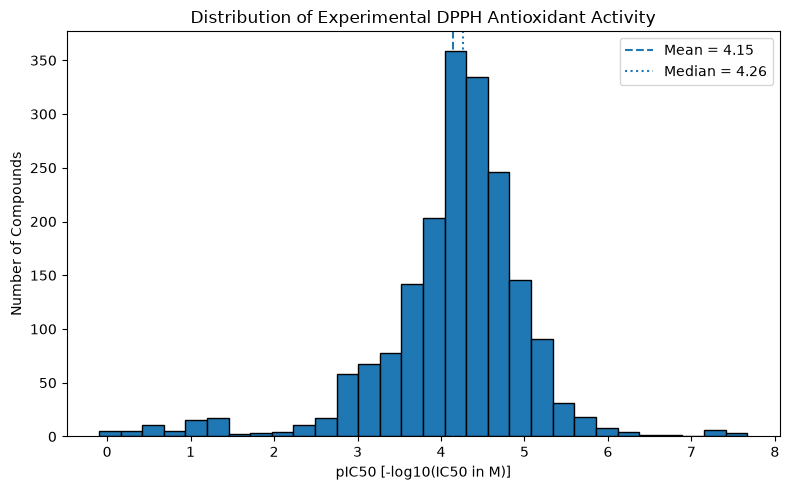

In [10]:
# ============================================================
# Plot the experimental pIC50 distribution with mean and median
#
# Purpose:
# Visualize the antioxidant-activity distribution and indicate
# the central tendency of the 1,891-compound modelling dataset.
# ============================================================


# Calculate central tendency
mean_pic50 = model_df["minusLogIC50 (M)"].mean()
median_pic50 = model_df["minusLogIC50 (M)"].median()

# Create the histogram
plt.figure(figsize=(8, 5))

plt.hist(
    model_df["minusLogIC50 (M)"],
    bins=30,
    edgecolor="black"
)

# Add mean and median reference lines
plt.axvline(
    mean_pic50,
    linestyle="--",
    label=f"Mean = {mean_pic50:.2f}"
)

plt.axvline(
    median_pic50,
    linestyle=":",
    label=f"Median = {median_pic50:.2f}"
)

plt.xlabel("pIC50 [-log10(IC50 in M)]")
plt.ylabel("Number of Compounds")
plt.title("Distribution of Experimental DPPH Antioxidant Activity")

plt.legend()
plt.tight_layout()
plt.show()


### Distribution of Molecular Size

RDKit-calculated molecular weight was examined to characterize the range of
molecular sizes represented in the DPPH antioxidant dataset.

Molecular weight is not interpreted as a direct determinant of antioxidant
activity. Instead, it provides a basic description of the chemical space
covered by the dataset.

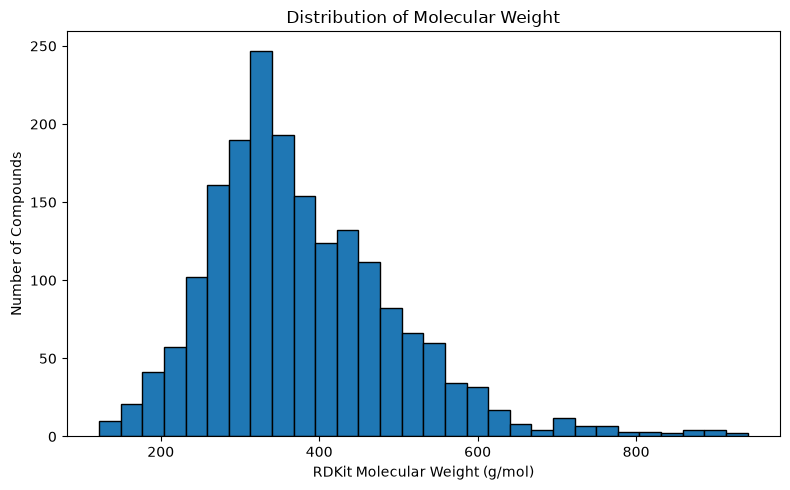

MOLECULAR WEIGHT SUMMARY
------------------------
count    1891.000000
mean      379.342981
std       121.033534
min       122.123000
25%       298.294000
50%       355.401000
75%       446.466500
max       940.681000
Name: RDKit_MW, dtype: float64


In [11]:
# ============================================================
# Plot the RDKit molecular-weight distribution
#
# Purpose:
# Examine the molecular-size range represented by the
# 1,891 antioxidant compounds.
# ============================================================

plt.figure(figsize=(8, 5))

plt.hist(
    model_df["RDKit_MW"],
    bins=30,
    edgecolor="black"
)

plt.xlabel("RDKit Molecular Weight (g/mol)")
plt.ylabel("Number of Compounds")
plt.title("Distribution of Molecular Weight")

plt.tight_layout()
plt.show()

# ============================================================
# Summarize RDKit molecular-weight values
#
# Purpose:
# Quantify the central tendency, spread, and range of molecular
# sizes represented in the modelling dataset.
# ============================================================

print("MOLECULAR WEIGHT SUMMARY")
print("------------------------")

print(model_df["RDKit_MW"].describe())


### Distribution of Molecular Lipophilicity

RDKit-calculated LogP values were examined to characterize the range of
molecular lipophilicity represented in the DPPH dataset.

LogP describes the calculated tendency of a molecule to partition between
nonpolar and aqueous environments. It is treated as a physicochemical
descriptor rather than as a direct determinant of antioxidant activity.

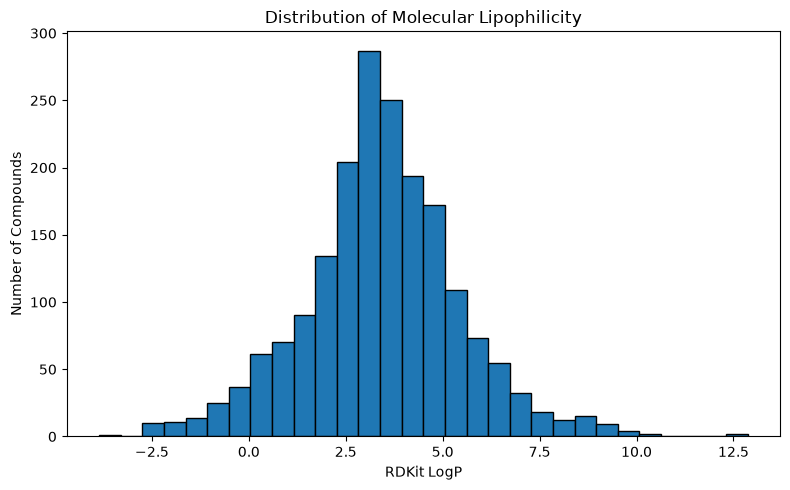

LOGP SUMMARY
------------
count    1891.000000
mean        3.422191
std         2.019109
min        -3.862900
25%         2.323300
50%         3.389300
75%         4.591820
max        12.864200
Name: RDKit_LogP, dtype: float64


In [12]:
# ============================================================
# Plot the RDKit LogP distribution
#
# Purpose:
# Examine the lipophilicity range represented by compounds in
# the 1,891-molecule strict DPPH modelling dataset.
# ============================================================

plt.figure(figsize=(8, 5))

plt.hist(
    model_df["RDKit_LogP"],
    bins=30,
    edgecolor="black"
)

plt.xlabel("RDKit LogP")
plt.ylabel("Number of Compounds")
plt.title("Distribution of Molecular Lipophilicity")

plt.tight_layout()
plt.show()

# ============================================================
# Summarize RDKit LogP values
#
# Purpose:
# Quantify the central tendency, spread, and range of calculated
# molecular lipophilicity in the modelling dataset.
# ============================================================

print("LOGP SUMMARY")
print("------------")

print(model_df["RDKit_LogP"].describe())


### Distribution of Molecular Polarity

Topological polar surface area (TPSA) was examined as an interpretable measure
of molecular polarity associated primarily with oxygen- and nitrogen-containing
functional groups.

TPSA may influence intermolecular interactions, solubility, and molecular
transport, but it is not assumed to directly determine DPPH activity.

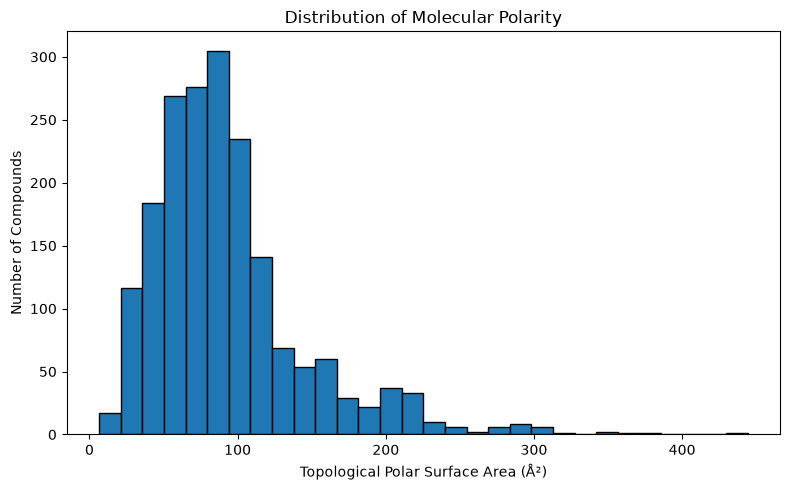

TPSA SUMMARY
------------
count    1891.000000
mean       92.883601
std        51.953938
min         6.480000
25%        58.920000
50%        83.030000
75%       110.890000
max       444.180000
Name: TPSA, dtype: float64


In [13]:
# ============================================================
# Plot the TPSA distribution
#
# Purpose:
# Examine the range of molecular polarity represented in the
# antioxidant dataset.
# ============================================================

plt.figure(figsize=(8, 5))

plt.hist(
    model_df["TPSA"],
    bins=30,
    edgecolor="black"
)

plt.xlabel("Topological Polar Surface Area (Å²)")
plt.ylabel("Number of Compounds")
plt.title("Distribution of Molecular Polarity")

plt.tight_layout()
plt.show()

# ============================================================
# Summarize TPSA values
#
# Purpose:
# Quantify the central tendency, spread, and range of molecular
# polarity represented in the modelling dataset.
# ============================================================

print("TPSA SUMMARY")
print("------------")

print(model_df["TPSA"].describe())


## Descriptor–Activity Correlation Analysis

Correlations between interpretable molecular descriptors and experimental
DPPH pIC50 values were examined to identify simple structure–activity trends
before machine-learning model development.

Both Pearson and Spearman correlation coefficients were calculated.

Pearson correlation measures linear association, whereas Spearman correlation
evaluates monotonic rank-based relationships and is less sensitive to
non-normal descriptor distributions.

Correlation does not establish causation, and weak individual correlations do
not imply that a descriptor is unimportant in multivariate or nonlinear models.

PEARSON CORRELATION WITH pIC50
--------------------------------
HBD                0.199223
Aromatic_Rings     0.119472
RDKit_MW           0.102975
HBA                0.100270
TPSA               0.094815
Heavy_Atoms        0.091475
RDKit_LogP         0.038686
Rotatable_Bonds   -0.086045
Fraction_CSP3     -0.117578
Name: minusLogIC50 (M), dtype: float64

SPEARMAN CORRELATION WITH pIC50
---------------------------------
HBD                0.292635
TPSA               0.136387
HBA                0.110401
Aromatic_Rings     0.099426
RDKit_MW           0.077423
Heavy_Atoms        0.055589
RDKit_LogP        -0.036703
Rotatable_Bonds   -0.037225
Fraction_CSP3     -0.121363
Name: minusLogIC50 (M), dtype: float64


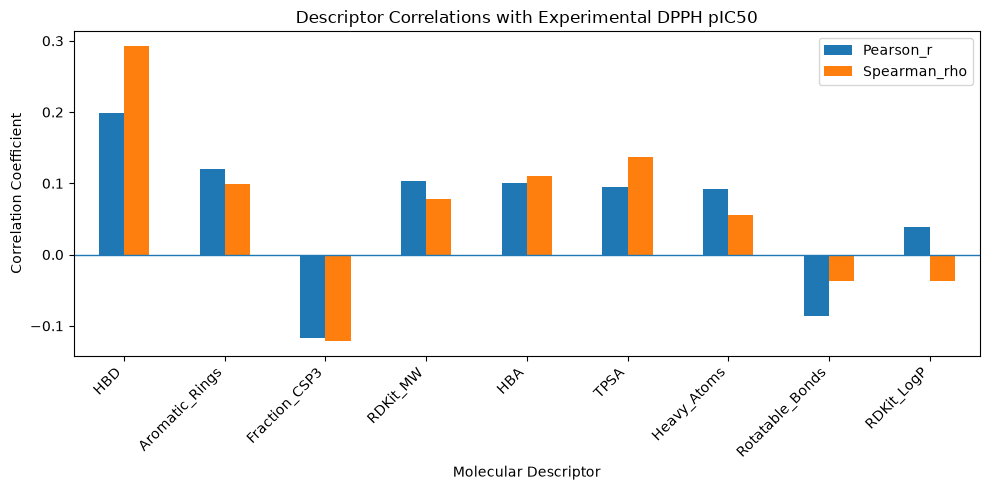

In [14]:
# ============================================================
# Calculate descriptor correlations with experimental pIC50
#
# Purpose:
# Quantify simple relationships between molecular properties
# and DPPH antioxidant activity before machine-learning
# model development.
# ============================================================

# Define the descriptors we independently calculated with RDKit
descriptor_columns = [
    "RDKit_MW",
    "RDKit_LogP",
    "HBD",
    "HBA",
    "TPSA",
    "Rotatable_Bonds",
    "Aromatic_Rings",
    "Heavy_Atoms",
    "Fraction_CSP3"
]

# Define the experimental target variable
target_column = "minusLogIC50 (M)"

# Calculate Pearson correlations with pIC50
pearson_correlations = (
    model_df[descriptor_columns + [target_column]]
    .corr(method="pearson")[target_column]
    .drop(target_column)
    .sort_values(ascending=False)
)

# Calculate Spearman correlations with pIC50
spearman_correlations = (
    model_df[descriptor_columns + [target_column]]
    .corr(method="spearman")[target_column]
    .drop(target_column)
    .sort_values(ascending=False)
)

print("PEARSON CORRELATION WITH pIC50")
print("--------------------------------")
print(pearson_correlations)

print("\nSPEARMAN CORRELATION WITH pIC50")
print("---------------------------------")
print(spearman_correlations)

# ============================================================
# Combine Pearson and Spearman correlation results
#
# Purpose:
# Create a single comparison table showing both linear and
# rank-based descriptor relationships with experimental pIC50.
# ============================================================

correlation_table = pd.DataFrame({
    "Pearson_r": pearson_correlations,
    "Spearman_rho": spearman_correlations
})

# Calculate absolute Pearson correlation for ranking purposes
correlation_table["Absolute_Pearson"] = (
    correlation_table["Pearson_r"].abs()
)

# Rank descriptors from strongest to weakest Pearson association
correlation_table = correlation_table.sort_values(
    "Absolute_Pearson",
    ascending=False
)

correlation_table

# ============================================================
# Visualize descriptor correlations with experimental pIC50
#
# Purpose:
# Compare the magnitude and direction of simple descriptor-
# activity relationships before machine-learning modelling.
# ============================================================

plot_data = correlation_table[
    ["Pearson_r", "Spearman_rho"]
]

plot_data.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.axhline(
    0,
    linewidth=1
)

plt.ylabel("Correlation Coefficient")
plt.xlabel("Molecular Descriptor")
plt.title("Descriptor Correlations with Experimental DPPH pIC50")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### Hydrogen-Bond Donor Count and Antioxidant Activity

Hydrogen-bond donor count showed the strongest individual association with
experimental DPPH pIC50 among the interpretable RDKit descriptors examined.

A boxplot was therefore used to compare the distribution of antioxidant
activity across molecules containing different numbers of hydrogen-bond
donor groups.

This analysis is exploratory and does not imply that hydrogen-bond donor
count alone causes differences in antioxidant activity.

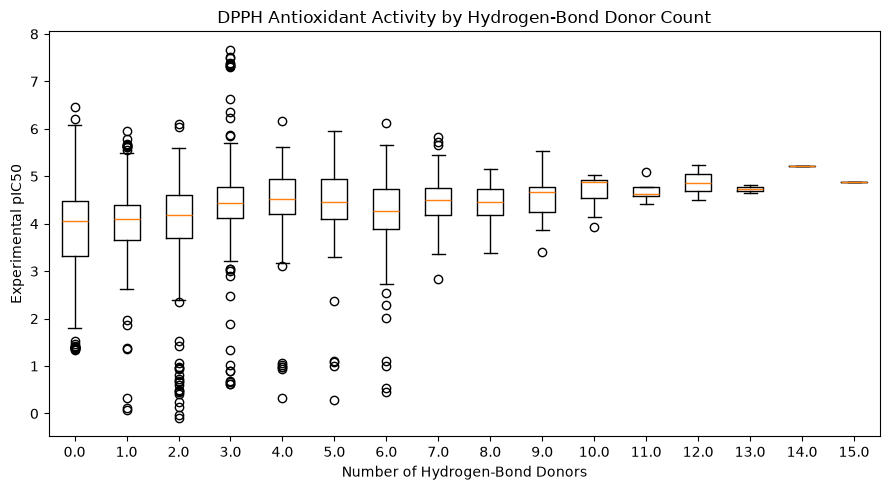

COMPOUNDS BY HBD COUNT
----------------------
HBD
0.0     236
1.0     445
2.0     451
3.0     319
4.0     180
5.0      75
6.0      70
7.0      61
8.0      27
9.0       7
10.0      9
11.0      5
12.0      2
13.0      2
14.0      1
15.0      1
Name: count, dtype: int64


In [15]:
# ============================================================
# Examine DPPH activity across hydrogen-bond donor counts
#
# Purpose:
# Visualize how experimental pIC50 values are distributed among
# compounds with different numbers of hydrogen-bond donors.
# ============================================================

# Identify the unique HBD counts represented in the dataset
hbd_values = sorted(model_df["HBD"].unique())

# Collect pIC50 values for each HBD group
hbd_groups = [
    model_df.loc[
        model_df["HBD"] == hbd,
        "minusLogIC50 (M)"
    ]
    for hbd in hbd_values
]

# Create the boxplot
plt.figure(figsize=(9, 5))

plt.boxplot(
    hbd_groups,
    tick_labels=hbd_values
)

plt.xlabel("Number of Hydrogen-Bond Donors")
plt.ylabel("Experimental pIC50")
plt.title("DPPH Antioxidant Activity by Hydrogen-Bond Donor Count")

plt.tight_layout()
plt.show()

# ============================================================
# Count compounds within each hydrogen-bond donor category
#
# Purpose:
# Determine how many compounds support each HBD group shown in
# the boxplot. Groups with very small sample sizes must be
# interpreted cautiously.
# ============================================================

hbd_counts = (
    model_df["HBD"]
    .value_counts()
    .sort_index()
)

print("COMPOUNDS BY HBD COUNT")
print("----------------------")
print(hbd_counts)


## Morgan Molecular Fingerprints

Morgan fingerprints were generated from Canonical SMILES to provide a more
detailed representation of local molecular structure than global
physicochemical descriptors alone.

The fingerprint encodes atom-centered molecular environments into a
fixed-length binary vector. These structural features can be used by
machine-learning models to distinguish molecules with similar global
properties but different functional-group arrangements and molecular topology.

In [16]:
# ============================================================
# Create a Morgan fingerprint generator
#
# Purpose:
# Represent local molecular environments as a fixed-length
# binary fingerprint suitable for machine-learning models.
# ============================================================


# Create a Morgan fingerprint generator
# radius=2 examines local atom environments out to two bond-expansion steps
# fpSize=2048 produces a fingerprint containing 2,048 binary positions
morgan_generator = rdFingerprintGenerator.GetMorganGenerator(
    radius=2,
    fpSize=2048
)

print("Morgan fingerprint generator created successfully.")

# ============================================================
# Convert Morgan fingerprints into NumPy arrays
#
# Purpose:
# Create a reusable function that converts a SMILES string
# into a 2,048-element binary Morgan fingerprint array.
# ============================================================



def smiles_to_fingerprint(smiles):
    """
    Convert a SMILES string into a 2,048-bit Morgan fingerprint
    represented as a NumPy array.
    """

    # Convert the SMILES string into an RDKit molecule
    mol = Chem.MolFromSmiles(smiles)

    # Generate the Morgan fingerprint
    fingerprint = morgan_generator.GetFingerprint(mol)

    # Create an empty array containing 2,048 zeros
    fingerprint_array = np.zeros(
        (2048,),
        dtype=np.int8
    )

    # Copy the RDKit fingerprint bits into the NumPy array
    DataStructs.ConvertToNumpyArray(
        fingerprint,
        fingerprint_array
    )

    return fingerprint_array


Morgan fingerprint generator created successfully.


### Generating the Full Morgan Fingerprint Matrix

The fingerprint conversion function was applied to all molecules in the
QC-passed DPPH dataset.

Each row of the resulting matrix represents one molecule, while each column
represents one of the 2,048 Morgan fingerprint positions.

The resulting matrix will be used as a high-dimensional structural feature
representation for machine-learning model development.

In [17]:
# ============================================================
# Generate Morgan fingerprints for all 1,891 molecules
#
# Purpose:
# Convert every molecular structure in the dataset into a
# 2,048-feature numerical fingerprint representation.
# ============================================================

fingerprint_matrix = np.vstack(
    model_df["Canonical SMILES"]
    .apply(smiles_to_fingerprint)
    .values
)

print("Fingerprint matrix generated successfully.")

print("\nMatrix shape:")
print(fingerprint_matrix.shape)


Fingerprint matrix generated successfully.

Matrix shape:
(1891, 2048)


### Morgan Fingerprint Sparsity

Morgan fingerprint vectors are typically sparse because each molecule activates
only a small fraction of the possible fingerprint positions.

The proportion of active (`1`) and inactive (`0`) fingerprint positions was
therefore examined across the complete molecular dataset.

This provides information about the structure of the feature matrix before
machine-learning model development.

In [18]:
# ============================================================
# Examine sparsity of the Morgan fingerprint matrix
#
# Purpose:
# Determine how many fingerprint positions are active across
# the full dataset and calculate overall feature-matrix sparsity.
# ============================================================

# Total number of values in the fingerprint matrix
total_positions = fingerprint_matrix.size

# Because the matrix contains only 0 and 1,
# summing the matrix gives the total number of active bits
active_positions = fingerprint_matrix.sum()

# Number of inactive fingerprint positions
inactive_positions = total_positions - active_positions

# Fraction of positions that contain 1
density = active_positions / total_positions

# Fraction of positions that contain 0
sparsity = inactive_positions / total_positions

print("FINGERPRINT MATRIX SPARSITY")
print("---------------------------")

print(f"Total fingerprint positions: {total_positions:,}")
print(f"Active positions: {active_positions:,}")
print(f"Inactive positions: {inactive_positions:,}")

print(f"\nDensity: {density:.4f}")
print(f"Sparsity: {sparsity:.4f}")

print(f"\nPercentage active: {density * 100:.2f}%")
print(f"Percentage zero: {sparsity * 100:.2f}%")

# ============================================================
# Examine active fingerprint bits per molecule
#
# Purpose:
# Determine how many structural fingerprint positions are
# activated by each individual molecule.
# ============================================================

active_bits_per_molecule = fingerprint_matrix.sum(axis=1)

print("ACTIVE BITS PER MOLECULE")
print("------------------------")

print(f"Minimum: {active_bits_per_molecule.min()}")
print(f"Maximum: {active_bits_per_molecule.max()}")
print(f"Mean: {active_bits_per_molecule.mean():.2f}")
print(f"Median: {np.median(active_bits_per_molecule):.2f}")


FINGERPRINT MATRIX SPARSITY
---------------------------
Total fingerprint positions: 3,872,768
Active positions: 84,142
Inactive positions: 3,788,626

Density: 0.0217
Sparsity: 0.9783

Percentage active: 2.17%
Percentage zero: 97.83%
ACTIVE BITS PER MOLECULE
------------------------
Minimum: 9
Maximum: 88
Mean: 44.50
Median: 44.00


### Machine-Learning Feature and Target Variables

For supervised regression modeling, the Morgan fingerprint matrix was used
as the molecular feature matrix (`X`).

The experimentally reported DPPH activity, expressed as `minusLogIC50 (M)`,
was used as the prediction target (`y`).

Therefore:

- `X` contains structural information describing each molecule.
- `y` contains the corresponding experimental antioxidant activity.

In [19]:
# ============================================================
# Define molecular features (X) and activity target (y)
#
# Purpose:
# Prepare the fingerprint representation and experimental
# pIC50 values for supervised machine-learning regression.
# ============================================================

# Molecular features
X_fp = fingerprint_matrix.copy()

# Experimental DPPH activity target
y = model_df["minusLogIC50 (M)"].to_numpy()

print("FEATURE AND TARGET DIMENSIONS")
print("-----------------------------")

print("X fingerprint shape:", X_fp.shape)
print("y target shape:", y.shape)

# ============================================================
# Verify feature-target alignment
#
# Purpose:
# Confirm that every fingerprint row has one corresponding
# experimental activity value.
# ============================================================

print("Number of molecules in X:", X_fp.shape[0])
print("Number of activity values in y:", len(y))

print("\nFirst 5 experimental pIC50 values:")
print(y[:5])


FEATURE AND TARGET DIMENSIONS
-----------------------------
X fingerprint shape: (1891, 2048)
y target shape: (1891,)
Number of molecules in X: 1891
Number of activity values in y: 1891

First 5 experimental pIC50 values:
[3.91578131 4.50501103 4.49921483 5.61439373 4.72584215]


### Random Train–Test Split

The Morgan fingerprint dataset was divided into development and test subsets using a reproducible 80:20 random split.

The 80% development subset is used for model fitting, cross-validation, representation comparison, and hyperparameter assessment. The remaining 20% is retained as an **internal random held-out test set** for later evaluation after the model configuration is fixed.

Because this test set originates from the same curated DPPH dataset, it is not treated as an external or independently collected validation dataset.

A fixed random seed was used to make the split reproducible. Because random splitting can place structurally similar molecules in both development and test subsets, scaffold-aware and DOI-grouped validation are also used as more stringent tests of generalization.


In [20]:
# Create one reproducible 80:20 random split and retain the row indices so
# every molecular representation uses exactly the same molecules.

all_indices = np.arange(len(y))

train_indices, test_indices = train_test_split(
    all_indices,
    test_size=0.20,
    random_state=42,
)

X_train_fp = X_fp[train_indices]
X_test_fp = X_fp[test_indices]
y_train = y[train_indices]
y_test = y[test_indices]

print("RANDOM TRAIN-TEST SPLIT")
print("-----------------------")
print("Training features:", X_train_fp.shape)
print("Test features:", X_test_fp.shape)
print("Training targets:", y_train.shape)
print("Test targets:", y_test.shape)


RANDOM TRAIN-TEST SPLIT
-----------------------
Training features: (1512, 2048)
Test features: (379, 2048)
Training targets: (1512,)
Test targets: (379,)


### Random Forest Fingerprint Model

A Random Forest regressor was selected as the first structure-based
machine-learning model.

Unlike the DummyRegressor, this model uses the 2,048-bit Morgan fingerprint
representation and can learn nonlinear relationships between molecular
structural features and experimental DPPH pIC50.

Model performance was first assessed by cross-validation using only the
training dataset, preserving the held-out test set for later evaluation.

### Five-Fold Cross-Validation

Model development was performed using five-fold cross-validation on the
training dataset.

The training molecules were divided into five subsets. In each iteration,
four subsets were used for model fitting and the remaining subset was used
for validation.

This process was repeated five times so that every training molecule served
as validation data once.

The held-out test dataset was not used during this stage.

In [21]:
# Define the baseline, Random Forest, five-fold CV, and common scoring metrics

dummy_model = DummyRegressor(strategy="mean")

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1,
)

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2",
}

print("Models, cross-validation, and scoring configured.")


Models, cross-validation, and scoring configured.


In [22]:
# ============================================================
# Cross-validate the DummyRegressor baseline
#
# Purpose:
# Establish baseline performance using exactly the same
# five-fold validation procedure as the real ML model.
# ============================================================


dummy_cv_results = cross_validate(
    dummy_model,
    X_train_fp,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=1
)

# Convert negative error scores back to positive errors
dummy_cv_mae = -dummy_cv_results["test_MAE"]
dummy_cv_rmse = -dummy_cv_results["test_RMSE"]
dummy_cv_r2 = dummy_cv_results["test_R2"]

print("DUMMY REGRESSOR: 5-FOLD CROSS-VALIDATION")
print("-----------------------------------------")

print(f"Mean MAE:  {dummy_cv_mae.mean():.4f}")
print(f"Mean RMSE: {dummy_cv_rmse.mean():.4f}")
print(f"Mean R²:   {dummy_cv_r2.mean():.4f}")

# ============================================================
# Cross-validate the Random Forest fingerprint model
#
# Purpose:
# Measure how well Morgan fingerprints predict experimental
# DPPH pIC50 across five validation folds.
# ============================================================

rf_cv_results = cross_validate(
    rf_model,
    X_train_fp,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=1
)

# Convert negative error scores back to positive errors
rf_cv_mae = -rf_cv_results["test_MAE"]
rf_cv_rmse = -rf_cv_results["test_RMSE"]
rf_cv_r2 = rf_cv_results["test_R2"]

print("RANDOM FOREST: 5-FOLD CROSS-VALIDATION")
print("--------------------------------------")

print(f"Mean MAE:  {rf_cv_mae.mean():.4f}")
print(f"Mean RMSE: {rf_cv_rmse.mean():.4f}")
print(f"Mean R²:   {rf_cv_r2.mean():.4f}")

# ============================================================
# Inspect Random Forest performance across all CV folds
#
# Purpose:
# Examine whether model performance is consistent across the
# five validation subsets rather than relying only on averages.
# ============================================================


rf_fold_results = pd.DataFrame({
    "Fold": [1, 2, 3, 4, 5],
    "MAE": rf_cv_mae,
    "RMSE": rf_cv_rmse,
    "R2": rf_cv_r2
})

print("RANDOM FOREST PERFORMANCE BY FOLD")
print("---------------------------------")

print(rf_fold_results)

# ============================================================
# Summarize Random Forest cross-validation performance
#
# Purpose:
# Report both average model performance and variability across
# the five random validation folds.
# ============================================================

print("RANDOM FOREST CV SUMMARY")
print("------------------------")

print(
    f"MAE:  {rf_cv_mae.mean():.4f} ± "
    f"{rf_cv_mae.std():.4f}"
)

print(
    f"RMSE: {rf_cv_rmse.mean():.4f} ± "
    f"{rf_cv_rmse.std():.4f}"
)

print(
    f"R²:   {rf_cv_r2.mean():.4f} ± "
    f"{rf_cv_r2.std():.4f}"
)


DUMMY REGRESSOR: 5-FOLD CROSS-VALIDATION
-----------------------------------------
Mean MAE:  0.6019
Mean RMSE: 0.8864
Mean R²:   -0.0024
RANDOM FOREST: 5-FOLD CROSS-VALIDATION
--------------------------------------
Mean MAE:  0.2984
Mean RMSE: 0.4757
Mean R²:   0.7106
RANDOM FOREST PERFORMANCE BY FOLD
---------------------------------
   Fold       MAE      RMSE        R2
0     1  0.304998  0.471883  0.751862
1     2  0.314976  0.512072  0.693670
2     3  0.279277  0.412429  0.733824
3     4  0.289457  0.500387  0.675581
4     5  0.303251  0.481532  0.697997
RANDOM FOREST CV SUMMARY
------------------------
MAE:  0.2984 ± 0.0126
RMSE: 0.4757 ± 0.0346
R²:   0.7106 ± 0.0280


### Descriptor-Only Molecular Representation

A descriptor-only feature matrix was prepared to determine how much
predictive information can be obtained from global physicochemical and
structural properties without using Morgan fingerprints.

The descriptor model provides a direct baseline for assessing whether
the more detailed fingerprint representation improves prediction of
experimental DPPH pIC50.

In [23]:
# Create the descriptor-only feature matrices using the same split indices

X_desc = model_df[descriptor_columns].to_numpy()

X_train_desc = X_desc[train_indices]
X_test_desc = X_desc[test_indices]

print("DESCRIPTOR FEATURE MATRIX")
print("-------------------------")
print("Full shape:", X_desc.shape)
print("Training features:", X_train_desc.shape)
print("Test features:", X_test_desc.shape)
print("Training targets aligned:", np.array_equal(y[train_indices], y_train))
print("Test targets aligned:", np.array_equal(y[test_indices], y_test))


DESCRIPTOR FEATURE MATRIX
-------------------------
Full shape: (1891, 9)
Training features: (1512, 9)
Test features: (379, 9)
Training targets aligned: True
Test targets aligned: True


### Descriptor-Only Random Forest Model

A Random Forest regressor was trained using only the nine selected RDKit
molecular descriptors.

The same model settings and five-fold cross-validation procedure used for
the Morgan fingerprint model were retained to allow a direct comparison
between global molecular descriptors and detailed structural fingerprints.

In [24]:
# ============================================================
# Create and cross-validate the descriptor-only Random Forest
#
# Purpose:
# Determine how well nine global RDKit descriptors predict
# experimental DPPH pIC50 compared with Morgan fingerprints.
# ============================================================

descriptor_rf_model = RandomForestRegressor(
    n_estimators=300,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

descriptor_cv_results = cross_validate(
    descriptor_rf_model,
    X_train_desc,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=1
)

# Convert negative error scores back to positive errors
descriptor_cv_mae = -descriptor_cv_results["test_MAE"]
descriptor_cv_rmse = -descriptor_cv_results["test_RMSE"]
descriptor_cv_r2 = descriptor_cv_results["test_R2"]

print("DESCRIPTOR RANDOM FOREST: 5-FOLD CV")
print("-----------------------------------")

print(
    f"MAE:  {descriptor_cv_mae.mean():.4f} ± "
    f"{descriptor_cv_mae.std():.4f}"
)

print(
    f"RMSE: {descriptor_cv_rmse.mean():.4f} ± "
    f"{descriptor_cv_rmse.std():.4f}"
)

print(
    f"R²:   {descriptor_cv_r2.mean():.4f} ± "
    f"{descriptor_cv_r2.std():.4f}"
)


DESCRIPTOR RANDOM FOREST: 5-FOLD CV
-----------------------------------
MAE:  0.4239 ± 0.0246
RMSE: 0.6379 ± 0.0505
R²:   0.4767 ± 0.0748


### Comparison of Molecular Representations

The predictive performance of the mean-prediction baseline, the
descriptor-based Random Forest, and the Morgan fingerprint-based Random
Forest was compared using the same five-fold random cross-validation
framework.

This comparison evaluates whether increasingly detailed molecular
representations provide additional information for prediction of
experimental DPPH pIC50.

In [25]:
# ============================================================
# Compare cross-validation performance across model types
#
# Purpose:
# Summarize the predictive performance of the dummy baseline,
# descriptor-based model, and fingerprint-based model.
# ============================================================

model_comparison = pd.DataFrame({
    "Model": [
        "DummyRegressor",
        "Descriptor Random Forest",
        "Morgan Fingerprint Random Forest"
    ],

    "Mean_MAE": [
        dummy_cv_mae.mean(),
        descriptor_cv_mae.mean(),
        rf_cv_mae.mean()
    ],

    "SD_MAE": [
        dummy_cv_mae.std(),
        descriptor_cv_mae.std(),
        rf_cv_mae.std()
    ],

    "Mean_RMSE": [
        dummy_cv_rmse.mean(),
        descriptor_cv_rmse.mean(),
        rf_cv_rmse.mean()
    ],

    "SD_RMSE": [
        dummy_cv_rmse.std(),
        descriptor_cv_rmse.std(),
        rf_cv_rmse.std()
    ],

    "Mean_R2": [
        dummy_cv_r2.mean(),
        descriptor_cv_r2.mean(),
        rf_cv_r2.mean()
    ],

    "SD_R2": [
        dummy_cv_r2.std(),
        descriptor_cv_r2.std(),
        rf_cv_r2.std()
    ]
})

model_comparison


,Model,Mean_MAE,SD_MAE,Mean_RMSE,SD_RMSE,Mean_R2,SD_R2
0,DummyRegressor,0.601857,0.028453,0.886419,0.051571,-0.002379,0.002458
1,Descriptor Random Forest,0.423866,0.024554,0.637861,0.050502,0.476663,0.074792
2,Morgan Fingerprint Random Forest,0.298392,0.012550,0.475661,0.034595,0.710587,0.027978


### Comparison of Random Cross-Validation Performance

Model performance was compared across the mean-prediction baseline,
descriptor-based Random Forest, and Morgan fingerprint-based Random Forest.

Higher R² values indicate improved ability to explain variation in experimental
DPPH pIC50, whereas lower MAE and RMSE values indicate smaller prediction errors.

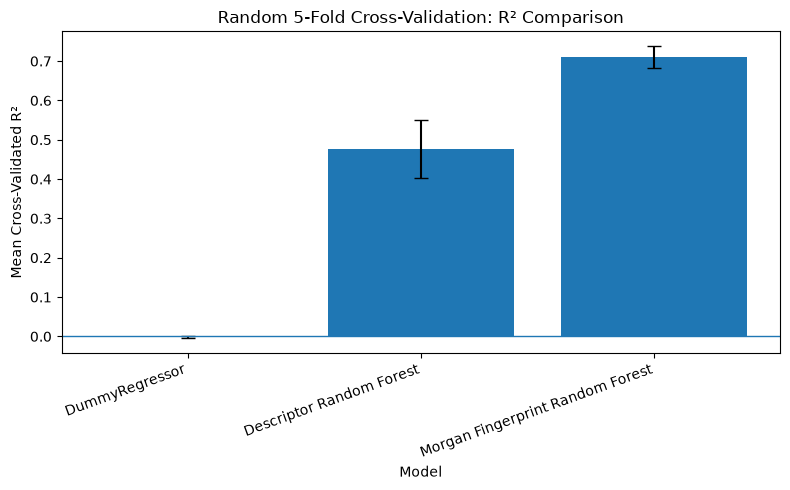

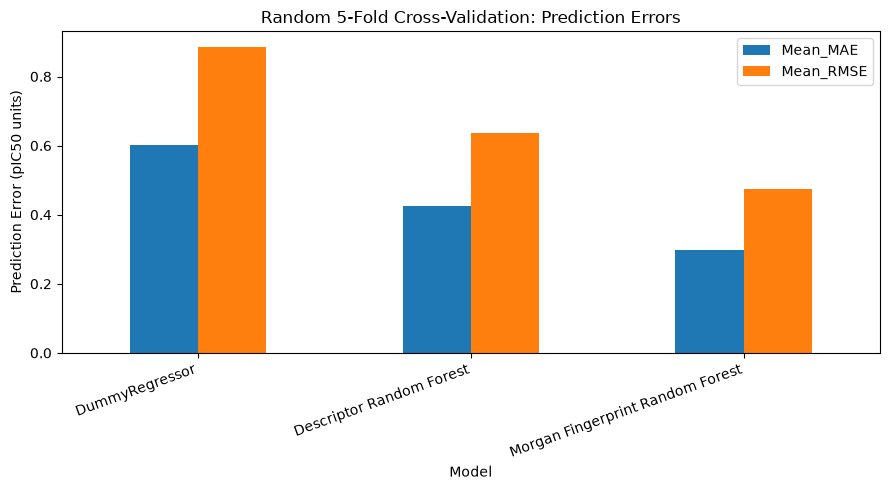

In [26]:
# ============================================================
# Plot cross-validation R² for the three model approaches
#
# Purpose:
# Visually compare the amount of experimental pIC50 variation
# explained by each molecular representation.
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    model_comparison["Model"],
    model_comparison["Mean_R2"],
    yerr=model_comparison["SD_R2"],
    capsize=5
)

# Reference line corresponding to no improvement over mean prediction
plt.axhline(0, linewidth=1)

plt.ylabel("Mean Cross-Validated R²")
plt.xlabel("Model")
plt.title("Random 5-Fold Cross-Validation: R² Comparison")

plt.xticks(rotation=20, ha="right")

plt.tight_layout()
plt.show()

# ============================================================
# Plot MAE and RMSE across the three modeling approaches
#
# Purpose:
# Compare prediction errors obtained from increasingly detailed
# molecular representations.
# ============================================================

error_comparison = model_comparison.set_index("Model")[
    ["Mean_MAE", "Mean_RMSE"]
]

error_comparison.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.ylabel("Prediction Error (pIC50 units)")
plt.xlabel("Model")
plt.title("Random 5-Fold Cross-Validation: Prediction Errors")

plt.xticks(rotation=20, ha="right")

plt.tight_layout()
plt.show()


## Bemis–Murcko Scaffold Analysis

Bemis–Murcko scaffolds were generated from the Canonical SMILES structures
to identify molecules sharing common core ring-and-linker frameworks.

Scaffold information will be used to perform a more stringent validation
in which molecules belonging to the same scaffold family are kept within
the same fold.

This reduces the possibility that closely related structural analogues
appear in both training and validation subsets.

In [27]:
# ============================================================
# Generate Bemis-Murcko molecular scaffolds
#
# Purpose:
# Extract the core ring-and-linker framework from each molecule
# so that structurally related compounds can be grouped together.
# ============================================================



def get_murcko_scaffold(smiles):
    """
    Generate the Bemis-Murcko scaffold SMILES for a molecule.
    """

    # Convert SMILES into an RDKit molecule
    mol = Chem.MolFromSmiles(smiles)

    # Generate the core scaffold
    scaffold = MurckoScaffold.MurckoScaffoldSmiles(
        mol=mol,
        includeChirality=False
    )

    return scaffold

# ============================================================
# Generate scaffolds for the complete QC-passed dataset
#
# Purpose:
# Assign each molecule to its corresponding structural
# scaffold before scaffold-aware validation.
# ============================================================

model_df["Murcko_Scaffold"] = (
    model_df["Canonical SMILES"]
    .apply(get_murcko_scaffold)
)

print("Murcko scaffolds generated successfully.")

print("\nFirst 10 scaffold SMILES:")
print(
    model_df[
        ["Canonical SMILES", "Murcko_Scaffold"]
    ].head(10)
)

# ============================================================
# Examine scaffold diversity and group sizes
#
# Purpose:
# Determine how many distinct structural frameworks are present
# and whether particular scaffolds dominate the dataset.
# ============================================================

scaffold_counts = (
    model_df["Murcko_Scaffold"]
    .value_counts()
)

number_unique_scaffolds = model_df["Murcko_Scaffold"].nunique()

empty_scaffold_count = (
    model_df["Murcko_Scaffold"] == ""
).sum()

print("SCAFFOLD SUMMARY")
print("----------------")

print("Total molecules:", len(model_df))
print("Unique Murcko scaffolds:", number_unique_scaffolds)
print("Molecules with empty scaffold:", empty_scaffold_count)

print("\n10 largest scaffold groups:")
print(scaffold_counts.head(10))


Murcko scaffolds generated successfully.

First 10 scaffold SMILES:
                               Canonical SMILES  \
0          O=CN1CCc2cc3c(c4c2C1Cc1ccccc1-4)OCO3   
1         Cc1c(N=Cc2ccccc2)c(=O)n(-c2ccccc2)n1C   
2     Cc1c(N=Cc2ccc(Cl)cc2)c(=O)n(-c2ccccc2)n1C   
3  Cc1c(N=Cc2ccc(N(C)C)cc2)c(=O)n(-c2ccccc2)n1C   
4      Cc1c(N=Cc2ccc(O)cc2)c(=O)n(-c2ccccc2)n1C   
5     COc1ccc(C=Nc2c(C)n(C)n(-c3ccccc3)c2=O)cc1   
6   Cc1c(N=Cc2ccc(O)c(O)c2)c(=O)n(-c2ccccc2)n1C   
7    COc1cc(C=Nc2c(C)n(C)n(-c3ccccc3)c2=O)ccc1O   
8   COc1ccc(C=Nc2c(C)n(C)n(-c3ccccc3)c2=O)cc1OC   
9     Cc1c(N=Cc2ccc(O)cc2O)c(=O)n(-c2ccccc2)n1C   

                       Murcko_Scaffold  
0  c1ccc2c(c1)CC1NCCc3cc4c(c-2c31)OCO4  
1   O=c1c(N=Cc2ccccc2)c[nH]n1-c1ccccc1  
2   O=c1c(N=Cc2ccccc2)c[nH]n1-c1ccccc1  
3   O=c1c(N=Cc2ccccc2)c[nH]n1-c1ccccc1  
4   O=c1c(N=Cc2ccccc2)c[nH]n1-c1ccccc1  
5   O=c1c(N=Cc2ccccc2)c[nH]n1-c1ccccc1  
6   O=c1c(N=Cc2ccccc2)c[nH]n1-c1ccccc1  
7   O=c1c(N=Cc2ccccc2)c[nH]n1-c1ccccc1  
8

### Scaffold Group-Size Distribution

The number of molecules associated with each Bemis–Murcko scaffold was
examined before scaffold-aware cross-validation.

This analysis determines whether the dataset is dominated by a few large
chemical series or contains many small and singleton scaffold families.

In [28]:
# ============================================================
# Examine Murcko scaffold group-size distribution
#
# Purpose:
# Determine how many scaffold families contain one molecule,
# multiple molecules, or larger analogue series.
# ============================================================

# Number of scaffold groups containing exactly one molecule
singleton_scaffolds = (scaffold_counts == 1).sum()

# Number containing at least two molecules
multi_member_scaffolds = (scaffold_counts >= 2).sum()

# Larger scaffold families
scaffolds_ge_5 = (scaffold_counts >= 5).sum()
scaffolds_ge_10 = (scaffold_counts >= 10).sum()

print("SCAFFOLD GROUP-SIZE DISTRIBUTION")
print("--------------------------------")

print("Total unique scaffolds:", len(scaffold_counts))
print("Singleton scaffolds:", singleton_scaffolds)
print("Scaffolds with >= 2 molecules:", multi_member_scaffolds)
print("Scaffolds with >= 5 molecules:", scaffolds_ge_5)
print("Scaffolds with >= 10 molecules:", scaffolds_ge_10)

print("\nMedian molecules per scaffold:",
      scaffold_counts.median())

print("Mean molecules per scaffold:",
      scaffold_counts.mean())

print("Largest scaffold group:",
      scaffold_counts.max())


SCAFFOLD GROUP-SIZE DISTRIBUTION
--------------------------------
Total unique scaffolds: 628
Singleton scaffolds: 361
Scaffolds with >= 2 molecules: 267
Scaffolds with >= 5 molecules: 89
Scaffolds with >= 10 molecules: 39

Median molecules per scaffold: 1.0
Mean molecules per scaffold: 3.011146496815287
Largest scaffold group: 110


### Scaffold-Aware Five-Fold Cross-Validation

To provide a more stringent assessment of molecular generalization,
five-fold cross-validation was performed using Bemis–Murcko scaffold
groups.

All molecules sharing the same Murcko scaffold were assigned to the same
fold. This prevents molecules from the same core scaffold family from
appearing simultaneously in training and validation subsets.

This validation is more demanding than ordinary random cross-validation
because the model must predict molecules belonging to held-out scaffold
families.

In [29]:
# ============================================================
# Define scaffold-aware five-fold cross-validation
#
# Purpose:
# Ensure that molecules sharing the same Murcko scaffold remain
# together during model training and validation.
# ============================================================


# Scaffold identity for every molecule
scaffold_groups = model_df["Murcko_Scaffold"].to_numpy()

# Five-fold grouped cross-validation
scaffold_cv = GroupKFold(
    n_splits=5
)

print("Scaffold-aware five-fold CV created successfully.")

print("Number of molecules:", len(scaffold_groups))
print("Number of unique scaffold groups:",
      len(np.unique(scaffold_groups)))

# ============================================================
# Extract scaffold groups for the training dataset
#
# Purpose:
# Align every training molecule with its corresponding Murcko
# scaffold identity for scaffold-aware cross-validation.
# ============================================================

train_scaffold_groups = scaffold_groups[train_indices]

print("TRAINING SCAFFOLD ALIGNMENT")
print("---------------------------")

print("Training molecules:", X_train_fp.shape[0])
print("Training scaffold labels:", len(train_scaffold_groups))

print(
    "Unique scaffolds in training set:",
    len(np.unique(train_scaffold_groups))
)


Scaffold-aware five-fold CV created successfully.
Number of molecules: 1891
Number of unique scaffold groups: 628
TRAINING SCAFFOLD ALIGNMENT
---------------------------
Training molecules: 1512
Training scaffold labels: 1512
Unique scaffolds in training set: 543


### Verification of Scaffold Separation

Before model evaluation, each scaffold-aware fold was inspected to confirm
that no Bemis–Murcko scaffold occurred simultaneously in its training and
validation subsets.

A scaffold overlap of zero confirms that complete scaffold families are
being withheld during validation.

In [30]:
# ============================================================
# Verify scaffold separation across all five folds
#
# Purpose:
# Confirm that no Murcko scaffold appears in both the training
# and validation portions of any scaffold-aware CV fold.
# ============================================================

for fold_number, (fold_train_idx, fold_val_idx) in enumerate(
    scaffold_cv.split(
        X_train_fp,
        y_train,
        groups=train_scaffold_groups
    ),
    start=1
):

    # Scaffold identities in each portion of the fold
    fold_train_scaffolds = set(
        train_scaffold_groups[fold_train_idx]
    )

    fold_val_scaffolds = set(
        train_scaffold_groups[fold_val_idx]
    )

    # Find any scaffold appearing on both sides
    scaffold_overlap = (
        fold_train_scaffolds
        .intersection(fold_val_scaffolds)
    )

    print(f"Fold {fold_number}")
    print(
        "  Training molecules:",
        len(fold_train_idx)
    )
    print(
        "  Validation molecules:",
        len(fold_val_idx)
    )
    print(
        "  Training scaffolds:",
        len(fold_train_scaffolds)
    )
    print(
        "  Validation scaffolds:",
        len(fold_val_scaffolds)
    )
    print(
        "  Scaffold overlap:",
        len(scaffold_overlap)
    )
    print()


Fold 1
  Training molecules: 1209
  Validation molecules: 303
  Training scaffolds: 437
  Validation scaffolds: 106
  Scaffold overlap: 0

Fold 2
  Training molecules: 1209
  Validation molecules: 303
  Training scaffolds: 435
  Validation scaffolds: 108
  Scaffold overlap: 0

Fold 3
  Training molecules: 1210
  Validation molecules: 302
  Training scaffolds: 434
  Validation scaffolds: 109
  Scaffold overlap: 0

Fold 4
  Training molecules: 1210
  Validation molecules: 302
  Training scaffolds: 433
  Validation scaffolds: 110
  Scaffold overlap: 0

Fold 5
  Training molecules: 1210
  Validation molecules: 302
  Training scaffolds: 433
  Validation scaffolds: 110
  Scaffold overlap: 0



### Morgan Fingerprint Random Forest under Scaffold-Aware Validation

The Morgan fingerprint Random Forest was evaluated using five-fold
Bemis–Murcko scaffold-aware cross-validation.

Unlike random cross-validation, complete scaffold families were withheld
from each validation fold. This provides a more stringent assessment of
whether the model can generalize to molecules containing core structural
frameworks not represented in the corresponding training fold.

In [31]:
# ============================================================
# Scaffold-aware cross-validation of Morgan Random Forest
#
# Purpose:
# Evaluate fingerprint-based prediction when complete Murcko
# scaffold families are withheld from model training.
# ============================================================

rf_scaffold_cv_results = cross_validate(
    rf_model,
    X_train_fp,
    y_train,
    groups=train_scaffold_groups,
    cv=scaffold_cv,
    scoring=scoring,
    n_jobs=1
)

# Convert negative error scores back to positive values
rf_scaffold_mae = -rf_scaffold_cv_results["test_MAE"]
rf_scaffold_rmse = -rf_scaffold_cv_results["test_RMSE"]
rf_scaffold_r2 = rf_scaffold_cv_results["test_R2"]

print("MORGAN RANDOM FOREST: SCAFFOLD-AWARE 5-FOLD CV")
print("------------------------------------------------")

print(
    f"MAE:  {rf_scaffold_mae.mean():.4f} ± "
    f"{rf_scaffold_mae.std():.4f}"
)

print(
    f"RMSE: {rf_scaffold_rmse.mean():.4f} ± "
    f"{rf_scaffold_rmse.std():.4f}"
)

print(
    f"R²:   {rf_scaffold_r2.mean():.4f} ± "
    f"{rf_scaffold_r2.std():.4f}"
)


MORGAN RANDOM FOREST: SCAFFOLD-AWARE 5-FOLD CV
------------------------------------------------
MAE:  0.4352 ± 0.0802
RMSE: 0.6591 ± 0.1583
R²:   0.4272 ± 0.1732


### Performance Across Scaffold-Aware Validation Folds

Individual scaffold-validation folds were examined to determine whether
predictive performance was consistent across different held-out structural
families.

Large differences between folds indicate that some scaffold groups are
substantially more difficult to generalize to than others.

In [32]:
# ============================================================
# Inspect performance across scaffold-aware CV folds
#
# Purpose:
# Determine how prediction performance changes depending on
# which scaffold families are withheld from model training.
# ============================================================

scaffold_fold_results = pd.DataFrame({
    "Fold": [1, 2, 3, 4, 5],
    "MAE": rf_scaffold_mae,
    "RMSE": rf_scaffold_rmse,
    "R2": rf_scaffold_r2
})

print("MORGAN RANDOM FOREST: SCAFFOLD CV BY FOLD")
print("-----------------------------------------")

print(scaffold_fold_results)

# ============================================================
# Compare random and scaffold-aware validation
#
# Purpose:
# Quantify how model performance changes when structurally
# related scaffold families are prevented from crossing folds.
# ============================================================

validation_comparison = pd.DataFrame({
    "Validation": [
        "Random 5-Fold CV",
        "Scaffold-Aware 5-Fold CV"
    ],

    "Mean_MAE": [
        rf_cv_mae.mean(),
        rf_scaffold_mae.mean()
    ],

    "SD_MAE": [
        rf_cv_mae.std(),
        rf_scaffold_mae.std()
    ],

    "Mean_RMSE": [
        rf_cv_rmse.mean(),
        rf_scaffold_rmse.mean()
    ],

    "SD_RMSE": [
        rf_cv_rmse.std(),
        rf_scaffold_rmse.std()
    ],

    "Mean_R2": [
        rf_cv_r2.mean(),
        rf_scaffold_r2.mean()
    ],

    "SD_R2": [
        rf_cv_r2.std(),
        rf_scaffold_r2.std()
    ]
})

validation_comparison


MORGAN RANDOM FOREST: SCAFFOLD CV BY FOLD
-----------------------------------------
   Fold       MAE      RMSE        R2
0     1  0.544108  0.876498  0.212304
1     2  0.313208  0.468468  0.680889
2     3  0.408666  0.554482  0.573241
3     4  0.499427  0.815821  0.311409
4     5  0.410424  0.580011  0.358015


,Validation,Mean_MAE,SD_MAE,Mean_RMSE,SD_RMSE,Mean_R2,SD_R2
0,Random 5-Fold CV,0.298392,0.012550,0.475661,0.034595,0.710587,0.027978
1,Scaffold-Aware 5-Fold CV,0.435167,0.080232,0.659056,0.158344,0.427172,0.173240


### Comparison of Molecular Representations under Scaffold-Aware Validation

The DummyRegressor, descriptor-based Random Forest, and Morgan fingerprint
Random Forest were evaluated using the same Bemis–Murcko scaffold-aware
cross-validation folds.

This comparison determines whether detailed fingerprint information provides
additional predictive value when models are required to generalize to
held-out scaffold families.

In [33]:
# ============================================================
# Scaffold-aware cross-validation of the DummyRegressor
#
# Purpose:
# Establish the scaffold-validation baseline using exactly the
# same grouped folds as the structure-based models.
# ============================================================

dummy_scaffold_results = cross_validate(
    dummy_model,
    X_train_fp,
    y_train,
    groups=train_scaffold_groups,
    cv=scaffold_cv,
    scoring=scoring,
    n_jobs=1
)

# Convert negative error scores back to positive values
dummy_scaffold_mae = -dummy_scaffold_results["test_MAE"]
dummy_scaffold_rmse = -dummy_scaffold_results["test_RMSE"]
dummy_scaffold_r2 = dummy_scaffold_results["test_R2"]

print("DUMMY REGRESSOR: SCAFFOLD-AWARE 5-FOLD CV")
print("------------------------------------------")

print(
    f"MAE:  {dummy_scaffold_mae.mean():.4f} ± "
    f"{dummy_scaffold_mae.std():.4f}"
)

print(
    f"RMSE: {dummy_scaffold_rmse.mean():.4f} ± "
    f"{dummy_scaffold_rmse.std():.4f}"
)

print(
    f"R²:   {dummy_scaffold_r2.mean():.4f} ± "
    f"{dummy_scaffold_r2.std():.4f}"
)

# ============================================================
# Scaffold-aware cross-validation of descriptor Random Forest
#
# Purpose:
# Test whether nine global molecular descriptors can predict
# pIC50 when complete scaffold families are withheld.
# ============================================================

descriptor_scaffold_results = cross_validate(
    descriptor_rf_model,
    X_train_desc,
    y_train,
    groups=train_scaffold_groups,
    cv=scaffold_cv,
    scoring=scoring,
    n_jobs=1
)

# Convert negative error scores back to positive values
descriptor_scaffold_mae = -descriptor_scaffold_results["test_MAE"]
descriptor_scaffold_rmse = -descriptor_scaffold_results["test_RMSE"]
descriptor_scaffold_r2 = descriptor_scaffold_results["test_R2"]

print("DESCRIPTOR RANDOM FOREST: SCAFFOLD-AWARE 5-FOLD CV")
print("---------------------------------------------------")

print(
    f"MAE:  {descriptor_scaffold_mae.mean():.4f} ± "
    f"{descriptor_scaffold_mae.std():.4f}"
)

print(
    f"RMSE: {descriptor_scaffold_rmse.mean():.4f} ± "
    f"{descriptor_scaffold_rmse.std():.4f}"
)

print(
    f"R²:   {descriptor_scaffold_r2.mean():.4f} ± "
    f"{descriptor_scaffold_r2.std():.4f}"
)


DUMMY REGRESSOR: SCAFFOLD-AWARE 5-FOLD CV
------------------------------------------
MAE:  0.6038 ± 0.0682
RMSE: 0.8862 ± 0.0980
R²:   -0.0279 ± 0.0169
DESCRIPTOR RANDOM FOREST: SCAFFOLD-AWARE 5-FOLD CV
---------------------------------------------------
MAE:  0.5596 ± 0.0921
RMSE: 0.8073 ± 0.1306
R²:   0.1454 ± 0.1469


### Summary of Molecular Representation and Validation Experiments

Model performance was summarized across both random and scaffold-aware
five-fold cross-validation.

The comparison enables assessment of two factors:

1. whether molecular structural representations improve prediction relative
   to a mean-prediction baseline; and

2. how predictive performance changes when complete molecular scaffold
   families are withheld during validation.

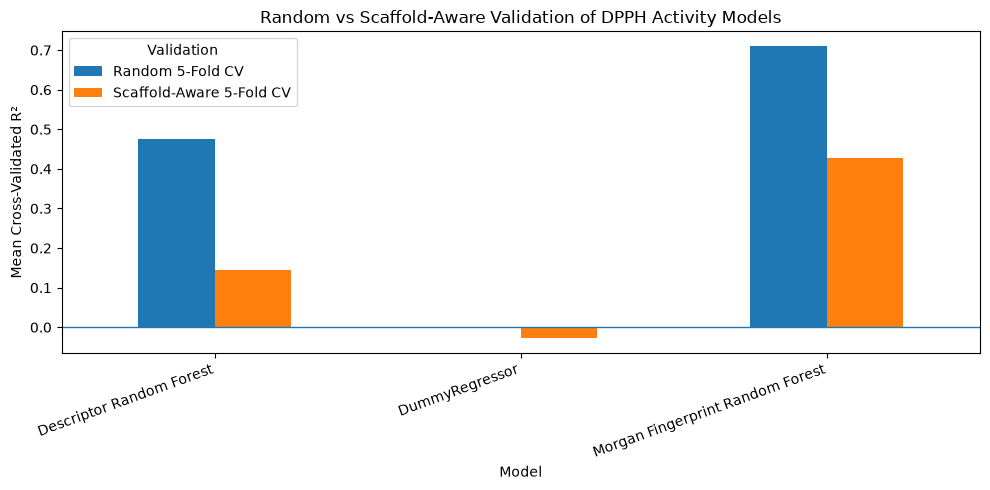

In [34]:
# ============================================================
# Create a complete model-validation comparison table
#
# Purpose:
# Summarize the performance of all three modeling approaches
# under both random and scaffold-aware cross-validation.
# ============================================================

complete_model_comparison = pd.DataFrame({

    "Model": [
        "DummyRegressor",
        "Descriptor Random Forest",
        "Morgan Fingerprint Random Forest",
        "DummyRegressor",
        "Descriptor Random Forest",
        "Morgan Fingerprint Random Forest"
    ],

    "Validation": [
        "Random 5-Fold CV",
        "Random 5-Fold CV",
        "Random 5-Fold CV",
        "Scaffold-Aware 5-Fold CV",
        "Scaffold-Aware 5-Fold CV",
        "Scaffold-Aware 5-Fold CV"
    ],

    "Mean_MAE": [
        dummy_cv_mae.mean(),
        descriptor_cv_mae.mean(),
        rf_cv_mae.mean(),
        dummy_scaffold_mae.mean(),
        descriptor_scaffold_mae.mean(),
        rf_scaffold_mae.mean()
    ],

    "SD_MAE": [
        dummy_cv_mae.std(),
        descriptor_cv_mae.std(),
        rf_cv_mae.std(),
        dummy_scaffold_mae.std(),
        descriptor_scaffold_mae.std(),
        rf_scaffold_mae.std()
    ],

    "Mean_RMSE": [
        dummy_cv_rmse.mean(),
        descriptor_cv_rmse.mean(),
        rf_cv_rmse.mean(),
        dummy_scaffold_rmse.mean(),
        descriptor_scaffold_rmse.mean(),
        rf_scaffold_rmse.mean()
    ],

    "SD_RMSE": [
        dummy_cv_rmse.std(),
        descriptor_cv_rmse.std(),
        rf_cv_rmse.std(),
        dummy_scaffold_rmse.std(),
        descriptor_scaffold_rmse.std(),
        rf_scaffold_rmse.std()
    ],

    "Mean_R2": [
        dummy_cv_r2.mean(),
        descriptor_cv_r2.mean(),
        rf_cv_r2.mean(),
        dummy_scaffold_r2.mean(),
        descriptor_scaffold_r2.mean(),
        rf_scaffold_r2.mean()
    ],

    "SD_R2": [
        dummy_cv_r2.std(),
        descriptor_cv_r2.std(),
        rf_cv_r2.std(),
        dummy_scaffold_r2.std(),
        descriptor_scaffold_r2.std(),
        rf_scaffold_r2.std()
    ]
})

complete_model_comparison

# ============================================================
# Compare R² under random and scaffold-aware validation
#
# Purpose:
# Visualize how predictive performance changes when models
# must generalize to held-out molecular scaffold families.
# ============================================================

r2_comparison = complete_model_comparison.pivot(
    index="Model",
    columns="Validation",
    values="Mean_R2"
)

r2_comparison.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.axhline(0, linewidth=1)

plt.ylabel("Mean Cross-Validated R²")
plt.xlabel("Model")

plt.title(
    "Random vs Scaffold-Aware Validation of DPPH Activity Models"
)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.tight_layout()
plt.show()


### Combined Fingerprint and Descriptor Representation

Morgan fingerprints and the nine selected RDKit descriptors were combined
into a single molecular feature representation.

This experiment evaluates whether global physicochemical properties provide
additional predictive information beyond the local structural environments
encoded by Morgan fingerprints.

The same Random Forest settings and validation procedures were retained so
that the combined representation could be compared directly with the
descriptor-only and fingerprint-only models.

In [35]:
# ============================================================
# Combine Morgan fingerprints with molecular descriptors
#
# Purpose:
# Determine whether global physicochemical descriptors add
# predictive information beyond the 2,048-bit fingerprints.
# ============================================================

X_combined = np.hstack([
    X_fp,
    X_desc
])

print("COMBINED FEATURE MATRIX")
print("-----------------------")

print("Shape:", X_combined.shape)
print("Morgan features:", X_fp.shape[1])
print("Descriptor features:", X_desc.shape[1])
print("Total features:", X_combined.shape[1])

# ============================================================
# Select combined features for the existing training/test split
#
# Purpose:
# Preserve exactly the same molecules used in all previous
# representation comparisons.
# ============================================================

X_train_combined = X_combined[train_indices]
X_test_combined = X_combined[test_indices]

print("COMBINED TRAIN-TEST ALIGNMENT")
print("-----------------------------")

print("Training features:", X_train_combined.shape)
print("Test features:", X_test_combined.shape)

print(
    "Training targets aligned:",
    np.array_equal(y[train_indices], y_train)
)

print(
    "Test targets aligned:",
    np.array_equal(y[test_indices], y_test)
)

# ============================================================
# Create Random Forest for combined molecular representation
#
# Purpose:
# Model DPPH activity using both detailed structural
# fingerprints and global physicochemical descriptors.
# ============================================================

combined_rf_model = RandomForestRegressor(
    n_estimators=300,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

print("Combined-feature Random Forest created successfully.")


COMBINED FEATURE MATRIX
-----------------------
Shape: (1891, 2057)
Morgan features: 2048
Descriptor features: 9
Total features: 2057
COMBINED TRAIN-TEST ALIGNMENT
-----------------------------
Training features: (1512, 2057)
Test features: (379, 2057)
Training targets aligned: True
Test targets aligned: True
Combined-feature Random Forest created successfully.


In [36]:
# ============================================================
# Random cross-validation of combined representation
#
# Purpose:
# Test whether descriptors improve prediction beyond Morgan
# fingerprints under ordinary random cross-validation.
# ============================================================

combined_cv_results = cross_validate(
    combined_rf_model,
    X_train_combined,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=1
)

combined_cv_mae = -combined_cv_results["test_MAE"]
combined_cv_rmse = -combined_cv_results["test_RMSE"]
combined_cv_r2 = combined_cv_results["test_R2"]

print("COMBINED FEATURES: RANDOM 5-FOLD CV")
print("-----------------------------------")

print(
    f"MAE:  {combined_cv_mae.mean():.4f} ± "
    f"{combined_cv_mae.std():.4f}"
)

print(
    f"RMSE: {combined_cv_rmse.mean():.4f} ± "
    f"{combined_cv_rmse.std():.4f}"
)

print(
    f"R²:   {combined_cv_r2.mean():.4f} ± "
    f"{combined_cv_r2.std():.4f}"
)

# ============================================================
# Scaffold-aware CV of combined molecular representation
#
# Purpose:
# Determine whether descriptors improve fingerprint-based
# generalization to held-out scaffold families.
# ============================================================

combined_scaffold_results = cross_validate(
    combined_rf_model,
    X_train_combined,
    y_train,
    groups=train_scaffold_groups,
    cv=scaffold_cv,
    scoring=scoring,
    n_jobs=1
)

combined_scaffold_mae = -combined_scaffold_results["test_MAE"]
combined_scaffold_rmse = -combined_scaffold_results["test_RMSE"]
combined_scaffold_r2 = combined_scaffold_results["test_R2"]

print("COMBINED FEATURES: SCAFFOLD-AWARE 5-FOLD CV")
print("--------------------------------------------")

print(
    f"MAE:  {combined_scaffold_mae.mean():.4f} ± "
    f"{combined_scaffold_mae.std():.4f}"
)

print(
    f"RMSE: {combined_scaffold_rmse.mean():.4f} ± "
    f"{combined_scaffold_rmse.std():.4f}"
)

print(
    f"R²:   {combined_scaffold_r2.mean():.4f} ± "
    f"{combined_scaffold_r2.std():.4f}"
)


COMBINED FEATURES: RANDOM 5-FOLD CV
-----------------------------------
MAE:  0.2967 ± 0.0121
RMSE: 0.4745 ± 0.0321
R²:   0.7121 ± 0.0249
COMBINED FEATURES: SCAFFOLD-AWARE 5-FOLD CV
--------------------------------------------
MAE:  0.4326 ± 0.0841
RMSE: 0.6482 ± 0.1580
R²:   0.4465 ± 0.1692


### Paired Comparison of Morgan and Combined Representations

Because the Morgan-only and combined models were evaluated using identical
cross-validation folds, their performance can be compared directly within
each fold.

This analysis determines whether the small average improvement from adding
molecular descriptors occurs consistently or is driven by only one or two
validation subsets.

In [37]:
# ============================================================
# Compare Morgan-only and combined models fold by fold
#
# Purpose:
# Determine whether adding nine molecular descriptors improves
# scaffold-generalization consistently across validation folds.
# ============================================================

scaffold_representation_comparison = pd.DataFrame({
    "Fold": [1, 2, 3, 4, 5],

    "Morgan_MAE": rf_scaffold_mae,
    "Combined_MAE": combined_scaffold_mae,

    "Morgan_RMSE": rf_scaffold_rmse,
    "Combined_RMSE": combined_scaffold_rmse,

    "Morgan_R2": rf_scaffold_r2,
    "Combined_R2": combined_scaffold_r2
})

# Difference conventions:
# Negative MAE/RMSE difference = combined model improved
# Positive R² difference = combined model improved

scaffold_representation_comparison["Delta_MAE"] = (
    scaffold_representation_comparison["Combined_MAE"]
    - scaffold_representation_comparison["Morgan_MAE"]
)

scaffold_representation_comparison["Delta_RMSE"] = (
    scaffold_representation_comparison["Combined_RMSE"]
    - scaffold_representation_comparison["Morgan_RMSE"]
)

scaffold_representation_comparison["Delta_R2"] = (
    scaffold_representation_comparison["Combined_R2"]
    - scaffold_representation_comparison["Morgan_R2"]
)

scaffold_representation_comparison

# ============================================================
# Summarize paired scaffold-fold improvements
#
# Purpose:
# Count how often the combined representation outperforms
# Morgan fingerprints across the same five scaffold folds.
# ============================================================

print("COMBINED vs MORGAN: SCAFFOLD FOLDS")
print("----------------------------------")

print(
    "Folds with lower MAE:",
    (scaffold_representation_comparison["Delta_MAE"] < 0).sum(),
    "/ 5"
)

print(
    "Folds with lower RMSE:",
    (scaffold_representation_comparison["Delta_RMSE"] < 0).sum(),
    "/ 5"
)

print(
    "Folds with higher R²:",
    (scaffold_representation_comparison["Delta_R2"] > 0).sum(),
    "/ 5"
)

print(
    "\nMean change in R²:",
    f"{scaffold_representation_comparison['Delta_R2'].mean():+.4f}"
)


COMBINED vs MORGAN: SCAFFOLD FOLDS
----------------------------------
Folds with lower MAE: 3 / 5
Folds with lower RMSE: 5 / 5
Folds with higher R²: 5 / 5

Mean change in R²: +0.0194


### Molecular Representation Selection

Three molecular representations were evaluated:

1. nine interpretable RDKit descriptors;
2. 2,048-bit Morgan fingerprints; and
3. Morgan fingerprints combined with the nine RDKit descriptors.

Morgan fingerprints substantially outperformed the descriptor-only
representation under both random and scaffold-aware validation.

Adding the nine descriptors to the Morgan fingerprints produced only a
minimal improvement under random cross-validation, but a modest improvement
under scaffold-aware validation. The combined representation improved RMSE
in all five scaffold folds and R² in four of five folds.

Therefore, Morgan fingerprints were retained as the principal structural
baseline, while the combined fingerprint–descriptor representation was
selected as the current candidate representation for further model
development.

## DOI-Grouped Cross-Validation

Random cross-validation can produce optimistic performance estimates when
multiple compounds from the same publication or experimental series are divided
between training and validation folds.

Compounds reported within the same publication may share:

- closely related chemical structures;
- common synthesis or screening strategies;
- similar assay conditions;
- laboratory-specific experimental procedures; and
- systematic measurement characteristics.

If compounds from the same publication occur in both training and validation
sets, the model may partially benefit from publication-specific or chemical-series
information rather than demonstrating generalization to previously unseen
source studies.

To reduce this potential source of information leakage, DOI-grouped
cross-validation was introduced.

All compounds associated with the same DOI are assigned to the same fold.
Therefore, when one publication is used for validation, none of its compounds
are available to the model during training.

This validation addresses a different generalization question from
Bemis–Murcko scaffold-aware validation:

- **Scaffold-aware validation** tests generalization to unfamiliar molecular
  frameworks.
- **DOI-grouped validation** tests generalization to compounds originating from
  previously unseen publications and experimental series.

Together with random and scaffold-aware validation, DOI-grouped validation
provides a more rigorous assessment of how well the QSAR model is expected to
generalize beyond the data used during model development.


In [38]:
# ============================================================
# Prepare DOI groups for publication-grouped validation
#
# Purpose:
# Standardize DOI identifiers and determine how many unique
# publication groups occur in the development dataset.
# ============================================================

def normalize_doi(doi):
    """
    Standardize DOI strings so formatting differences do not
    create artificial separate publication groups.
    """

    doi = str(doi).strip().lower()

    doi = doi.replace("https://doi.org/", "")
    doi = doi.replace("http://doi.org/", "")
    doi = doi.replace("doi:", "")

    return doi.strip()


# Normalize DOI values for all 1,891 modeling compounds
normalized_dois = (
    model_df["DOI"]
    .apply(normalize_doi)
    .to_numpy()
)

# Keep only DOI labels for the 1,512 development molecules
train_doi_groups = normalized_dois[train_indices]

print("DOI-GROUPED VALIDATION SUMMARY")
print("------------------------------")

print("Development molecules:", len(train_doi_groups))

print(
    "Unique DOI groups:",
    len(np.unique(train_doi_groups))
)

DOI-GROUPED VALIDATION SUMMARY
------------------------------
Development molecules: 1512
Unique DOI groups: 221


In [39]:
# ============================================================
# Examine DOI group-size distribution
#
# Purpose:
# Determine whether individual publications contain large
# molecular series that could influence grouped validation.
# ============================================================

doi_group_counts = (
    pd.Series(train_doi_groups)
    .value_counts()
)

print("DOI GROUP-SIZE DISTRIBUTION")
print("---------------------------")

print("Unique DOI groups:", len(doi_group_counts))

print(
    "Singleton DOI groups:",
    (doi_group_counts == 1).sum()
)

print(
    "DOI groups with >= 5 molecules:",
    (doi_group_counts >= 5).sum()
)

print(
    "DOI groups with >= 10 molecules:",
    (doi_group_counts >= 10).sum()
)

print(
    "DOI groups with >= 20 molecules:",
    (doi_group_counts >= 20).sum()
)

print(
    "\nMedian molecules per DOI:",
    doi_group_counts.median()
)

print(
    "Mean molecules per DOI:",
    doi_group_counts.mean()
)

print(
    "Largest DOI group:",
    doi_group_counts.max()
)

print("\n10 largest DOI groups:")
print(doi_group_counts.head(10))

DOI GROUP-SIZE DISTRIBUTION
---------------------------
Unique DOI groups: 221
Singleton DOI groups: 37
DOI groups with >= 5 molecules: 120
DOI groups with >= 10 molecules: 59
DOI groups with >= 20 molecules: 8

Median molecules per DOI: 5.0
Mean molecules per DOI: 6.841628959276018
Largest DOI group: 55

10 largest DOI groups:
10.1016/j.bmcl.2012.12.001      55
10.1016/j.bmc.2013.08.002       31
10.1039/c5md00057b              25
10.1016/j.bmcl.2019.06.052      24
10.1016/j.ejmech.2014.07.078    22
10.1007/s00044-010-9384-4       21
10.1016/j.bmcl.2015.10.051      20
10.1016/j.bmc.2014.10.015       20
10.1016/j.ejmech.2018.01.096    19
10.1016/j.ejmech.2012.02.018    18
Name: count, dtype: int64


### Construction and Verification of DOI-Grouped Folds

Five-fold grouped cross-validation was constructed using publication DOI as
the grouping variable.

All compounds associated with a given DOI were assigned entirely to either
the training or validation portion of a fold.

Before model evaluation, every fold was explicitly checked to confirm that
there was zero DOI overlap between its training and validation subsets.

In [40]:
# ============================================================
# Construct DOI-grouped five-fold cross-validation
#
# Purpose:
# Create publication-separated validation folds in which all
# compounds from the same DOI remain together.
# ============================================================

from sklearn.model_selection import GroupKFold

doi_cv = GroupKFold(
    n_splits=5
)

doi_splits = list(
    doi_cv.split(
        X_train_combined,
        y_train,
        groups=train_doi_groups
    )
)

print("DOI-grouped five-fold CV created successfully.")
print("Number of folds:", len(doi_splits))

DOI-grouped five-fold CV created successfully.
Number of folds: 5


In [41]:
# ============================================================
# Verify DOI separation in every fold
#
# Purpose:
# Confirm that no publication DOI occurs simultaneously in
# training and validation within any DOI-grouped fold.
# ============================================================

print("DOI-GROUPED FOLD VERIFICATION")
print("-----------------------------")

for fold_number, (fold_train_idx, fold_valid_idx) in enumerate(
    doi_splits,
    start=1
):

    # DOI groups represented in each part of the fold
    training_dois = set(
        train_doi_groups[fold_train_idx]
    )

    validation_dois = set(
        train_doi_groups[fold_valid_idx]
    )

    # DOI values appearing in both sets
    doi_overlap = training_dois.intersection(
        validation_dois
    )

    print(f"\nFold {fold_number}")

    print(
        "Training molecules:",
        len(fold_train_idx)
    )

    print(
        "Validation molecules:",
        len(fold_valid_idx)
    )

    print(
        "Training DOI groups:",
        len(training_dois)
    )

    print(
        "Validation DOI groups:",
        len(validation_dois)
    )

    print(
        "DOI overlap:",
        len(doi_overlap)
    )

DOI-GROUPED FOLD VERIFICATION
-----------------------------

Fold 1
Training molecules: 1209
Validation molecules: 303
Training DOI groups: 178
Validation DOI groups: 43
DOI overlap: 0

Fold 2
Training molecules: 1209
Validation molecules: 303
Training DOI groups: 177
Validation DOI groups: 44
DOI overlap: 0

Fold 3
Training molecules: 1210
Validation molecules: 302
Training DOI groups: 177
Validation DOI groups: 44
DOI overlap: 0

Fold 4
Training molecules: 1210
Validation molecules: 302
Training DOI groups: 176
Validation DOI groups: 45
DOI overlap: 0

Fold 5
Training molecules: 1210
Validation molecules: 302
Training DOI groups: 176
Validation DOI groups: 45
DOI overlap: 0


### DOI-Grouped Model Performance

The combined Morgan fingerprint and RDKit descriptor Random Forest was
evaluated using the DOI-grouped folds.

In each fold, all compounds originating from a validation publication were
completely excluded from model training.

This provides a stricter estimate of model generalization across previously unseen
source studies and experimental series than ordinary random cross-validation.


In [42]:
# ============================================================
# Evaluate combined Random Forest using DOI-grouped CV
#
# Purpose:
# Measure how well the model predicts compounds originating
# from publications that were completely absent during training.
# ============================================================

doi_rf_model = RandomForestRegressor(
    n_estimators=300,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

doi_cv_results = cross_validate(
    doi_rf_model,
    X_train_combined,
    y_train,
    cv=doi_splits,
    scoring=scoring,
    n_jobs=1
)

# Convert negative error metrics back to positive values
doi_cv_mae = -doi_cv_results["test_MAE"]
doi_cv_rmse = -doi_cv_results["test_RMSE"]
doi_cv_r2 = doi_cv_results["test_R2"]

print("COMBINED RANDOM FOREST: DOI-GROUPED 5-FOLD CV")
print("---------------------------------------------")

print(
    f"MAE:  {doi_cv_mae.mean():.4f} ± "
    f"{doi_cv_mae.std():.4f}"
)

print(
    f"RMSE: {doi_cv_rmse.mean():.4f} ± "
    f"{doi_cv_rmse.std():.4f}"
)

print(
    f"R²:   {doi_cv_r2.mean():.4f} ± "
    f"{doi_cv_r2.std():.4f}"
)

COMBINED RANDOM FOREST: DOI-GROUPED 5-FOLD CV
---------------------------------------------
MAE:  0.5450 ± 0.1367
RMSE: 0.7889 ± 0.2601
R²:   0.1243 ± 0.0576


### Interpretation of DOI-Grouped Validation

DOI-grouped cross-validation produced substantially lower predictive
performance than both random and Bemis–Murcko scaffold-aware validation.

The combined Morgan fingerprint + descriptor Random Forest achieved a mean
R² of approximately 0.124 under publication-grouped validation, compared with
approximately 0.712 under random cross-validation and 0.447 under scaffold-aware
cross-validation.

This indicates that generalization to compounds originating from entirely
unseen publications and experimental series is considerably more difficult
than prediction of randomly withheld compounds.

The reduction in performance may reflect a combination of differences in
chemical series, assay implementation, laboratory-specific conditions, and
other publication-level effects. DOI grouping therefore provides a stringent
test of cross-study transferability and demonstrates that random-split
performance substantially overestimates performance expected for unseen
source studies.

In [43]:
# ============================================================
# Inspect DOI-grouped model performance by fold
#
# Purpose:
# Determine whether the low DOI-grouped performance is
# consistent across publications or driven by one difficult fold.
# ============================================================

doi_fold_results = pd.DataFrame({
    "Fold": np.arange(1, 6),
    "MAE": doi_cv_mae,
    "RMSE": doi_cv_rmse,
    "R2": doi_cv_r2
})

print("DOI-GROUPED RANDOM FOREST PERFORMANCE BY FOLD")
print("---------------------------------------------")

doi_fold_results

DOI-GROUPED RANDOM FOREST PERFORMANCE BY FOLD
---------------------------------------------


,Fold,MAE,RMSE,R2
0,1,0.404836,0.544901,0.103049
1,2,0.535498,0.717502,0.152541
2,3,0.776843,1.220660,0.116304
3,4,0.412796,0.530077,0.212147
4,5,0.594874,0.931256,0.037479


### DOI-Grouped Fold Interpretation

Performance remained limited across all five DOI-grouped validation folds,
with fold-specific R² values ranging from approximately 0.04 to 0.21.

Although Fold 3 showed particularly large MAE and RMSE values, no individual
fold was solely responsible for the low overall DOI-grouped performance.
Instead, the consistently modest R² values indicate that prediction across
previously unseen publications and experimental series is systematically more
difficult than prediction under random or scaffold-aware splitting.

This finding suggests that publication-level differences contribute an
important source of dataset heterogeneity beyond molecular scaffold identity
alone.

In [44]:
# ============================================================
# Compare random, scaffold-aware, and DOI-grouped validation
#
# Purpose:
# Summarize how increasingly restrictive data-separation
# strategies affect estimated model generalization.
# ============================================================

validation_strategy_comparison = pd.DataFrame({

    "Validation_Strategy": [
        "Random 5-Fold CV",
        "Scaffold-Aware 5-Fold CV",
        "DOI-Grouped 5-Fold CV"
    ],

    "Mean_MAE": [
        combined_cv_mae.mean(),
        combined_scaffold_mae.mean(),
        doi_cv_mae.mean()
    ],

    "SD_MAE": [
        combined_cv_mae.std(),
        combined_scaffold_mae.std(),
        doi_cv_mae.std()
    ],

    "Mean_RMSE": [
        combined_cv_rmse.mean(),
        combined_scaffold_rmse.mean(),
        doi_cv_rmse.mean()
    ],

    "SD_RMSE": [
        combined_cv_rmse.std(),
        combined_scaffold_rmse.std(),
        doi_cv_rmse.std()
    ],

    "Mean_R2": [
        combined_cv_r2.mean(),
        combined_scaffold_r2.mean(),
        doi_cv_r2.mean()
    ],

    "SD_R2": [
        combined_cv_r2.std(),
        combined_scaffold_r2.std(),
        doi_cv_r2.std()
    ]
})

validation_strategy_comparison

,Validation_Strategy,Mean_MAE,SD_MAE,Mean_RMSE,SD_RMSE,Mean_R2,SD_R2
0,Random 5-Fold CV,0.296701,0.012100,0.474499,0.032071,0.712067,0.024921
1,Scaffold-Aware 5-Fold CV,0.432590,0.084142,0.648231,0.158032,0.446548,0.169224
2,DOI-Grouped 5-Fold CV,0.544969,0.136713,0.788879,0.260117,0.124304,0.057564


### Comparison of Validation Strategies

Model performance depended strongly on the strategy used to separate training
and validation data.

Random five-fold cross-validation produced the highest apparent predictive
performance (R² ≈ 0.71). Performance decreased substantially under
Bemis–Murcko scaffold-aware validation (R² ≈ 0.45), demonstrating reduced
generalization when core molecular frameworks were withheld.

The strongest reduction was observed under DOI-grouped validation
(R² ≈ 0.12), where entire publications and experimental series were excluded
from training.

These validation strategies test different aspects of generalization.
Scaffold-aware validation probes transfer to unfamiliar molecular frameworks,
whereas DOI-grouped validation probes transfer across source studies that may
differ in chemical series, experimental implementation, and publication-level
measurement characteristics.

The results demonstrate that random splitting provides an optimistic estimate
of predictive performance for this heterogeneous DPPH dataset and that
cross-study transferability is considerably more limited.

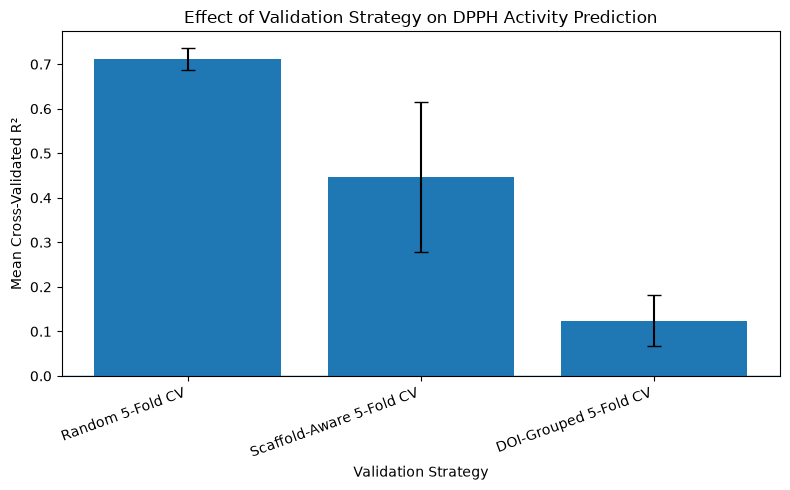

In [45]:
# ============================================================
# Plot model performance under three validation strategies
#
# Purpose:
# Visualize how random, scaffold-aware, and DOI-grouped
# separation affect estimated model generalization.
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    validation_strategy_comparison["Validation_Strategy"],
    validation_strategy_comparison["Mean_R2"],
    yerr=validation_strategy_comparison["SD_R2"],
    capsize=5
)

plt.axhline(
    0,
    linewidth=1
)

plt.ylabel("Mean Cross-Validated R²")
plt.xlabel("Validation Strategy")

plt.title(
    "Effect of Validation Strategy on DPPH Activity Prediction"
)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.tight_layout()
plt.show()

### Validation-Strategy Interpretation

The validation-strategy comparison shows a progressive decline in predictive
performance as increasingly restrictive data-separation criteria are applied.

Random cross-validation produced the highest apparent performance because
closely related compounds and compounds originating from the same publication
can occur across training and validation folds.

Scaffold-aware validation reduced performance by separating Bemis–Murcko
frameworks, while DOI-grouped validation produced the lowest performance by
withholding complete publication-level experimental series.

This pattern indicates that the DPPH dataset contains substantial chemical-
series and publication-level structure. Consequently, random cross-validation
provides an optimistic estimate of generalization compared with more stringent
tests of transfer to unseen molecular frameworks and unseen source studies.

## Additional Nonlinear Baseline: Extra Trees

To determine whether the observed predictive performance was specific to
Random Forest regression, an additional nonlinear ensemble baseline was
evaluated using Extra Trees regression.

Extra Trees differs from Random Forest by introducing greater randomness in
the selection of split thresholds during tree construction.

The model was evaluated using the same combined Morgan fingerprint + RDKit
descriptor representation and the same validation strategies used for the
Random Forest model.

This comparison was performed to assess model robustness rather than to
optimize for the highest possible predictive score.

In [46]:
# ============================================================
# Define Extra Trees regression baseline
#
# Purpose:
# Evaluate a second nonlinear ensemble model using exactly the
# same molecular representation as the Random Forest.
# ============================================================

extra_trees_model = ExtraTreesRegressor(
    n_estimators=300,
    max_features="sqrt",
    random_state=42,
    n_jobs=2
)

print("Extra Trees model created successfully.")


Extra Trees model created successfully.


In [47]:
# ============================================================
# Define reproducible random 5-fold cross-validation
#
# Purpose:
# Recreate the random CV splitter used for model comparison.
# ============================================================

from sklearn.model_selection import KFold

cv5 = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("Random 5-fold CV splitter created successfully.")

Random 5-fold CV splitter created successfully.


In [48]:
# ============================================================
# Random 5-fold CV for Extra Trees
#
# Purpose:
# Compare Extra Trees with Random Forest under the ordinary
# random cross-validation setting.
# ============================================================

extra_random_results = cross_validate(
    extra_trees_model,
    X_train_combined,
    y_train,
    cv=cv5,
    scoring=scoring,
    n_jobs=1
)

extra_random_mae = -extra_random_results["test_MAE"]
extra_random_rmse = -extra_random_results["test_RMSE"]
extra_random_r2 = extra_random_results["test_R2"]

print("EXTRA TREES: RANDOM 5-FOLD CV")
print("-----------------------------")

print(
    f"MAE:  {extra_random_mae.mean():.4f} ± "
    f"{extra_random_mae.std():.4f}"
)

print(
    f"RMSE: {extra_random_rmse.mean():.4f} ± "
    f"{extra_random_rmse.std():.4f}"
)

print(
    f"R²:   {extra_random_r2.mean():.4f} ± "
    f"{extra_random_r2.std():.4f}"
)

EXTRA TREES: RANDOM 5-FOLD CV
-----------------------------
MAE:  0.2769 ± 0.0108
RMSE: 0.4536 ± 0.0343
R²:   0.7368 ± 0.0266


### Extra Trees Random-CV Interpretation

Extra Trees slightly outperformed the combined Random Forest under ordinary
random five-fold cross-validation.

The Extra Trees model achieved an R² of approximately 0.737 compared with
approximately 0.712 for Random Forest, while also producing lower MAE and RMSE.

However, random cross-validation is the least restrictive validation strategy
used in this study. Model selection is therefore not based on random-split
performance alone.

The Extra Trees model was subsequently evaluated under the same
Bemis–Murcko scaffold-aware and DOI-grouped validation strategies used for
Random Forest to determine whether the apparent improvement persists under
more demanding generalization conditions.

In [49]:
# ============================================================
# Scaffold-aware 5-fold CV for Extra Trees
#
# Purpose:
# Test whether Extra Trees maintains its random-CV advantage
# when entire molecular scaffolds are separated across folds.
# ============================================================

extra_scaffold_results = cross_validate(
    extra_trees_model,
    X_train_combined,
    y_train,
    cv=scaffold_cv,
    groups=train_scaffold_groups,
    scoring=scoring,
    n_jobs=1
)

extra_scaffold_mae = -extra_scaffold_results["test_MAE"]
extra_scaffold_rmse = -extra_scaffold_results["test_RMSE"]
extra_scaffold_r2 = extra_scaffold_results["test_R2"]

print("EXTRA TREES: SCAFFOLD-AWARE 5-FOLD CV")
print("--------------------------------------")

print(
    f"MAE:  {extra_scaffold_mae.mean():.4f} ± "
    f"{extra_scaffold_mae.std():.4f}"
)

print(
    f"RMSE: {extra_scaffold_rmse.mean():.4f} ± "
    f"{extra_scaffold_rmse.std():.4f}"
)

print(
    f"R²:   {extra_scaffold_r2.mean():.4f} ± "
    f"{extra_scaffold_r2.std():.4f}"
)

EXTRA TREES: SCAFFOLD-AWARE 5-FOLD CV
--------------------------------------
MAE:  0.4186 ± 0.0786
RMSE: 0.6436 ± 0.1564
R²:   0.4548 ± 0.1651


In [50]:
# ============================================================
# DOI-grouped 5-fold CV for Extra Trees
#
# Purpose:
# Test Extra Trees generalization to completely unseen
# publications and experimental series.
# ============================================================

extra_doi_results = cross_validate(
    extra_trees_model,
    X_train_combined,
    y_train,
    cv=doi_splits,
    scoring=scoring,
    n_jobs=1
)

extra_doi_mae = -extra_doi_results["test_MAE"]
extra_doi_rmse = -extra_doi_results["test_RMSE"]
extra_doi_r2 = extra_doi_results["test_R2"]

print("EXTRA TREES: DOI-GROUPED 5-FOLD CV")
print("----------------------------------")

print(
    f"MAE:  {extra_doi_mae.mean():.4f} ± "
    f"{extra_doi_mae.std():.4f}"
)

print(
    f"RMSE: {extra_doi_rmse.mean():.4f} ± "
    f"{extra_doi_rmse.std():.4f}"
)

print(
    f"R²:   {extra_doi_r2.mean():.4f} ± "
    f"{extra_doi_r2.std():.4f}"
)

EXTRA TREES: DOI-GROUPED 5-FOLD CV
----------------------------------
MAE:  0.5481 ± 0.1358
RMSE: 0.7968 ± 0.2598
R²:   0.1036 ± 0.0730


### Comparison with Extra Trees

Extra Trees regression was evaluated as an additional nonlinear ensemble
baseline using the same combined Morgan fingerprint and RDKit descriptor
representation.

Under random five-fold cross-validation, Extra Trees slightly outperformed
Random Forest, achieving an R² of approximately 0.737 compared with
approximately 0.712 for Random Forest.

Under scaffold-aware validation, the two models performed similarly, with
Extra Trees achieving an R² of approximately 0.455 and Random Forest
approximately 0.447.

Under the more restrictive DOI-grouped validation, Random Forest produced a
slightly higher R² (approximately 0.124) than Extra Trees (approximately
0.104).

The relatively small differences between the two ensemble methods indicate
that the major validation trends are not specific to a single regression
algorithm. In both cases, performance decreased substantially as validation
became more restrictive, particularly when entire publication-derived groups
were excluded from training.

Random Forest was therefore retained as the primary model for subsequent
interpretability, applicability-domain, and case-study analyses.

In [51]:
# ============================================================
# Compare Random Forest and Extra Trees across validation types
# ============================================================

model_validation_comparison = pd.DataFrame({
    "Model": [
        "Random Forest", "Extra Trees",
        "Random Forest", "Extra Trees",
        "Random Forest", "Extra Trees"
    ],
    "Validation": [
        "Random 5-Fold", "Random 5-Fold",
        "Scaffold-Aware", "Scaffold-Aware",
        "DOI-Grouped", "DOI-Grouped"
    ],
    "MAE": [
        combined_cv_mae.mean(), extra_random_mae.mean(),
        combined_scaffold_mae.mean(), extra_scaffold_mae.mean(),
        doi_cv_mae.mean(), extra_doi_mae.mean()
    ],
    "RMSE": [
        combined_cv_rmse.mean(), extra_random_rmse.mean(),
        combined_scaffold_rmse.mean(), extra_scaffold_rmse.mean(),
        doi_cv_rmse.mean(), extra_doi_rmse.mean()
    ],
    "R2": [
        combined_cv_r2.mean(), extra_random_r2.mean(),
        combined_scaffold_r2.mean(), extra_scaffold_r2.mean(),
        doi_cv_r2.mean(), extra_doi_r2.mean()
    ]
})

model_validation_comparison.round(4)


,Model,Validation,MAE,RMSE,R2
0,Random Forest,Random 5-Fold,0.2967,0.4745,0.7121
1,Extra Trees,Random 5-Fold,0.2769,0.4536,0.7368
2,Random Forest,Scaffold-Aware,0.4326,0.6482,0.4465
3,Extra Trees,Scaffold-Aware,0.4186,0.6436,0.4548
4,Random Forest,DOI-Grouped,0.5450,0.7889,0.1243
5,Extra Trees,DOI-Grouped,0.5481,0.7968,0.1036


## Scaffold-Aware Hyperparameter Optimization

The combined Morgan fingerprint–descriptor Random Forest was subjected to
controlled hyperparameter optimization.

Model selection was performed using scaffold-aware cross-validation so that
hyperparameters were chosen based on performance on held-out molecular
scaffold families rather than ordinary random partitions.

Root mean squared error (RMSE) was used as the primary optimization metric
because it penalizes large prediction errors more strongly than MAE.

In [52]:
# ============================================================
# Define Random Forest hyperparameter search space
#
# Purpose:
# Explore alternative model complexities while retaining
# scaffold-aware validation as the model-selection framework.
# ============================================================

parameter_distributions = {

    # Number of decision trees
    "n_estimators": [
        200,
        300,
        400,
        500
    ],

    # Maximum tree depth
    "max_depth": [
        None,
        10,
        20,
        30
    ],

    # Minimum molecules required to split a node
    "min_samples_split": [
        2,
        4,
        8
    ],

    # Minimum molecules retained in terminal leaves
    "min_samples_leaf": [
        1,
        2,
        4
    ],

    # Fraction/number of features considered during splitting
    "max_features": [
        "sqrt",
        0.10,
        0.25
    ]
}

print("Hyperparameter search space created successfully.")


Hyperparameter search space created successfully.


### Randomized Scaffold-Aware Hyperparameter Search

RandomizedSearchCV was used to explore a controlled subset of Random Forest
hyperparameter combinations.

Hyperparameter selection was based on scaffold-aware five-fold
cross-validation using RMSE as the optimization metric.

The internal random held-out test set remained completely excluded from model tuning.

Because the randomized search requires 100 model fits, the fitting step is optional in the reproducible notebook. The previously completed search result is recorded below, and the untuned combined Random Forest is retained because tuning produced only a negligible improvement.


In [53]:
# ============================================================
# OPTIONAL: scaffold-aware randomized hyperparameter optimization
#
# Purpose:
# Reproduce the 20-candidate × 5-fold Random Forest search.
# This is computationally expensive (100 model fits) and is not
# required for the remainder of the notebook because the search
# produced only a negligible improvement and the untuned model
# was retained.
# ============================================================

RUN_HYPERPARAMETER_SEARCH = False

# Use one CPU thread inside each Random Forest; allow only two
# parallel CV fits to reduce memory pressure on modest laptops.
tuning_rf_model = RandomForestRegressor(
    random_state=42,
    n_jobs=1
)

random_search = RandomizedSearchCV(
    estimator=tuning_rf_model,
    param_distributions=parameter_distributions,
    n_iter=20,
    scoring="neg_root_mean_squared_error",
    cv=scaffold_cv,
    refit=True,
    random_state=42,
    n_jobs=2,
    verbose=1,
    return_train_score=True
)

if RUN_HYPERPARAMETER_SEARCH:
    random_search.fit(
        X_train_combined,
        y_train,
        groups=train_scaffold_groups
    )
    print("Hyperparameter search completed successfully.")
else:
    print(
        "Hyperparameter search skipped. Set "
        "RUN_HYPERPARAMETER_SEARCH = True to reproduce the 100-fit search."
    )


Hyperparameter search skipped. Set RUN_HYPERPARAMETER_SEARCH = True to reproduce the 100-fit search.


### Best Hyperparameters from Scaffold-Aware Search

The randomized hyperparameter search identified the Random Forest settings
that minimized scaffold-aware cross-validation RMSE among the 20 sampled
parameter combinations.

These settings are treated as tuned model parameters. Their performance will
be evaluated separately rather than treating the tuning score as final model
performance.

In [54]:
# ============================================================
# Record the previously completed hyperparameter-search result
# ============================================================

recorded_best_params = {
    "n_estimators": 500,
    "min_samples_split": 2,
    "min_samples_leaf": 1,
    "max_features": 0.10,
    "max_depth": None,
}
recorded_best_tuning_rmse = 0.6478

if RUN_HYPERPARAMETER_SEARCH and hasattr(random_search, "best_params_"):
    best_params_to_report = random_search.best_params_
    best_tuning_rmse = -random_search.best_score_
else:
    best_params_to_report = recorded_best_params
    best_tuning_rmse = recorded_best_tuning_rmse

print("BEST RANDOM FOREST HYPERPARAMETERS")
print("----------------------------------")
for parameter, value in best_params_to_report.items():
    print(f"{parameter}: {value}")

print("\nBEST HYPERPARAMETER-SEARCH SCORE")
print("--------------------------------")
print(f"Best scaffold-CV RMSE: {best_tuning_rmse:.4f}")
print(
    "Previous untuned combined-model RMSE:",
    f"{combined_scaffold_rmse.mean():.4f}"
)


BEST RANDOM FOREST HYPERPARAMETERS
----------------------------------
n_estimators: 500
min_samples_split: 2
min_samples_leaf: 1
max_features: 0.1
max_depth: None

BEST HYPERPARAMETER-SEARCH SCORE
--------------------------------
Best scaffold-CV RMSE: 0.6478
Previous untuned combined-model RMSE: 0.6482


### Hyperparameter Optimization Outcome

Scaffold-aware randomized hyperparameter optimization identified a Random
Forest containing 500 trees, unrestricted tree depth, a minimum leaf size
of one, a minimum split size of two, and `max_features = 0.10`.

The optimized configuration achieved a scaffold-cross-validation RMSE of
approximately 0.6478, compared with approximately 0.6482 for the original
combined-feature Random Forest.

Because the improvement was negligible relative to the variability observed
across scaffold folds, hyperparameter optimization was not considered to
provide a meaningful performance gain. The original combined-feature Random
Forest was therefore retained as the primary model configuration for
subsequent evaluation.

In [55]:
# ============================================================
# Record final model-selection decision
#
# Purpose:
# Freeze the model configuration before evaluating the
# internal random held-out test dataset.
# ============================================================

final_model = combined_rf_model

print("FINAL MODEL SELECTION")
print("---------------------")

print("Representation: Morgan fingerprints + RDKit descriptors")
print("Number of features:", X_train_combined.shape[1])
print("Random Forest trees: 300")
print("max_features: sqrt")

print(
    "\nScaffold CV RMSE:",
    f"{combined_scaffold_rmse.mean():.4f} ± "
    f"{combined_scaffold_rmse.std():.4f}"
)

print(
    "Scaffold CV R²:",
    f"{combined_scaffold_r2.mean():.4f} ± "
    f"{combined_scaffold_r2.std():.4f}"
)

print("\nModel configuration frozen before internal held-out test evaluation.")


FINAL MODEL SELECTION
---------------------
Representation: Morgan fingerprints + RDKit descriptors
Number of features: 2057
Random Forest trees: 300
max_features: sqrt

Scaffold CV RMSE: 0.6482 ± 0.1580
Scaffold CV R²: 0.4465 ± 0.1692

Model configuration frozen before internal held-out test evaluation.


## Internal Random Held-Out Test Evaluation

After molecular representation, validation strategy, and model configuration were fixed using only the 1,512-molecule development subset, the selected Random Forest was trained on all development molecules.

The fitted model was then evaluated once on the 379-molecule **internal random held-out test set**, which had not been used for representation selection or hyperparameter assessment.

Because this test subset was sampled from the same curated DPPH dataset, it is not an external or independently collected validation set. MAE, RMSE, and R² are therefore reported as internal held-out performance and interpreted together with scaffold novelty and applicability-domain analyses.


In [56]:
# ============================================================
# Fit the final frozen model on the complete development set
#
# Purpose:
# Train the selected combined-feature Random Forest using all
# 1,512 development molecules before internal held-out testing.
# ============================================================

final_model.fit(
    X_train_combined,
    y_train
)

print("Final model fitted on all development molecules.")

# ============================================================
# Predict the internal random held-out test set
#
# Purpose:
# Generate pIC50 predictions for molecules that were excluded
# from model development and hyperparameter selection.
# ============================================================

final_test_predictions = final_model.predict(
    X_test_combined
)

print("Internal held-out test predictions generated.")

print("\nNumber of test predictions:",
      len(final_test_predictions))

print("\nFirst 10 predictions:")
print(final_test_predictions[:10])

# ============================================================
# Evaluate internal held-out test-set performance
#
# Purpose:
# Measure final predictive performance on the 379 molecules
# that were held out from model development.
# ============================================================

final_test_mae = mean_absolute_error(
    y_test,
    final_test_predictions
)

final_test_rmse = root_mean_squared_error(
    y_test,
    final_test_predictions
)

final_test_r2 = r2_score(
    y_test,
    final_test_predictions
)

print("INTERNAL RANDOM HELD-OUT TEST PERFORMANCE")
print("----------------------------------")

print(f"MAE:  {final_test_mae:.4f}")
print(f"RMSE: {final_test_rmse:.4f}")
print(f"R²:   {final_test_r2:.4f}")


Final model fitted on all development molecules.
Internal held-out test predictions generated.

Number of test predictions: 379

First 10 predictions:
[4.64498931 3.69095366 3.91184337 1.4654266  4.28904583 4.0936523
 4.17567521 4.65587745 4.78884314 4.52340368]
INTERNAL RANDOM HELD-OUT TEST PERFORMANCE
----------------------------------
MAE:  0.2770
RMSE: 0.4382
R²:   0.7921


### Experimental versus Predicted DPPH Activity

Predicted pIC50 values from the selected model were compared with the corresponding experimental values in the internal random held-out test set.

A perfect model would place every molecule on the diagonal identity line, where predicted and experimental pIC50 values are equal.


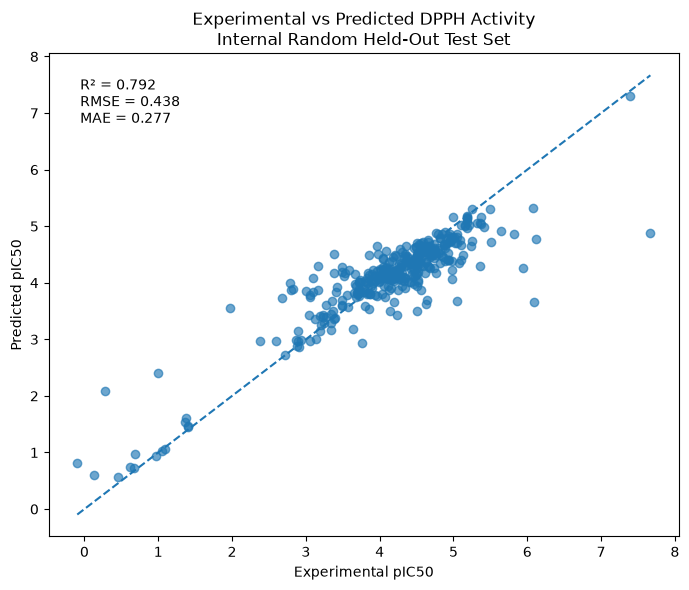

In [57]:
# ============================================================
# Plot experimental versus predicted pIC50
#
# Purpose:
# Visually assess agreement between experimental DPPH activity
# and final model predictions on the held-out test dataset.
# ============================================================

plt.figure(figsize=(7, 6))

# Plot each test molecule
plt.scatter(
    y_test,
    final_test_predictions,
    alpha=0.65
)

# Determine common plotting range
plot_min = min(
    y_test.min(),
    final_test_predictions.min()
)

plot_max = max(
    y_test.max(),
    final_test_predictions.max()
)

# Perfect-prediction reference line
plt.plot(
    [plot_min, plot_max],
    [plot_min, plot_max],
    linestyle="--",
    linewidth=1.5
)

plt.xlabel("Experimental pIC50")
plt.ylabel("Predicted pIC50")

plt.title(
    "Experimental vs Predicted DPPH Activity\n"
    "Internal Random Held-Out Test Set"
)

# Display final metrics on the figure
plt.text(
    0.05,
    0.95,
    f"R² = {final_test_r2:.3f}\n"
    f"RMSE = {final_test_rmse:.3f}\n"
    f"MAE = {final_test_mae:.3f}",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)

plt.tight_layout()
plt.show()


### Residual Analysis of Internal Held-Out Predictions

Residuals were calculated as predicted pIC50 minus experimental pIC50.

Therefore:

- positive residuals indicate overprediction;
- negative residuals indicate underprediction; and
- residuals close to zero indicate good agreement.

Residual analysis was used to examine whether prediction errors showed systematic patterns across the experimental activity range within the internal held-out set.


TEST-SET RESIDUAL SUMMARY
-------------------------
Mean residual:   -0.0365
Median residual: -0.0202

Minimum residual: -2.7931
Maximum residual: 1.7977

Mean absolute residual: 0.2770


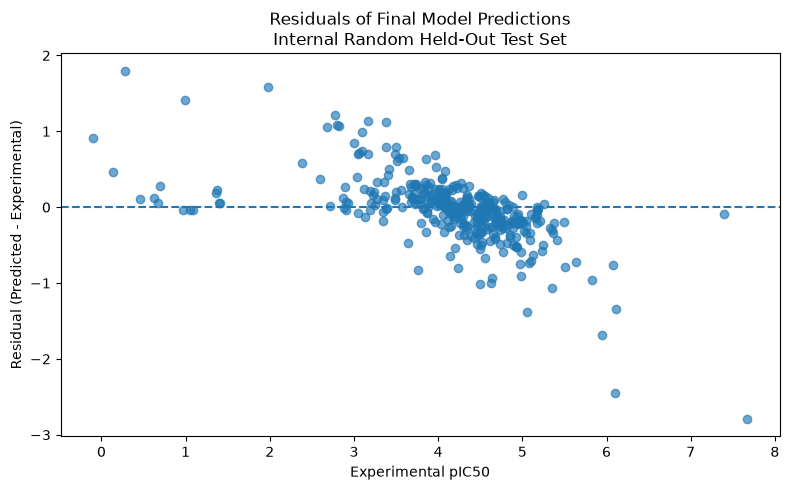

In [58]:
# ============================================================
# Calculate residuals for the internal held-out test set
#
# Purpose:
# Quantify the direction and magnitude of prediction errors.
# ============================================================

test_residuals = final_test_predictions - y_test

absolute_test_errors = np.abs(test_residuals)

print("TEST-SET RESIDUAL SUMMARY")
print("-------------------------")

print(f"Mean residual:   {test_residuals.mean():.4f}")
print(f"Median residual: {np.median(test_residuals):.4f}")

print(f"\nMinimum residual: {test_residuals.min():.4f}")
print(f"Maximum residual: {test_residuals.max():.4f}")

print(
    f"\nMean absolute residual: "
    f"{absolute_test_errors.mean():.4f}"
)

# ============================================================
# Plot residuals versus experimental pIC50
#
# Purpose:
# Determine whether prediction errors change systematically
# across weak, moderate, and strong antioxidant activities.
# ============================================================

plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    test_residuals,
    alpha=0.65
)

# Zero residual = perfect prediction
plt.axhline(
    0,
    linestyle="--",
    linewidth=1.5
)

plt.xlabel("Experimental pIC50")
plt.ylabel("Residual (Predicted - Experimental)")

plt.title(
    "Residuals of Final Model Predictions\n"
    "Internal Random Held-Out Test Set"
)

plt.tight_layout()
plt.show()


### Largest Internal Held-Out Test-Set Prediction Errors

The molecules with the largest absolute residuals were identified to examine which chemical structures and activity ranges were most difficult for the selected model to predict.

This analysis can help reveal whether large prediction errors are associated with particular activity extremes, molecular scaffolds, or chemical series.


In [59]:
# ============================================================
# Create a detailed test-set prediction table
#
# Purpose:
# Link each held-out molecule to its experimental activity,
# predicted activity, residual, and absolute prediction error.
# ============================================================

test_prediction_results = model_df.iloc[test_indices][
    [
        "Canonical SMILES",
        "Murcko_Scaffold",
        "minusLogIC50 (M)",
        "ChEMBL ID",
        "DOI"
    ]
].copy()

# Rename experimental activity for clarity
test_prediction_results = test_prediction_results.rename(
    columns={
        "minusLogIC50 (M)": "Experimental_pIC50"
    }
)

# Add model predictions
test_prediction_results["Predicted_pIC50"] = (
    final_test_predictions
)

# Residual = predicted - experimental
test_prediction_results["Residual"] = (
    final_test_predictions - y_test
)

# Absolute prediction error
test_prediction_results["Absolute_Error"] = (
    np.abs(test_prediction_results["Residual"])
)

# Reset row numbering for easier viewing
test_prediction_results = (
    test_prediction_results
    .reset_index(drop=True)
)

print("Test prediction table created successfully.")
print("Number of molecules:", len(test_prediction_results))

# ============================================================
# Identify the largest internal held-out test-set prediction errors
# ============================================================

largest_test_errors = (
    test_prediction_results
    .sort_values(
        "Absolute_Error",
        ascending=False
    )
    .head(10)
)

largest_test_errors[
    [
        "Experimental_pIC50",
        "Predicted_pIC50",
        "Residual",
        "Absolute_Error",
        "ChEMBL ID",
        "Canonical SMILES"
    ]
]


Test prediction table created successfully.
Number of molecules: 379


,Experimental_pIC50,Predicted_pIC50,Residual,Absolute_Error,ChEMBL ID,Canonical SMILES
320,7.667562,4.874505,-2.793056,2.793056,CHEMBL242739,O=c1c(-c2ccc(O)cc2)coc2c(O)c(O)ccc12
190,6.096910,3.653059,-2.443851,2.443851,CHEMBL110059,Cc1cc(O)cc(O)c1
282,0.283387,2.081136,1.797749,1.797749,CHEMBL4210269,CC(C)CC(NC(=O)C(CCC(=O)O)NC(=O)CN)C(=O)O
374,5.948231,4.258944,-1.689288,1.689288,CHEMBL4294673,COc1cc(C2CC(C(=NNc3ccc(C)cc3)C3=NC(=S)NC(c4ccc...
85,1.977159,3.560221,1.583062,1.583062,CHEMBL4576402,O=C1C(=Cc2cn(-c3ccccc3)nc2-c2ccccc2)CNCC1=Cc1c...
105,0.992167,2.402704,1.410537,1.410537,CHEMBL4204355,CC(C)CC(N)C(=O)NC(Cc1cnc[nH]1)C(=O)NCC(=O)O
154,5.050610,3.673707,-1.376903,1.376903,CHEMBL2087310,C=CCc1cc(NC(=O)C2CC2)ccc1OCC=C(C)CCC=C(C)CCC=C...
144,6.113509,4.771470,-1.342039,1.342039,CHEMBL2346984,COc1cc(OC2OC(CO)C(O)C(O)C2O)c(CC=C(C)C)c(O)c1C...
270,2.779160,3.997038,1.217878,1.217878,CHEMBL2312102,O=C(O)c1ccc(N=Cc2cc3ccccc3[nH]c2=O)cc1
317,3.166302,4.305040,1.138738,1.138738,CHEMBL4206690,NC(CCC(=O)Nc1ccccc1O)C(=O)O


### Structural Novelty of Internal Held-Out Molecules

The chemical similarity of each internal held-out test molecule to the development dataset was examined to determine whether large prediction errors were associated with structurally unfamiliar molecules.

Two measures were considered:

1. whether the molecule's Bemis–Murcko scaffold was present in the development dataset; and

2. its maximum Morgan-fingerprint Tanimoto similarity to any development molecule.


TEST-SET SCAFFOLD NOVELTY
-------------------------
Test molecules with scaffold seen in training: 289
Test molecules with unseen scaffold: 90
Percentage with unseen scaffold: 23.75%
Similarity fingerprints prepared successfully.
Training fingerprints: 1512
Test fingerprints: 379
MAXIMUM TEST-TO-TRAIN TANIMOTO SIMILARITY
-----------------------------------------
Minimum: 0.212
Mean:    0.744
Median:  0.769
Maximum: 1.000
Structural novelty information added successfully.
SIMILARITY vs ABSOLUTE ERROR
----------------------------
Pearson correlation: -0.4028
Spearman correlation: -0.3530


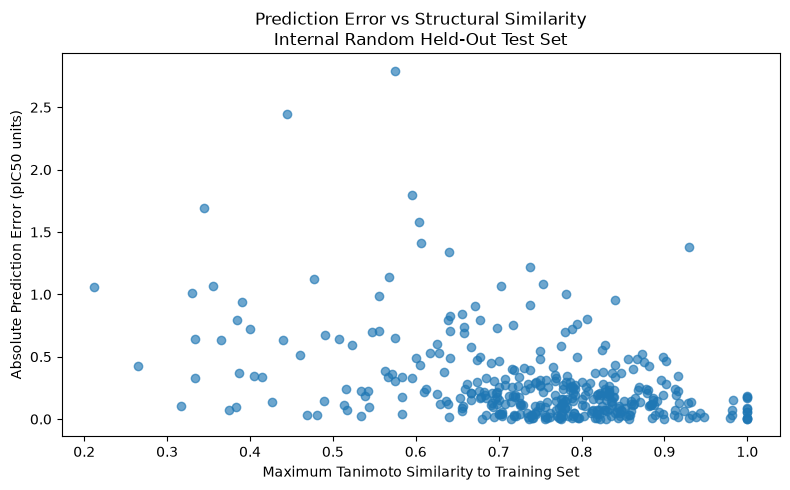

,Experimental_pIC50,Predicted_pIC50,Absolute_Error,Scaffold_Seen_in_Training,Max_Training_Tanimoto,ChEMBL ID
320,7.667562,4.874505,2.793056,True,0.575000,CHEMBL242739
190,6.096910,3.653059,2.443851,True,0.444444,CHEMBL110059
282,0.283387,2.081136,1.797749,True,0.595745,CHEMBL4210269
374,5.948231,4.258944,1.689288,False,0.344262,CHEMBL4294673
85,1.977159,3.560221,1.583062,True,0.603774,CHEMBL4576402
105,0.992167,2.402704,1.410537,True,0.606557,CHEMBL4204355
154,5.050610,3.673707,1.376903,False,0.929825,CHEMBL2087310
144,6.113509,4.771470,1.342039,False,0.640625,CHEMBL2346984
270,2.779160,3.997038,1.217878,True,0.738095,CHEMBL2312102
317,3.166302,4.305040,1.138738,True,0.568182,CHEMBL4206690


In [60]:
# ============================================================
# Identify scaffold novelty in the internal held-out test set
#
# Purpose:
# Determine whether each test molecule's Murcko scaffold was
# represented among the 1,512 development molecules.
# ============================================================

# Set of scaffolds represented in training
training_scaffold_set = set(
    model_df.iloc[train_indices]["Murcko_Scaffold"]
)

# Scaffold of each internal held-out test molecule
test_scaffolds = model_df.iloc[test_indices][
    "Murcko_Scaffold"
].to_numpy()

# True if scaffold was already represented in training
test_scaffold_seen = np.array([
    scaffold in training_scaffold_set
    for scaffold in test_scaffolds
])

print("TEST-SET SCAFFOLD NOVELTY")
print("-------------------------")

print(
    "Test molecules with scaffold seen in training:",
    test_scaffold_seen.sum()
)

print(
    "Test molecules with unseen scaffold:",
    (~test_scaffold_seen).sum()
)

print(
    "Percentage with unseen scaffold:",
    f"{(~test_scaffold_seen).mean() * 100:.2f}%"
)

# ============================================================
# Generate RDKit Morgan fingerprints for similarity analysis
#
# Purpose:
# Prepare molecular fingerprints for calculating how similar
# each internal held-out test molecule is to the training molecules.
# ============================================================

all_morgan_fps = []

for smiles in model_df["Canonical SMILES"]:

    # Convert SMILES to an RDKit molecule
    mol = Chem.MolFromSmiles(smiles)

    # Generate the same radius-2, 2048-bit Morgan fingerprint
    fp = morgan_generator.GetFingerprint(mol)

    all_morgan_fps.append(fp)


# Separate fingerprints using the existing train/test indices
train_rdkit_fps = [
    all_morgan_fps[i]
    for i in train_indices
]

test_rdkit_fps = [
    all_morgan_fps[i]
    for i in test_indices
]

print("Similarity fingerprints prepared successfully.")

print("Training fingerprints:", len(train_rdkit_fps))
print("Test fingerprints:", len(test_rdkit_fps))

# ============================================================
# Calculate maximum test-to-training Tanimoto similarity
#
# Purpose:
# Measure how structurally familiar each held-out test molecule
# is relative to the development dataset.
# ============================================================

max_test_similarity = []

for test_fp in test_rdkit_fps:

    # Compare this test molecule with every training molecule
    similarities = DataStructs.BulkTanimotoSimilarity(
        test_fp,
        train_rdkit_fps
    )

    # Keep only the similarity to its closest training analogue
    max_test_similarity.append(
        max(similarities)
    )


max_test_similarity = np.array(max_test_similarity)

print("MAXIMUM TEST-TO-TRAIN TANIMOTO SIMILARITY")
print("-----------------------------------------")

print(f"Minimum: {max_test_similarity.min():.3f}")
print(f"Mean:    {max_test_similarity.mean():.3f}")
print(f"Median:  {np.median(max_test_similarity):.3f}")
print(f"Maximum: {max_test_similarity.max():.3f}")

# ============================================================
# Add structural-novelty information to test predictions
#
# Purpose:
# Connect each prediction error with scaffold familiarity and
# maximum Morgan similarity to the training dataset.
# ============================================================

test_prediction_results["Scaffold_Seen_in_Training"] = (
    test_scaffold_seen
)

test_prediction_results["Max_Training_Tanimoto"] = (
    max_test_similarity
)

print("Structural novelty information added successfully.")

test_prediction_results[
    [
        "Experimental_pIC50",
        "Predicted_pIC50",
        "Absolute_Error",
        "Scaffold_Seen_in_Training",
        "Max_Training_Tanimoto"
    ]
].head()

# ============================================================
# Examine relationship between structural similarity and error
#
# Purpose:
# Determine whether molecules that are less similar to the
# training set tend to have larger prediction errors.
# ============================================================

similarity_error_pearson = (
    test_prediction_results[
        ["Max_Training_Tanimoto", "Absolute_Error"]
    ]
    .corr(method="pearson")
    .iloc[0, 1]
)

similarity_error_spearman = (
    test_prediction_results[
        ["Max_Training_Tanimoto", "Absolute_Error"]
    ]
    .corr(method="spearman")
    .iloc[0, 1]
)

print("SIMILARITY vs ABSOLUTE ERROR")
print("----------------------------")

print(
    f"Pearson correlation: "
    f"{similarity_error_pearson:.4f}"
)

print(
    f"Spearman correlation: "
    f"{similarity_error_spearman:.4f}"
)

# ============================================================
# Plot prediction error against training-set similarity
#
# Purpose:
# Visualize whether structurally unfamiliar molecules tend to
# produce larger held-out prediction errors.
# ============================================================

plt.figure(figsize=(8, 5))

plt.scatter(
    test_prediction_results["Max_Training_Tanimoto"],
    test_prediction_results["Absolute_Error"],
    alpha=0.65
)

plt.xlabel("Maximum Tanimoto Similarity to Training Set")
plt.ylabel("Absolute Prediction Error (pIC50 units)")

plt.title(
    "Prediction Error vs Structural Similarity\n"
    "Internal Random Held-Out Test Set"
)

plt.tight_layout()
plt.show()

# ============================================================
# Examine largest errors together with structural novelty
# ============================================================

largest_test_errors = (
    test_prediction_results
    .sort_values(
        "Absolute_Error",
        ascending=False
    )
    .head(10)
)

largest_test_errors[
    [
        "Experimental_pIC50",
        "Predicted_pIC50",
        "Absolute_Error",
        "Scaffold_Seen_in_Training",
        "Max_Training_Tanimoto",
        "ChEMBL ID"
    ]
]


### Training-Derived Structural Applicability Domain

A fingerprint-similarity applicability domain was derived using only the
development dataset.

For each development molecule, the maximum Morgan-fingerprint Tanimoto
similarity to every other development molecule was calculated while excluding
self-similarity.

The lower tail of this nearest-neighbour similarity distribution was used to
identify molecules that occupy relatively isolated regions of the development
chemical space.

This approach avoids selecting the applicability-domain threshold from
internal held-out test-set prediction errors.


In [61]:
# ============================================================
# Calculate nearest-neighbour similarity within training data
#
# Purpose:
# Characterize the structural coverage of the development set
# without using the internal held-out test-set prediction errors.
# ============================================================

train_nearest_neighbor_similarity = []

for i, train_fp in enumerate(train_rdkit_fps):

    # Compare this training molecule with all training molecules
    similarities = DataStructs.BulkTanimotoSimilarity(
        train_fp,
        train_rdkit_fps
    )

    # Remove self-similarity (which would always equal 1.0)
    similarities[i] = -1

    # Record similarity to the closest OTHER training molecule
    train_nearest_neighbor_similarity.append(
        max(similarities)
    )


train_nearest_neighbor_similarity = np.array(
    train_nearest_neighbor_similarity
)

print("TRAINING NEAREST-NEIGHBOUR SIMILARITY")
print("-------------------------------------")

print(
    f"Minimum: "
    f"{train_nearest_neighbor_similarity.min():.3f}"
)

print(
    f"Mean:    "
    f"{train_nearest_neighbor_similarity.mean():.3f}"
)

print(
    f"Median:  "
    f"{np.median(train_nearest_neighbor_similarity):.3f}"
)

print(
    f"Maximum: "
    f"{train_nearest_neighbor_similarity.max():.3f}"
)

# ============================================================
# Examine lower-tail similarity thresholds
#
# Purpose:
# Identify how structurally isolated the least-supported
# development molecules are within the training chemical space.
# ============================================================

similarity_percentiles = np.percentile(
    train_nearest_neighbor_similarity,
    [1, 5, 10, 25, 50]
)

print("TRAINING SIMILARITY PERCENTILES")
print("--------------------------------")

print(f"1st percentile:  {similarity_percentiles[0]:.3f}")
print(f"5th percentile:  {similarity_percentiles[1]:.3f}")
print(f"10th percentile: {similarity_percentiles[2]:.3f}")
print(f"25th percentile: {similarity_percentiles[3]:.3f}")
print(f"50th percentile: {similarity_percentiles[4]:.3f}")


TRAINING NEAREST-NEIGHBOUR SIMILARITY
-------------------------------------
Minimum: 0.161
Mean:    0.739
Median:  0.767
Maximum: 1.000
TRAINING SIMILARITY PERCENTILES
--------------------------------
1st percentile:  0.290
5th percentile:  0.469
10th percentile: 0.560
25th percentile: 0.677
50th percentile: 0.767


### Fingerprint-Based Applicability Domain

The 5th percentile of the development-set nearest-neighbour Morgan
similarity distribution was used as a practical structural applicability
domain threshold.

A test molecule was considered structurally supported when its maximum
Tanimoto similarity to the development set was equal to or greater than
this training-derived threshold.

Molecules below the threshold were classified as structurally
out-of-domain for subsequent performance comparison.

In [62]:
# ============================================================
# Define the training-derived applicability-domain threshold
#
# Purpose:
# Use the lower 5th percentile of development-set nearest-
# neighbour similarity as a structural-support threshold.
# ============================================================

ad_threshold = np.percentile(
    train_nearest_neighbor_similarity,
    5
)

print("STRUCTURAL APPLICABILITY-DOMAIN THRESHOLD")
print("-----------------------------------------")

print(f"5th-percentile Tanimoto threshold: {ad_threshold:.3f}")

# ============================================================
# Classify internal held-out test molecules by applicability domain
#
# Purpose:
# Separate structurally supported molecules from molecules
# lying in weakly represented regions of chemical space.
# ============================================================

inside_ad = max_test_similarity >= ad_threshold
outside_ad = ~inside_ad

print("TEST-SET APPLICABILITY DOMAIN")
print("-----------------------------")

print("Inside domain:", inside_ad.sum())
print("Outside domain:", outside_ad.sum())

print(
    "Percentage inside domain:",
    f"{inside_ad.mean() * 100:.2f}%"
)

print(
    "Percentage outside domain:",
    f"{outside_ad.mean() * 100:.2f}%"
)

# ============================================================
# Compare prediction performance inside and outside the
# fingerprint-based applicability domain
#
# Purpose:
# Determine whether model reliability decreases for molecules
# with weak structural support from the development dataset.
# ============================================================

# ----- Inside-domain performance -----

inside_mae = mean_absolute_error(
    y_test[inside_ad],
    final_test_predictions[inside_ad]
)

inside_rmse = root_mean_squared_error(
    y_test[inside_ad],
    final_test_predictions[inside_ad]
)

inside_r2 = r2_score(
    y_test[inside_ad],
    final_test_predictions[inside_ad]
)


# ----- Outside-domain performance -----

outside_mae = mean_absolute_error(
    y_test[outside_ad],
    final_test_predictions[outside_ad]
)

outside_rmse = root_mean_squared_error(
    y_test[outside_ad],
    final_test_predictions[outside_ad]
)

outside_r2 = r2_score(
    y_test[outside_ad],
    final_test_predictions[outside_ad]
)


print("APPLICABILITY-DOMAIN PERFORMANCE")
print("--------------------------------")

print("\nINSIDE DOMAIN")
print(f"Molecules: {inside_ad.sum()}")
print(f"MAE:  {inside_mae:.4f}")
print(f"RMSE: {inside_rmse:.4f}")
print(f"R²:   {inside_r2:.4f}")

print("\nOUTSIDE DOMAIN")
print(f"Molecules: {outside_ad.sum()}")
print(f"MAE:  {outside_mae:.4f}")
print(f"RMSE: {outside_rmse:.4f}")
print(f"R²:   {outside_r2:.4f}")


STRUCTURAL APPLICABILITY-DOMAIN THRESHOLD
-----------------------------------------
5th-percentile Tanimoto threshold: 0.469
TEST-SET APPLICABILITY DOMAIN
-----------------------------
Inside domain: 357
Outside domain: 22
Percentage inside domain: 94.20%
Percentage outside domain: 5.80%
APPLICABILITY-DOMAIN PERFORMANCE
--------------------------------

INSIDE DOMAIN
Molecules: 357
MAE:  0.2538
RMSE: 0.3978
R²:   0.8304

OUTSIDE DOMAIN
Molecules: 22
MAE:  0.6536
RMSE: 0.8606
R²:   -0.0306


In [63]:
# ============================================================
# Save internal held-out applicability-domain performance
#
# Purpose:
# Preserve the final inside-domain and outside-domain
# performance results before moving to the case-study compounds.
# ============================================================

applicability_domain_results = pd.DataFrame({
    "Domain": [
        "Inside structural applicability domain",
        "Outside structural applicability domain"
    ],
    "Molecules": [
        inside_ad.sum(),
        outside_ad.sum()
    ],
    "MAE": [
        inside_mae,
        outside_mae
    ],
    "RMSE": [
        inside_rmse,
        outside_rmse
    ],
    "R2": [
        inside_r2,
        outside_r2
    ]
})

applicability_domain_results


,Domain,Molecules,MAE,RMSE,R2
0,Inside structural applicability domain,357,0.253788,0.397802,0.830357
1,Outside structural applicability domain,22,0.653638,0.860574,-0.030585


### Applicability-Domain Interpretation

A development-derived Morgan-fingerprint similarity threshold of 0.469 classified 357 of the 379 internal held-out test molecules (94.2%) as being within the structural applicability domain.

Prediction performance was substantially stronger within this domain (MAE = 0.254, RMSE = 0.398, R² = 0.830) than for the 22 structurally out-of-domain molecules (MAE = 0.654, RMSE = 0.861, R² ≈ -0.031).

These results indicate that structural similarity to the development chemical space provides useful information about model reliability. Predictions for molecules below the similarity threshold should therefore be interpreted with substantially greater caution.

Because the applicability-domain threshold was derived exclusively from the development-set nearest-neighbour similarity distribution rather than from held-out prediction errors, it provides a separate assessment of structural support.


## Internal Held-Out Test: Seen vs Unseen Scaffolds

The 379-molecule random held-out test set contains both molecules whose
Bemis–Murcko scaffolds were already represented in the development set and
molecules with previously unseen scaffolds.

Because these two groups represent different levels of structural novelty,
model performance was evaluated separately for scaffold-seen and
scaffold-unseen test molecules.

This analysis helps determine how much of the strong overall random held-out
performance is associated with prediction of structurally familiar molecular
frameworks.

In [64]:
# ============================================================
# Verify scaffold-seen and scaffold-unseen test subsets
#
# Purpose:
# Confirm the number of internal held-out test molecules whose
# Murcko scaffolds were or were not represented during training.
# ============================================================

seen_scaffold_mask = test_scaffold_seen
unseen_scaffold_mask = ~test_scaffold_seen

print("INTERNAL HELD-OUT TEST: SCAFFOLD STATUS")
print("---------------------------------------")

print(
    "Seen-scaffold molecules:",
    seen_scaffold_mask.sum()
)

print(
    "Unseen-scaffold molecules:",
    unseen_scaffold_mask.sum()
)

print(
    "Percentage seen:",
    f"{seen_scaffold_mask.mean() * 100:.2f}%"
)

print(
    "Percentage unseen:",
    f"{unseen_scaffold_mask.mean() * 100:.2f}%"
)

INTERNAL HELD-OUT TEST: SCAFFOLD STATUS
---------------------------------------
Seen-scaffold molecules: 289
Unseen-scaffold molecules: 90
Percentage seen: 76.25%
Percentage unseen: 23.75%


In [65]:
# ============================================================
# Compare held-out performance for seen vs unseen scaffolds
#
# Purpose:
# Determine how strongly model performance depends on whether
# the test molecule's Bemis-Murcko scaffold was represented
# during model development.
# ============================================================

# ----- Seen-scaffold molecules -----

seen_mae = mean_absolute_error(
    y_test[seen_scaffold_mask],
    final_test_predictions[seen_scaffold_mask]
)

seen_rmse = root_mean_squared_error(
    y_test[seen_scaffold_mask],
    final_test_predictions[seen_scaffold_mask]
)

seen_r2 = r2_score(
    y_test[seen_scaffold_mask],
    final_test_predictions[seen_scaffold_mask]
)


# ----- Unseen-scaffold molecules -----

unseen_mae = mean_absolute_error(
    y_test[unseen_scaffold_mask],
    final_test_predictions[unseen_scaffold_mask]
)

unseen_rmse = root_mean_squared_error(
    y_test[unseen_scaffold_mask],
    final_test_predictions[unseen_scaffold_mask]
)

unseen_r2 = r2_score(
    y_test[unseen_scaffold_mask],
    final_test_predictions[unseen_scaffold_mask]
)


print("INTERNAL HELD-OUT PERFORMANCE BY SCAFFOLD STATUS")
print("------------------------------------------------")

print("\nSEEN SCAFFOLDS")
print(f"Molecules: {seen_scaffold_mask.sum()}")
print(f"MAE:  {seen_mae:.4f}")
print(f"RMSE: {seen_rmse:.4f}")
print(f"R²:   {seen_r2:.4f}")

print("\nUNSEEN SCAFFOLDS")
print(f"Molecules: {unseen_scaffold_mask.sum()}")
print(f"MAE:  {unseen_mae:.4f}")
print(f"RMSE: {unseen_rmse:.4f}")
print(f"R²:   {unseen_r2:.4f}")

INTERNAL HELD-OUT PERFORMANCE BY SCAFFOLD STATUS
------------------------------------------------

SEEN SCAFFOLDS
Molecules: 289
MAE:  0.2582
RMSE: 0.4220
R²:   0.8241

UNSEEN SCAFFOLDS
Molecules: 90
MAE:  0.3374
RMSE: 0.4867
R²:   0.5803


### Interpretation of Scaffold-Seen and Scaffold-Unseen Performance

Model performance was substantially stronger for internal held-out molecules
whose Bemis–Murcko scaffolds had already been represented during development.

For the 289 scaffold-seen molecules, the model achieved an R² of approximately
0.824, compared with approximately 0.580 for the 90 molecules containing
previously unseen scaffolds.

Prediction errors were also higher for the unseen-scaffold subset, with MAE
increasing from approximately 0.258 to 0.337 pIC50 units.

These results show that the strong overall performance of the random held-out
test is partly associated with prediction of structurally familiar molecular
frameworks. Nevertheless, the positive R² obtained for unseen scaffolds
indicates that the model retains meaningful, although reduced, predictive
ability when applied to novel core structures.

The internal random held-out result should therefore be interpreted together
with scaffold novelty rather than as a uniform estimate of performance across
all regions of chemical space.

In [66]:
# ============================================================
# Summarize internal held-out performance by scaffold status
# ============================================================

heldout_scaffold_comparison = pd.DataFrame({
    "Scaffold_Status": [
        "Seen in training",
        "Unseen in training"
    ],
    "Molecules": [
        seen_scaffold_mask.sum(),
        unseen_scaffold_mask.sum()
    ],
    "MAE": [
        seen_mae,
        unseen_mae
    ],
    "RMSE": [
        seen_rmse,
        unseen_rmse
    ],
    "R2": [
        seen_r2,
        unseen_r2
    ]
})

heldout_scaffold_comparison

,Scaffold_Status,Molecules,MAE,RMSE,R2
0,Seen in training,289,0.258184,0.421996,0.824113
1,Unseen in training,90,0.337415,0.486729,0.580255


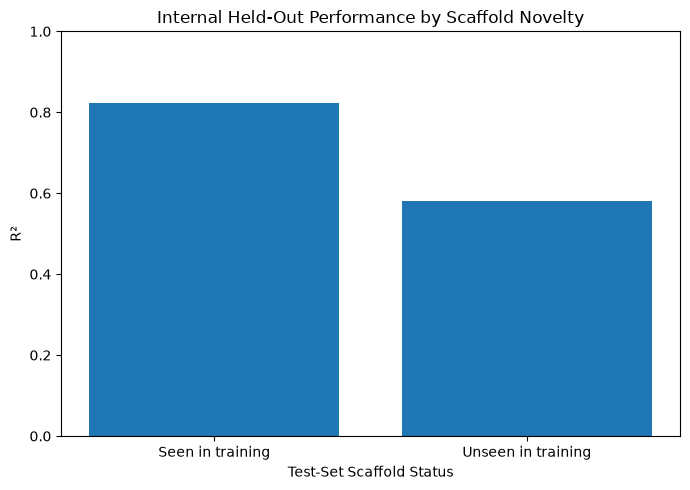

In [67]:
# ============================================================
# Plot internal held-out performance by scaffold novelty
# ============================================================

plt.figure(figsize=(7, 5))

plt.bar(
    heldout_scaffold_comparison["Scaffold_Status"],
    heldout_scaffold_comparison["R2"]
)

plt.ylabel("R²")
plt.xlabel("Test-Set Scaffold Status")

plt.title(
    "Internal Held-Out Performance by Scaffold Novelty"
)

plt.ylim(0, 1)

plt.tight_layout()
plt.show()

## Integrated Validation Framework and Interpretation

Several complementary validation strategies were used because random
train–test splitting alone can provide an optimistic estimate of predictive
performance when structurally related compounds occur in both training and
test sets.

The following validation levels were therefore considered:

1. **Random five-fold cross-validation** evaluated predictive performance
   under conventional random partitioning of the development dataset.

2. **Bemis–Murcko scaffold-aware cross-validation** separated molecular
   scaffolds between training and validation folds, providing a more demanding
   estimate of generalization to previously unseen core molecular frameworks.

3. **DOI-grouped cross-validation** separated compounds according to their
   source publication. This represents the most restrictive validation used
   here because publication groups may differ simultaneously in chemical
   series, assay conditions, experimental protocols, and laboratory context.

4. An **internal random held-out test set** consisting of 379 molecules was
   retained for additional evaluation of the selected Random Forest model.
   This set originated from the same curated DPPH dataset and is therefore
   not considered an external or independent validation dataset.

Across both Random Forest and Extra Trees models, predictive performance
decreased as validation became more restrictive. Random Forest R² decreased
from approximately 0.712 under random five-fold cross-validation to 0.447
under scaffold-aware validation and 0.124 under DOI-grouped validation.

Accordingly, the random held-out R² of approximately 0.79 should not be
interpreted as the expected performance for arbitrary new antioxidant
chemistry. The scaffold-aware results provide a more realistic estimate for
generalization to novel molecular frameworks, while the DOI-grouped results
highlight the additional difficulty of transferring predictions across
different literature-derived experimental series.


## Case-Study Applicability Domain

For prediction of the two experimentally synthesized Tyr-Gly derivatives,
the final case-study model was trained using all 1,891 QC-passed external
DPPH compounds.

Because the chemical space used for this final case-study model is larger
than the development subset used during the internal held-out evaluation, the
fingerprint-based applicability-domain threshold was recalculated using all
1,891 external molecules.

For each molecule, its maximum Morgan-fingerprint Tanimoto similarity to
another molecule in the external dataset was calculated. The 5th percentile
of this nearest-neighbour similarity distribution was retained as the
structural-support threshold.


In [68]:
# ============================================================
# Recalculate applicability-domain threshold using all 1,891
# external DPPH molecules
#
# Purpose:
# Define the structural support appropriate for the final
# case-study model trained on the complete external dataset.
# ============================================================

full_nearest_neighbor_similarity = []

for i, fp in enumerate(all_morgan_fps):

    # Compare molecule i against all 1,891 external molecules
    similarities = DataStructs.BulkTanimotoSimilarity(
        fp,
        all_morgan_fps
    )

    # Exclude self-similarity, which is always 1.0
    similarities[i] = -1

    # Retain similarity to the closest OTHER molecule
    full_nearest_neighbor_similarity.append(
        max(similarities)
    )

full_nearest_neighbor_similarity = np.array(
    full_nearest_neighbor_similarity
)

# Derive the 5th-percentile threshold
case_ad_threshold = np.percentile(
    full_nearest_neighbor_similarity,
    5
)

print("FULL-DATA CASE-STUDY APPLICABILITY DOMAIN")
print("-----------------------------------------")

print(
    f"Minimum nearest-neighbour similarity: "
    f"{full_nearest_neighbor_similarity.min():.3f}"
)

print(
    f"Median nearest-neighbour similarity: "
    f"{np.median(full_nearest_neighbor_similarity):.3f}"
)

print(
    f"5th-percentile AD threshold: "
    f"{case_ad_threshold:.3f}"
)


FULL-DATA CASE-STUDY APPLICABILITY DOMAIN
-----------------------------------------
Minimum nearest-neighbour similarity: 0.161
Median nearest-neighbour similarity: 0.780
5th-percentile AD threshold: 0.500


In [69]:
# ============================================================
# Define the two experimental Tyr-Gly case-study compounds
#
# Purpose:
# Prepare the experimentally synthesized molecules for
# structural characterization and ML prediction.
# ============================================================

case_study_compounds = pd.DataFrame({

    "Compound": [
        "Compound 50",
        "Compound 51"
    ],

    "SMILES": [
        "O=C(NCC(=O)N1CCCCC1)C(Cc1ccc(O)cc1)NS(=O)(=O)c1ccccc1",
        "O=C(NCC(=O)N1CCCCC1)C(Cc1ccc(O)cc1)NS(=O)(=O)c1ccc(C)cc1"
    ],

    # Reported experimental DPPH IC50 values from the BSc project
    "Reported_IC50_mg_mL": [
        0.63,
        0.74
    ]
})

case_study_compounds

# ============================================================
# Calculate RDKit descriptors for Compounds 50 and 51
#
# Purpose:
# Generate the same nine global molecular descriptors used
# in the external DPPH machine-learning dataset.
# ============================================================

case_descriptor_df = (
    case_study_compounds["SMILES"]
    .apply(calculate_descriptors)
    .apply(pd.Series)
)

case_descriptor_df

# ============================================================
# Construct descriptor feature matrix for case-study molecules
# ============================================================

X_case_desc = case_descriptor_df[
    descriptor_columns
].to_numpy()

print("Case-study descriptor shape:", X_case_desc.shape)

# ============================================================
# Generate 2,048-bit Morgan fingerprints for Compounds 50 & 51
# ============================================================

X_case_fp = np.vstack(
    case_study_compounds["SMILES"]
    .apply(smiles_to_fingerprint)
    .values
)

print("Case-study fingerprint shape:", X_case_fp.shape)

# ============================================================
# Combine Morgan fingerprints and RDKit descriptors
#
# Purpose:
# Create the same 2,057-feature representation used by the
# final Random Forest model.
# ============================================================

X_case_combined = np.hstack([
    X_case_fp,
    X_case_desc
])

print("Case-study combined feature shape:")
print(X_case_combined.shape)


Case-study descriptor shape: (2, 9)
Case-study fingerprint shape: (2, 2048)
Case-study combined feature shape:
(2, 2057)


### Structural Support of the Experimental Case-Study Compounds

Before generating model predictions, the structural similarity of Compounds
50 and 51 to the external DPPH dataset was evaluated.

For each case-study molecule, its maximum Morgan-fingerprint Tanimoto
similarity to the 1,891 external compounds was calculated.

The closest external analogue was also identified.

Case-study molecules with maximum similarity equal to or greater than the
full external-data-derived applicability-domain threshold are considered structurally
supported by the model's chemical space.


In [70]:
# ============================================================
# Generate RDKit Morgan fingerprints for Compounds 50 and 51
#
# Purpose:
# Prepare fingerprint objects for Tanimoto similarity analysis
# against the complete external DPPH dataset.
# ============================================================

case_rdkit_fps = []

for smiles in case_study_compounds["SMILES"]:

    # Convert SMILES into an RDKit molecular object
    mol = Chem.MolFromSmiles(smiles)

    # Generate the same radius-2, 2048-bit Morgan fingerprint
    fp = morgan_generator.GetFingerprint(mol)

    case_rdkit_fps.append(fp)

print("Case-study RDKit fingerprints generated successfully.")
print("Number of fingerprints:", len(case_rdkit_fps))

# ============================================================
# Find maximum similarity and nearest external analogue
#
# Purpose:
# Determine how closely each experimental compound resembles
# molecules represented in the external DPPH training space.
# ============================================================

case_similarity_results = []

for compound_name, case_fp in zip(
    case_study_compounds["Compound"],
    case_rdkit_fps
):

    # Compare the case-study compound with all 1,891 molecules
    similarities = DataStructs.BulkTanimotoSimilarity(
        case_fp,
        all_morgan_fps
    )

    # Find the most similar external molecule
    nearest_index = int(np.argmax(similarities))
    maximum_similarity = similarities[nearest_index]

    # Store information about the nearest analogue
    case_similarity_results.append({
        "Compound": compound_name,
        "Max_Tanimoto": maximum_similarity,
        "Nearest_Index": nearest_index,
        "Nearest_ChEMBL_ID":
            model_df.iloc[nearest_index]["ChEMBL ID"],
        "Nearest_Experimental_pIC50":
            model_df.iloc[nearest_index]["minusLogIC50 (M)"],
        "Nearest_SMILES":
            model_df.iloc[nearest_index]["Canonical SMILES"]
    })


case_similarity_df = pd.DataFrame(
    case_similarity_results
)

case_similarity_df

# ============================================================
# Classify Compounds 50 and 51 by structural applicability domain
#
# Purpose:
# Determine whether each experimental compound is sufficiently
# represented by the external DPPH chemical space.
# ============================================================

case_similarity_df["AD_Threshold"] = case_ad_threshold

case_similarity_df["Inside_AD"] = (
    case_similarity_df["Max_Tanimoto"]
    >= case_ad_threshold
)

print("CASE-STUDY STRUCTURAL APPLICABILITY DOMAIN")
print("------------------------------------------")

print(
    case_similarity_df[
        [
            "Compound",
            "Max_Tanimoto",
            "AD_Threshold",
            "Inside_AD",
            "Nearest_ChEMBL_ID",
            "Nearest_Experimental_pIC50"
        ]
    ]
)

# ============================================================
# Check whether case-study Murcko scaffolds exist externally
# ============================================================

case_study_compounds["Murcko_Scaffold"] = (
    case_study_compounds["SMILES"]
    .apply(get_murcko_scaffold)
)

external_scaffold_set = set(
    model_df["Murcko_Scaffold"]
)

case_study_compounds["Scaffold_Seen_Externally"] = (
    case_study_compounds["Murcko_Scaffold"]
    .apply(lambda scaffold: scaffold in external_scaffold_set)
)

case_study_compounds[
    [
        "Compound",
        "Murcko_Scaffold",
        "Scaffold_Seen_Externally"
    ]
]


Case-study RDKit fingerprints generated successfully.
Number of fingerprints: 2
CASE-STUDY STRUCTURAL APPLICABILITY DOMAIN
------------------------------------------
      Compound  Max_Tanimoto  AD_Threshold  Inside_AD Nearest_ChEMBL_ID  \
0  Compound 50      0.363636           0.5      False     CHEMBL4206613   
1  Compound 51      0.333333           0.5      False     CHEMBL4206613   

   Nearest_Experimental_pIC50  
0                    1.103694  
1                    1.103694  


,Compound,Murcko_Scaffold,Scaffold_Seen_Externally
0,Compound 50,O=C(NCC(=O)N1CCCCC1)C(Cc1ccccc1)NS(=O)(=O)c1cc...,False
1,Compound 51,O=C(NCC(=O)N1CCCCC1)C(Cc1ccccc1)NS(=O)(=O)c1cc...,False


### Applicability-Domain Status of the Experimental Compounds

Neither Compound 50 nor Compound 51 was located within the structural
applicability domain of the external DPPH dataset.

Their maximum Morgan-fingerprint Tanimoto similarities to the 1,891 external
compounds were approximately 0.364 and 0.333, respectively, below the
full external-data-derived applicability-domain threshold of 0.500.

In addition, neither experimental compound shared a Bemis–Murcko scaffold
with the external dataset.

Consequently, subsequent machine-learning predictions for these compounds
are treated as exploratory out-of-domain extrapolations rather than
high-confidence quantitative predictions.


In [71]:
# ============================================================
# Train the final case-study model on all external compounds
#
# Purpose:
# Use all 1,891 external DPPH molecules to obtain exploratory
# predictions for Compounds 50 and 51.
#
# IMPORTANT:
# Both case-study compounds are outside the validated
# structural applicability domain.
# ============================================================

case_study_model = RandomForestRegressor(
    n_estimators=300,
    max_features="sqrt",
    random_state=42,
    n_jobs=2
)

case_study_model.fit(
    X_combined,
    y
)

print("Case-study model fitted on all 1,891 external compounds.")

# ============================================================
# Generate exploratory pIC50 predictions
#
# Purpose:
# Predict DPPH pIC50 for Compounds 50 and 51 while retaining
# their out-of-domain status in the interpretation.
# ============================================================

case_predicted_pic50 = case_study_model.predict(
    X_case_combined
)

print("EXPLORATORY CASE-STUDY PREDICTIONS")
print("----------------------------------")

for compound, prediction in zip(
    case_study_compounds["Compound"],
    case_predicted_pic50
):
    print(
        f"{compound}: predicted pIC50 = {prediction:.3f}"
    )

# ============================================================
# Examine prediction variation across Random Forest trees
#
# Purpose:
# Provide an additional descriptive indication of prediction
# variability for the two out-of-domain case-study molecules.
#
# NOTE:
# This is NOT a calibrated confidence interval.
# ============================================================

case_tree_predictions = np.array([
    tree.predict(X_case_combined)
    for tree in case_study_model.estimators_
])

case_prediction_mean = case_tree_predictions.mean(axis=0)
case_prediction_sd = case_tree_predictions.std(axis=0)

for i, compound in enumerate(
    case_study_compounds["Compound"]
):
    print(
        f"{compound}: "
        f"{case_prediction_mean[i]:.3f} ± "
        f"{case_prediction_sd[i]:.3f} pIC50"
    )

# ============================================================
# Convert reported experimental IC50 values to molar pIC50
#
# IC50 in mg/mL is numerically equivalent to g/L.
# Molar IC50 = concentration (g/L) / molecular weight (g/mol)
# ============================================================

case_study_compounds["RDKit_MW"] = (
    case_descriptor_df["RDKit_MW"].values
)

case_study_compounds["Reported_IC50_M"] = (
    case_study_compounds["Reported_IC50_mg_mL"]
    / case_study_compounds["RDKit_MW"]
)

case_study_compounds["Reported_pIC50"] = (
    -np.log10(
        case_study_compounds["Reported_IC50_M"]
    )
)

case_study_compounds[
    [
        "Compound",
        "Reported_IC50_mg_mL",
        "RDKit_MW",
        "Reported_IC50_M",
        "Reported_pIC50"
    ]
]


Case-study model fitted on all 1,891 external compounds.
EXPLORATORY CASE-STUDY PREDICTIONS
----------------------------------
Compound 50: predicted pIC50 = 3.857
Compound 51: predicted pIC50 = 3.899
Compound 50: 3.857 ± 1.066 pIC50
Compound 51: 3.899 ± 1.062 pIC50


,Compound,Reported_IC50_mg_mL,RDKit_MW,Reported_IC50_M,Reported_pIC50
0,Compound 50,0.63,445.541,0.001414,2.849547
1,Compound 51,0.74,459.568,0.001610,2.793118


### Experimental and Predicted Activity of the Case-Study Compounds

The reported experimental activities of Compounds 50 and 51 were compared
with exploratory predictions from the final case-study Random Forest.

Because both compounds were outside the fingerprint-based applicability
domain and did not share Bemis–Murcko scaffolds with the external dataset,
the predictions are interpreted as out-of-domain extrapolations rather than
high-confidence quantitative estimates.

In [72]:
# ============================================================
# Create final case-study comparison table
#
# Purpose:
# Summarize reported experimental activity, model prediction,
# structural support, and prediction discrepancy for Compounds
# 50 and 51.
# ============================================================

case_study_results = pd.DataFrame({

    "Compound":
        case_study_compounds["Compound"],

    "Reported_IC50_mg_mL":
        case_study_compounds["Reported_IC50_mg_mL"],

    "Reported_pIC50":
        case_study_compounds["Reported_pIC50"],

    "Predicted_pIC50":
        case_predicted_pic50,

    "Tree_SD":
        case_prediction_sd,

    "Max_Tanimoto":
        case_similarity_df["Max_Tanimoto"],

    "AD_Threshold":
        case_similarity_df["AD_Threshold"],

    "Inside_AD":
        case_similarity_df["Inside_AD"],

    "Scaffold_Seen_Externally":
        case_study_compounds["Scaffold_Seen_Externally"]
})

# Prediction minus reported experimental value
case_study_results["Prediction_Difference"] = (
    case_study_results["Predicted_pIC50"]
    - case_study_results["Reported_pIC50"]
)

case_study_results

# ============================================================
# Convert predicted pIC50 values back to predicted IC50
#
# Purpose:
# Express ML predictions on the same mg/mL scale as the
# originally reported experimental antioxidant measurements.
# ============================================================

# Convert pIC50 back to molar IC50
case_study_results["Predicted_IC50_M"] = (
    10 ** (-case_study_results["Predicted_pIC50"])
)

# Convert mol/L to g/L, numerically equivalent to mg/mL
case_study_results["Predicted_IC50_mg_mL"] = (
    case_study_results["Predicted_IC50_M"]
    * case_study_compounds["RDKit_MW"]
)

case_study_results[
    [
        "Compound",
        "Reported_IC50_mg_mL",
        "Predicted_IC50_mg_mL",
        "Reported_pIC50",
        "Predicted_pIC50",
        "Prediction_Difference",
        "Max_Tanimoto",
        "Inside_AD"
    ]
]


,Compound,Reported_IC50_mg_mL,Predicted_IC50_mg_mL,Reported_pIC50,Predicted_pIC50,Prediction_Difference,Max_Tanimoto,Inside_AD
0,Compound 50,0.63,0.061916,2.849547,3.857087,1.007540,0.363636,False
1,Compound 51,0.74,0.058029,2.793118,3.898707,1.105589,0.333333,False


### Interpretation of the Tyr-Gly Case Study

The final case-study Random Forest predicted pIC50 values of approximately
3.857 and 3.899 for Compounds 50 and 51, corresponding to predicted IC50
values of approximately 0.062 and 0.058 mg/mL, respectively.

These predictions were substantially stronger than the reported experimental
activities of 0.63 and 0.74 mg/mL (reported pIC50 values of approximately
2.850 and 2.793).

However, both compounds were outside the model's structural applicability
domain. Their maximum Morgan-fingerprint Tanimoto similarities to the full
external DPPH dataset were only 0.364 and 0.333, below the full external-data-derived
threshold of 0.500. Neither compound shared a Bemis-Murcko scaffold with the
external dataset.

The predictions are therefore interpreted as exploratory out-of-domain
extrapolations rather than validated quantitative estimates. The disagreement
between predicted and reported activity illustrates the importance of chemical
space coverage and applicability-domain assessment when applying QSAR models
to structurally novel sulfonamide–Tyr–Gly derivatives.

The model also predicted nearly identical activities for the two compounds
and did not reproduce their reported experimental ranking. Consequently,
the model does not provide sufficient evidence for attributing the small
experimental activity difference between Compounds 50 and 51 to the
para-methyl substitution in Compound 51.


## Case-Study Reliability and Applicability-Domain Limitation

The experimentally investigated sulfonamide–Tyr–Gly derivatives (Compounds 50
and 51) were evaluated using the final Random Forest model as exploratory
case-study compounds.

However, both molecules lie outside the structural applicability domain of the
external DPPH training dataset.

Their maximum Morgan-fingerprint Tanimoto similarities to the 1,891-compound
modeling dataset were approximately 0.364 for Compound 50 and 0.333 for
Compound 51, both below the full-dataset applicability-domain threshold of
0.500. In addition, neither compound possessed a Bemis–Murcko scaffold already
represented in the modeling dataset.

The model predicted pIC50 values of approximately 3.86 for Compound 50 and
3.90 for Compound 51, whereas the reported experimental values correspond to
approximately 2.85 and 2.79, respectively. The model therefore overpredicted
the activity of both compounds by approximately one pIC50 unit.

The predicted difference between the two compounds was very small
(approximately 0.04 pIC50 units) relative to the tree-to-tree prediction
dispersion of approximately 1.06 pIC50 units. Therefore, the apparent predicted
ranking of Compound 51 above Compound 50 should not be interpreted as a
meaningful structure–activity conclusion.

These predictions are consequently treated as exploratory extrapolations from
a broad small-molecule DPPH QSAR model rather than as validation of the
experimental measurements. The applicability-domain analysis is itself an
important result because it identifies the limited structural support available
for these Tyr–Gly derivatives within the external antioxidant dataset.

In [73]:
# ============================================================
# Summarize case-study reliability
# ============================================================

case_study_reliability = pd.DataFrame({
    "Compound": ["50", "51"],
    "Reported_pIC50": [2.8495, 2.7931],
    "Predicted_pIC50": [3.8571, 3.8987],
    "Prediction_Difference": [1.0075, 1.1056],
    "Tree_SD": [1.0664, 1.0623],
    "Max_Tanimoto": [0.3636, 0.3333],
    "AD_Threshold": [0.5000, 0.5000],
    "Inside_AD": [False, False],
    "Scaffold_Seen": [False, False]
})

case_study_reliability.round(4)

,Compound,Reported_pIC50,Predicted_pIC50,Prediction_Difference,Tree_SD,Max_Tanimoto,AD_Threshold,Inside_AD,Scaffold_Seen
0,50,2.8495,3.8571,1.0075,1.0664,0.3636,0.5,False,False
1,51,2.7931,3.8987,1.1056,1.0623,0.3333,0.5,False,False


## Model Interpretation and Structure–Activity Relationships

Model interpretation was performed to identify molecular properties associated
with prediction of DPPH antioxidant activity.

Permutation importance was used for the interpretable RDKit descriptors.
Each descriptor was randomly permuted while the remaining molecular features
were retained, and the resulting decrease in predictive performance was
measured.

Higher permutation importance indicates greater predictive contribution to
the fitted model. These associations are interpreted as model-derived
structure–activity relationships and do not establish chemical causation.

Descriptor interpretation model fitted successfully.


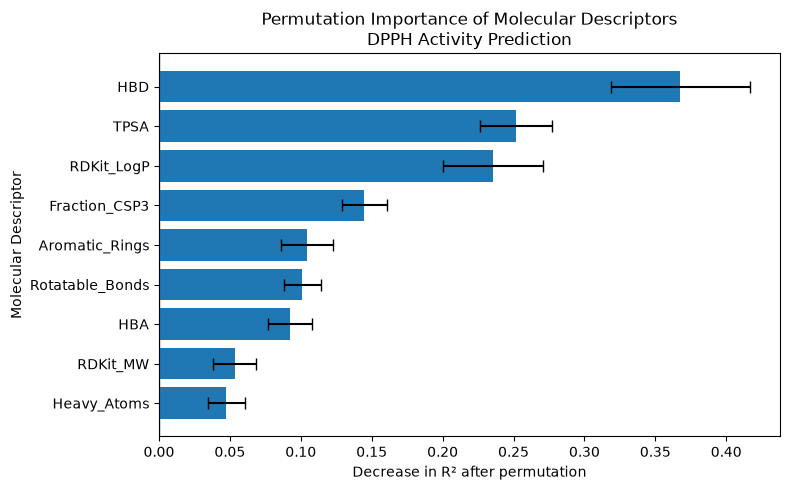

In [74]:
# ============================================================
# Fit the descriptor-only Random Forest for interpretation
#
# Purpose:
# Train an interpretable molecular-property model using the
# complete development set before permutation analysis.
# ============================================================

interpretation_descriptor_model = RandomForestRegressor(
    n_estimators=300,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

interpretation_descriptor_model.fit(
    X_train_desc,
    y_train
)

print("Descriptor interpretation model fitted successfully.")

# ============================================================
# Calculate permutation importance of RDKit descriptors
#
# Purpose:
# Determine which global molecular properties contribute most
# to prediction of experimental DPPH pIC50.
# ============================================================


descriptor_permutation = permutation_importance(
    interpretation_descriptor_model,
    X_test_desc,
    y_test,
    scoring="r2",
    n_repeats=30,
    random_state=42,
    n_jobs=-1
)

descriptor_importance = pd.DataFrame({
    "Descriptor": descriptor_columns,
    "Importance_Mean": descriptor_permutation.importances_mean,
    "Importance_SD": descriptor_permutation.importances_std
})

descriptor_importance = descriptor_importance.sort_values(
    "Importance_Mean",
    ascending=False
).reset_index(drop=True)

descriptor_importance

# ============================================================
# Plot descriptor permutation importance
#
# Purpose:
# Visualize the relative predictive contribution of the nine
# interpretable molecular descriptors.
# ============================================================

plot_importance = descriptor_importance.sort_values(
    "Importance_Mean"
)

plt.figure(figsize=(8, 5))

plt.barh(
    plot_importance["Descriptor"],
    plot_importance["Importance_Mean"],
    xerr=plot_importance["Importance_SD"],
    capsize=4
)

plt.axvline(0, linewidth=1)

plt.xlabel("Decrease in R² after permutation")
plt.ylabel("Molecular Descriptor")

plt.title(
    "Permutation Importance of Molecular Descriptors\n"
    "DPPH Activity Prediction"
)

plt.tight_layout()
plt.show()


### Interpretation of Descriptor Importance

Permutation analysis of the descriptor-only Random Forest identified
hydrogen-bond donor count (HBD) as the most influential global molecular
descriptor, followed by TPSA and LogP.

The importance of HBD was consistent with the earlier correlation analysis,
where HBD showed the strongest individual association with experimental
DPPH pIC50.

In contrast, LogP showed almost no simple linear or monotonic correlation
with activity but displayed substantial permutation importance. This suggests
that lipophilicity contributes predictive information primarily through
nonlinear relationships or interactions with other molecular properties
rather than through a simple direct association with pIC50.

TPSA also contributed substantially to prediction, indicating that molecular
polarity provides useful information beyond hydrogen-bond donor count alone.

Permutation importance reflects predictive contribution within the fitted
descriptor model and should not be interpreted as evidence that an individual
descriptor directly causes antioxidant activity. Correlation among molecular
descriptors may also influence their measured importance.

In [75]:
# ============================================================
# Compare simple descriptor correlations with ML importance
#
# Purpose:
# Show how univariate statistical associations differ from
# predictive importance in a nonlinear Random Forest model.
# ============================================================

correlation_importance_comparison = pd.DataFrame({
    "Descriptor": descriptor_columns,
    
    "Pearson_r": [
        pearson_correlations[descriptor]
        for descriptor in descriptor_columns
    ],
    
    "Spearman_rho": [
        spearman_correlations[descriptor]
        for descriptor in descriptor_columns
    ]
})

# Add permutation-importance values
correlation_importance_comparison = (
    correlation_importance_comparison
    .merge(
        descriptor_importance,
        on="Descriptor"
    )
)

# Sort by model importance
correlation_importance_comparison = (
    correlation_importance_comparison
    .sort_values(
        "Importance_Mean",
        ascending=False
    )
    .reset_index(drop=True)
)

correlation_importance_comparison


,Descriptor,Pearson_r,Spearman_rho,Importance_Mean,Importance_SD
0,HBD,0.199223,0.292635,0.367723,0.049326
1,TPSA,0.094815,0.136387,0.251823,0.025299
2,RDKit_LogP,0.038686,-0.036703,0.235522,0.035483
3,Fraction_CSP3,-0.117578,-0.121363,0.144863,0.015720
4,Aromatic_Rings,0.119472,0.099426,0.104597,0.018288
5,Rotatable_Bonds,-0.086045,-0.037225,0.101087,0.013119
6,HBA,0.100270,0.110401,0.092197,0.015656
7,RDKit_MW,0.102975,0.077423,0.053439,0.015058
8,Heavy_Atoms,0.091475,0.055589,0.047509,0.013058


### Morgan Fingerprint Feature Interpretation

The fingerprint-based Random Forest was examined to identify Morgan
fingerprint positions that contributed most strongly to model prediction.

Because Morgan fingerprints use hashed atom-centered structural environments,
individual bit numbers cannot be interpreted directly as unique functional
groups.

Fingerprint importance was therefore used first as a screening tool.
Selected high-ranking bits were subsequently traced back to representative
molecular atom environments for chemical interpretation.

In [76]:
# ============================================================
# Fit fingerprint-only Random Forest for feature interpretation
#
# Purpose:
# Train the Morgan fingerprint model on the complete development
# dataset so that structural fingerprint importance can be examined.
# ============================================================

fingerprint_interpretation_model = RandomForestRegressor(
    n_estimators=300,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

fingerprint_interpretation_model.fit(
    X_train_fp,
    y_train
)

print("Fingerprint interpretation model fitted successfully.")

# ============================================================
# Rank Morgan fingerprint bits by Random Forest importance
#
# Purpose:
# Identify structural fingerprint positions that contributed
# most strongly to the fitted fingerprint model.
# ============================================================

fingerprint_importance = pd.DataFrame({
    "Bit": np.arange(X_train_fp.shape[1]),
    "Importance": fingerprint_interpretation_model.feature_importances_
})

fingerprint_importance = (
    fingerprint_importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

print("TOP 20 MORGAN FINGERPRINT BITS")
print("------------------------------")

fingerprint_importance.head(20)

# ============================================================
# Examine prevalence of the top fingerprint bits
#
# Purpose:
# Determine how many development molecules contain each
# high-ranking structural fingerprint feature.
# ============================================================

top_fingerprint_bits = (
    fingerprint_importance
    .head(20)
    .copy()
)

bit_counts = []

for bit in top_fingerprint_bits["Bit"]:

    # Number of training molecules where this bit is active
    count = X_train_fp[:, bit].sum()

    bit_counts.append(int(count))


top_fingerprint_bits["Molecules_With_Bit"] = bit_counts

top_fingerprint_bits["Percentage_of_Training_Set"] = (
    top_fingerprint_bits["Molecules_With_Bit"]
    / X_train_fp.shape[0]
    * 100
)

top_fingerprint_bits

# ============================================================
# Compare activity for molecules with vs without each top bit
#
# Purpose:
# Provide an exploratory SAR indication for high-ranking
# fingerprint environments.
# ============================================================

mean_activity_with_bit = []
mean_activity_without_bit = []

for bit in top_fingerprint_bits["Bit"]:

    bit_present = X_train_fp[:, bit] == 1
    bit_absent = X_train_fp[:, bit] == 0

    mean_activity_with_bit.append(
        y_train[bit_present].mean()
    )

    mean_activity_without_bit.append(
        y_train[bit_absent].mean()
    )


top_fingerprint_bits["Mean_pIC50_With_Bit"] = (
    mean_activity_with_bit
)

top_fingerprint_bits["Mean_pIC50_Without_Bit"] = (
    mean_activity_without_bit
)

top_fingerprint_bits["Activity_Difference"] = (
    top_fingerprint_bits["Mean_pIC50_With_Bit"]
    - top_fingerprint_bits["Mean_pIC50_Without_Bit"]
)

top_fingerprint_bits


Fingerprint interpretation model fitted successfully.
TOP 20 MORGAN FINGERPRINT BITS
------------------------------


,Bit,Importance,Molecules_With_Bit,Percentage_of_Training_Set,Mean_pIC50_With_Bit,Mean_pIC50_Without_Bit,Activity_Difference
0,662,0.013321,16,1.058201,0.673345,4.184812,-3.511466
1,278,0.012737,19,1.256614,1.205981,4.185089,-2.979109
2,1607,0.012274,696,46.031746,4.386296,3.944106,0.442190
3,1602,0.011796,924,61.111111,4.366608,3.803582,0.563025
4,83,0.010988,25,1.653439,1.896670,4.185498,-2.288828
5,644,0.010771,20,1.322751,1.299288,4.185835,-2.886548
6,762,0.009956,10,0.661376,2.047332,4.161637,-2.114305
7,1978,0.009919,20,1.322751,2.253738,4.173041,-1.919303
8,1820,0.009727,28,1.851852,2.765887,4.173724,-1.407837
9,239,0.009480,32,2.116402,2.915668,4.174291,-1.258623


### Selection of Fingerprint Bits for Chemical Interpretation

Several highly ranked Morgan fingerprint bits occurred in only a very small
number of development molecules.

Because rare fingerprint features can obtain high model importance when they
identify small chemical series with extreme activities, primary chemical
interpretation was restricted to fingerprint bits present in at least 2% of
the development dataset.

Rare high-ranking bits were retained as potentially interesting series-specific
signals but were not used to support broad structure–activity conclusions.

In [77]:
# ============================================================
# Select well-supported fingerprint bits for SAR interpretation
#
# Purpose:
# Avoid overinterpreting highly ranked bits that occur in only
# a very small number of molecules.
# ============================================================

minimum_bit_prevalence = 2.0  # percent of development molecules

supported_fingerprint_bits = (
    top_fingerprint_bits[
        top_fingerprint_bits["Percentage_of_Training_Set"]
        >= minimum_bit_prevalence
    ]
    .copy()
    .reset_index(drop=True)
)

print("SUPPORTED HIGH-RANKING MORGAN BITS")
print("----------------------------------")

supported_fingerprint_bits[
    [
        "Bit",
        "Importance",
        "Molecules_With_Bit",
        "Percentage_of_Training_Set",
        "Mean_pIC50_With_Bit",
        "Mean_pIC50_Without_Bit",
        "Activity_Difference"
    ]
]


SUPPORTED HIGH-RANKING MORGAN BITS
----------------------------------


,Bit,Importance,Molecules_With_Bit,Percentage_of_Training_Set,Mean_pIC50_With_Bit,Mean_pIC50_Without_Bit,Activity_Difference
0,1607,0.012274,696,46.031746,4.386296,3.944106,0.442190
1,1602,0.011796,924,61.111111,4.366608,3.803582,0.563025
2,239,0.009480,32,2.116402,2.915668,4.174291,-1.258623
3,589,0.009249,250,16.534392,4.658877,4.046381,0.612497
4,1475,0.009156,400,26.455026,4.510340,4.017191,0.493149
5,146,0.009005,34,2.248677,2.497191,4.185621,-1.688429
6,315,0.008859,227,15.013228,4.680641,4.053499,0.627141
7,1564,0.008532,110,7.275132,3.421193,4.204651,-0.783458
8,202,0.008156,331,21.891534,4.451130,4.062598,0.388532
9,2026,0.007956,39,2.579365,2.776721,4.183951,-1.407230


In [78]:
# ============================================================
# Trace a Morgan fingerprint bit to a molecular environment
#
# Purpose:
# Recover representative atom-centered environments responsible
# for selected hashed Morgan fingerprint bits.
# ============================================================



def get_bit_environment(smiles, target_bit):
    """
    Return atom/radius information and a representative local
    SMILES environment for a selected Morgan fingerprint bit.
    """

    mol = Chem.MolFromSmiles(smiles)

    # Request information connecting fingerprint bits to
    # atom-centered molecular environments
    additional_output = rdFingerprintGenerator.AdditionalOutput()
    additional_output.AllocateBitInfoMap()

    # Generate fingerprint while recording bit information
    morgan_generator.GetFingerprint(
        mol,
        additionalOutput=additional_output
    )

    bit_info = additional_output.GetBitInfoMap()

    # Molecule does not activate the requested bit
    if target_bit not in bit_info:
        return None

    environments = []

    for atom_index, radius in bit_info[target_bit]:

        # Radius 0 corresponds primarily to the central atom
        if radius == 0:
            environment_smiles = mol.GetAtomWithIdx(
                atom_index
            ).GetSymbol()

        else:
            # Find bonds belonging to the atom environment
            bond_environment = Chem.FindAtomEnvironmentOfRadiusN(
                mol,
                radius,
                atom_index
            )

            # Convert that local environment into a substructure
            submol = Chem.PathToSubmol(
                mol,
                bond_environment
            )

            environment_smiles = Chem.MolToSmiles(
                submol
            )

        environments.append({
            "Atom_Index": atom_index,
            "Radius": radius,
            "Environment_SMILES": environment_smiles
        })

    return environments

# ============================================================
# Find a representative molecule containing Morgan Bit 1607
# ============================================================

target_bit = 1607

# Identify training molecules containing this bit
molecules_with_target_bit = np.where(
    X_train_fp[:, target_bit] == 1
)[0]

# Take the first representative training molecule
representative_training_position = molecules_with_target_bit[0]

# Convert training position back to the original dataset index
representative_dataset_index = train_indices[
    representative_training_position
]

representative_smiles = model_df.iloc[
    representative_dataset_index
]["Canonical SMILES"]

representative_pic50 = model_df.iloc[
    representative_dataset_index
]["minusLogIC50 (M)"]

print("TARGET BIT:", target_bit)
print("Representative pIC50:", representative_pic50)
print("Representative SMILES:")
print(representative_smiles)

print("\nAtom environments generating this bit:")

bit_1607_environment = get_bit_environment(
    representative_smiles,
    target_bit
)

bit_1607_environment


TARGET BIT: 1607
Representative pIC50: 4.73754891026957
Representative SMILES:
O=C(NN=Cc1cc(O)ccc1O)c1ccncc1

Atom environments generating this bit:


[{'Atom_Index': 11, 'Radius': 1, 'Environment_SMILES': 'cc(c)O'}]

### Validation of the Chemical Environment Represented by Bit 1607

A single Morgan fingerprint bit can potentially receive contributions from
different molecular environments because the fingerprint representation is
hashed.

Therefore, Bit 1607 was examined across all development molecules containing
the bit to determine whether the same local structural environment was
consistently represented.

Repeated occurrence of the same environment would provide stronger support
for assigning a chemical interpretation to the fingerprint feature.

In [79]:
# ============================================================
# Examine Bit 1607 across all training molecules containing it
#
# Purpose:
# Determine whether the same chemical environment repeatedly
# generates this high-ranking Morgan fingerprint bit.
# ============================================================

target_bit = 1607

bit_environment_records = []

# Find all training molecules containing Bit 1607
training_positions_with_bit = np.where(
    X_train_fp[:, target_bit] == 1
)[0]

for training_position in training_positions_with_bit:

    # Convert training-array position back to original dataset row
    dataset_index = train_indices[training_position]

    smiles = model_df.iloc[
        dataset_index
    ]["Canonical SMILES"]

    pic50 = model_df.iloc[
        dataset_index
    ]["minusLogIC50 (M)"]

    # Recover all environments that generated Bit 1607
    environments = get_bit_environment(
        smiles,
        target_bit
    )

    if environments is not None:

        for environment in environments:

            bit_environment_records.append({
                "Dataset_Index": dataset_index,
                "pIC50": pic50,
                "Radius": environment["Radius"],
                "Environment_SMILES":
                    environment["Environment_SMILES"]
            })


bit_1607_environments = pd.DataFrame(
    bit_environment_records
)

print("BIT 1607 ENVIRONMENT ANALYSIS")
print("-----------------------------")

print(
    "Molecules containing bit:",
    len(training_positions_with_bit)
)

print(
    "Total recorded environments:",
    len(bit_1607_environments)
)

print("\nMost common environments:")

print(
    bit_1607_environments[
        "Environment_SMILES"
    ]
    .value_counts()
    .head(10)
)


BIT 1607 ENVIRONMENT ANALYSIS
-----------------------------
Molecules containing bit: 696
Total recorded environments: 1297

Most common environments:
Environment_SMILES
cc(c)O                1271
NS                      13
ccc(cc)c(c)o            11
ccc(c(c)C)c(c)[nH]       1
C=CC(=O)CC               1
Name: count, dtype: int64


#### Interpretation of Morgan Bit 1607

Morgan Bit 1607 was present in approximately 46% of the development molecules
and was associated with an increase of approximately 0.44 pIC50 units in mean
experimental DPPH activity.

Tracing the hashed fingerprint bit back to its generating atom environments
showed that approximately 98% of the recorded environments corresponded to
`cc(c)O`, an aromatic C–O environment consistent with phenolic substitution.

This result suggests that phenolic-like aromatic oxygen environments are
associated with higher DPPH activity within the dataset. However, the
association does not establish a causal contribution of the motif independently
of the surrounding molecular structure.

In [80]:
# ============================================================
# Summarize chemical environments for selected Morgan bits
#
# Purpose:
# Identify the dominant local molecular environment associated
# with several well-supported, high-ranking fingerprint bits.
# ============================================================

selected_bits = [
    1607,
    1602,
    589,
    1475,
    315
]

bit_environment_summary = []

for target_bit in selected_bits:

    # Training molecules containing this fingerprint bit
    positions = np.where(
        X_train_fp[:, target_bit] == 1
    )[0]

    environment_records = []

    for training_position in positions:

        dataset_index = train_indices[
            training_position
        ]

        smiles = model_df.iloc[
            dataset_index
        ]["Canonical SMILES"]

        environments = get_bit_environment(
            smiles,
            target_bit
        )

        if environments is not None:

            for environment in environments:

                environment_records.append(
                    (
                        environment["Radius"],
                        environment["Environment_SMILES"]
                    )
                )

    # Count the observed atom environments
    environment_counts = pd.Series(
        environment_records
    ).value_counts()

    dominant_environment = (
        environment_counts.index[0]
    )

    dominant_count = (
        environment_counts.iloc[0]
    )

    total_environments = (
        environment_counts.sum()
    )

    dominance_percentage = (
        dominant_count
        / total_environments
        * 100
    )

    # Retrieve activity information already calculated earlier
    bit_row = top_fingerprint_bits[
        top_fingerprint_bits["Bit"] == target_bit
    ].iloc[0]

    bit_environment_summary.append({

        "Bit": target_bit,

        "Molecules_With_Bit":
            int(len(positions)),

        "Importance":
            bit_row["Importance"],

        "Activity_Difference":
            bit_row["Activity_Difference"],

        "Dominant_Radius":
            dominant_environment[0],

        "Dominant_Environment_SMILES":
            dominant_environment[1],

        "Dominant_Environment_Count":
            int(dominant_count),

        "Total_Recorded_Environments":
            int(total_environments),

        "Dominance_Percentage":
            dominance_percentage
    })


bit_environment_summary_df = pd.DataFrame(
    bit_environment_summary
)

bit_environment_summary_df


,Bit,Molecules_With_Bit,Importance,Activity_Difference,Dominant_Radius,Dominant_Environment_SMILES,Dominant_Environment_Count,Total_Recorded_Environments,Dominance_Percentage
0,1607,696,0.012274,0.442190,1,cc(c)O,1271,1297,97.995374
1,1602,924,0.011796,0.563025,1,cO,2061,2125,96.988235
2,589,250,0.009249,0.612497,2,ccc(O)c(c)O,284,293,96.928328
3,1475,400,0.009156,0.493149,2,cccc(c)O,492,499,98.597194
4,315,227,0.008859,0.627141,2,ccc(O)c(c)O,254,254,100.000000


### Presence of High-Ranking Antioxidant-Associated Fingerprint Features
in Compounds 50 and 51

The experimentally synthesized compounds contain a tyrosine-derived phenolic
ring. Because several high-ranking Morgan fingerprint features in the external
DPPH dataset were associated predominantly with oxygenated aromatic
environments, the presence of these features was examined in Compounds 50
and 51.

This analysis investigates whether the case-study compounds contain local
structural motifs learned by the model despite being outside the model's
overall structural applicability domain.

In [81]:
# ============================================================
# Check selected high-ranking Morgan bits in Compounds 50 & 51
#
# Purpose:
# Determine whether the experimental peptide-sulfonamide
# compounds contain the antioxidant-associated aromatic
# environments identified in the external dataset.
# ============================================================

selected_sar_bits = [
    1607,
    1602,
    589,
    1475,
    315
]

case_bit_presence = []

for compound_index, compound_name in enumerate(
    case_study_compounds["Compound"]
):

    for bit in selected_sar_bits:

        case_bit_presence.append({
            "Compound": compound_name,
            "Bit": bit,
            "Bit_Active": bool(
                X_case_fp[compound_index, bit] == 1
            )
        })


case_bit_presence_df = pd.DataFrame(
    case_bit_presence
)

case_bit_presence_table = (
    case_bit_presence_df
    .pivot(
        index="Bit",
        columns="Compound",
        values="Bit_Active"
    )
)

case_bit_presence_table


Compound,Compound 50,Compound 51
Bit,,
315,False,False
589,False,False
1475,False,False
1602,True,True
1607,False,False


#### High-Ranking Fingerprint Features in Compounds 50 and 51

Among the five well-supported high-ranking Morgan fingerprint features
examined, only Bit 1602 was present in Compounds 50 and 51.

Bit 1602 was predominantly associated with a general aromatic C–O
environment. The more specific oxygenated aromatic environments represented
by Bits 315, 589, 1475 and 1607 were not activated in either case-study
compound.

Thus, the model recognizes some locally familiar aromatic oxygen chemistry
within the experimental compounds, but most of the high-ranking
antioxidant-associated fingerprint environments identified in the external
dataset are absent.

Because both compounds showed the same presence/absence pattern across these
features, these fingerprint bits do not explain the small difference between
their model-predicted activities.

In [82]:
# ============================================================
# Examine top-20 fingerprint features in Compounds 50 and 51
#
# Purpose:
# Determine which globally high-ranking Morgan fingerprint
# features are actually present in each case-study molecule.
# ============================================================

case_top_bit_overlap = top_fingerprint_bits[
    [
        "Bit",
        "Importance",
        "Molecules_With_Bit",
        "Percentage_of_Training_Set",
        "Activity_Difference"
    ]
].copy()

# Check presence of every top-20 bit in Compound 50
case_top_bit_overlap["Compound_50_Active"] = [
    bool(X_case_fp[0, bit] == 1)
    for bit in case_top_bit_overlap["Bit"]
]

# Check presence of every top-20 bit in Compound 51
case_top_bit_overlap["Compound_51_Active"] = [
    bool(X_case_fp[1, bit] == 1)
    for bit in case_top_bit_overlap["Bit"]
]

case_top_bit_overlap

# ============================================================
# Display influential fingerprint bits present in either
# Compound 50 or Compound 51
# ============================================================

active_case_top_bits = case_top_bit_overlap[
    case_top_bit_overlap["Compound_50_Active"]
    | case_top_bit_overlap["Compound_51_Active"]
].copy()

print("HIGH-RANKING FINGERPRINT BITS PRESENT IN CASE-STUDY COMPOUNDS")
print("-------------------------------------------------------------")

active_case_top_bits


HIGH-RANKING FINGERPRINT BITS PRESENT IN CASE-STUDY COMPOUNDS
-------------------------------------------------------------


,Bit,Importance,Molecules_With_Bit,Percentage_of_Training_Set,Activity_Difference,Compound_50_Active,Compound_51_Active
3,1602,0.011796,924,61.111111,0.563025,True,True


### Fingerprint Differences Between Compounds 50 and 51

Compounds 50 and 51 differ only by the para-methyl substituent present on
the sulfonyl phenyl ring of Compound 51.

Because none of the globally top-ranked Morgan fingerprint features
distinguished the two molecules, their complete 2,048-bit fingerprints were
compared directly.

Fingerprint positions active in only one of the two compounds were identified
and ranked according to their importance in the external Random Forest model.

In [83]:
# ============================================================
# Identify fingerprint bits that differ between Compounds 50 & 51
#
# Purpose:
# Find structural fingerprint positions activated in only one
# of the two closely related experimental molecules.
# ============================================================

# Boolean arrays showing which bits are active
compound_50_bits = X_case_fp[0].astype(bool)
compound_51_bits = X_case_fp[1].astype(bool)

# XOR returns True wherever the fingerprints differ
different_bits_mask = np.logical_xor(
    compound_50_bits,
    compound_51_bits
)

different_bits = np.where(
    different_bits_mask
)[0]

print("FINGERPRINT DIFFERENCES BETWEEN COMPOUNDS 50 AND 51")
print("---------------------------------------------------")

print("Number of differing bits:", len(different_bits))
print("\nDiffering bit positions:")
print(different_bits)

# ============================================================
# Characterize all fingerprint differences
#
# Purpose:
# Determine which differing bits are unique to Compound 50 or
# Compound 51 and retrieve their Random Forest importance.
# ============================================================

differential_bit_records = []

for bit in different_bits:

    differential_bit_records.append({

        "Bit": int(bit),

        "Compound_50_Active":
            bool(compound_50_bits[bit]),

        "Compound_51_Active":
            bool(compound_51_bits[bit]),

        "RF_Importance":
            fingerprint_interpretation_model
            .feature_importances_[bit],

        "Training_Prevalence":
            int(X_train_fp[:, bit].sum()),

        "Training_Percentage":
            X_train_fp[:, bit].mean() * 100
    })


differential_bits_df = pd.DataFrame(
    differential_bit_records
)

# Rank the differences by their importance to the model
differential_bits_df = (
    differential_bits_df
    .sort_values(
        "RF_Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

differential_bits_df

# ============================================================
# Add activity associations for fingerprint differences
#
# Purpose:
# Examine whether bits distinguishing Compounds 50 and 51 are
# associated with higher or lower DPPH activity externally.
# ============================================================

activity_differences = []

for bit in differential_bits_df["Bit"]:

    bit_present = X_train_fp[:, bit] == 1
    bit_absent = X_train_fp[:, bit] == 0

    # Avoid problems if a bit is absent from all training molecules
    if bit_present.sum() > 0 and bit_absent.sum() > 0:

        mean_with = y_train[bit_present].mean()
        mean_without = y_train[bit_absent].mean()

        activity_difference = (
            mean_with - mean_without
        )

    else:
        activity_difference = np.nan

    activity_differences.append(
        activity_difference
    )


differential_bits_df["Activity_Difference"] = (
    activity_differences
)

differential_bits_df.head(15)


FINGERPRINT DIFFERENCES BETWEEN COMPOUNDS 50 AND 51
---------------------------------------------------
Number of differing bits: 10

Differing bit positions:
[ 235  389  575  715 1057 1088 1199 1722 1823 1920]


,Bit,Compound_50_Active,Compound_51_Active,RF_Importance,Training_Prevalence,Training_Percentage,Activity_Difference
0,389,True,False,0.003265,387,25.595238,-0.088722
1,1057,False,True,0.002984,966,63.888889,-0.086178
2,1199,True,False,0.002856,527,34.854497,-0.038311
3,1088,True,False,0.002439,769,50.859788,-0.122180
4,1722,False,True,0.002222,357,23.611111,0.085051
5,715,False,True,0.001184,148,9.788360,-0.263120
6,235,False,True,0.000652,69,4.563492,-0.234961
7,1823,False,True,0.000453,74,4.894180,-0.212364
8,1920,False,True,0.000395,53,3.505291,-0.173593
9,575,True,False,0.000072,7,0.462963,0.001413


### Chemical Interpretation of Fingerprint Differences Between Compounds 50 and 51

Ten Morgan fingerprint positions differed between Compounds 50 and 51.

Because the compounds differ structurally by the para-methyl substituent on
the sulfonyl phenyl ring of Compound 51, the atom-centered environments
responsible for these differential fingerprint bits were traced back to the
two molecular structures.

This analysis was used to determine which fingerprint changes correspond
directly to the structural modification rather than assigning chemical
meaning to the hashed bit numbers alone.

In [84]:
# ============================================================
# Trace fingerprint differences back to molecular environments
#
# Purpose:
# Determine the local chemical environment associated with
# every Morgan bit that distinguishes Compounds 50 and 51.
# ============================================================

differential_environment_records = []

for _, row in differential_bits_df.iterrows():

    bit = int(row["Bit"])

    # Determine which compound actually contains this bit
    if row["Compound_50_Active"]:
        compound_name = "Compound 50"
        compound_smiles = case_study_compounds.loc[
            case_study_compounds["Compound"] == "Compound 50",
            "SMILES"
        ].iloc[0]

    else:
        compound_name = "Compound 51"
        compound_smiles = case_study_compounds.loc[
            case_study_compounds["Compound"] == "Compound 51",
            "SMILES"
        ].iloc[0]

    # Recover the atom environment responsible for the bit
    environments = get_bit_environment(
        compound_smiles,
        bit
    )

    if environments is not None:

        for environment in environments:

            differential_environment_records.append({

                "Bit": bit,

                "Present_In":
                    compound_name,

                "RF_Importance":
                    row["RF_Importance"],

                "Training_Prevalence":
                    row["Training_Prevalence"],

                "Activity_Difference":
                    row["Activity_Difference"],

                "Radius":
                    environment["Radius"],

                "Environment_SMILES":
                    environment["Environment_SMILES"]
            })


differential_environment_df = pd.DataFrame(
    differential_environment_records
)

differential_environment_df

# ============================================================
# Rank chemically interpreted fingerprint differences
# ============================================================

differential_environment_df = (
    differential_environment_df
    .sort_values(
        "RF_Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

differential_environment_df[
    [
        "Bit",
        "Present_In",
        "RF_Importance",
        "Activity_Difference",
        "Radius",
        "Environment_SMILES"
    ]
]


,Bit,Present_In,RF_Importance,Activity_Difference,Radius,Environment_SMILES
0,389,Compound 50,0.003265,-0.088722,2,ccccc
1,1057,Compound 51,0.002984,-0.086178,0,C
2,1199,Compound 50,0.002856,-0.038311,2,ccccc
3,1199,Compound 50,0.002856,-0.038311,2,ccccc
4,1088,Compound 50,0.002439,-0.122180,1,ccc
5,1088,Compound 50,0.002439,-0.122180,1,ccc
6,1088,Compound 50,0.002439,-0.122180,1,ccc
7,1722,Compound 51,0.002222,0.085051,1,cC
8,715,Compound 51,0.001184,-0.263120,2,cccc(c)S
9,715,Compound 51,0.001184,-0.263120,2,cccc(c)S


#### Interpretation of the Para-Methyl Structural Difference

Direct comparison of the Morgan fingerprints of Compounds 50 and 51
identified ten differing fingerprint positions.

Several Compound-51-specific features corresponded to local environments
containing an additional aliphatic carbon attached to the aromatic ring,
including `C`, `cC`, and larger methyl-substituted aromatic environments.
These features are consistent with the para-methyl substituent that
distinguishes Compound 51 from Compound 50.

The activity associations of the Compound-51-specific fingerprint features
were mixed and predominantly weakly negative. Only one of the selected
differential environments showed a small positive activity association.

Consequently, the slightly higher model-predicted pIC50 for Compound 51
relative to Compound 50 cannot be attributed confidently to the para-methyl
substitution. The difference is small, results from nonlinear interactions
among multiple molecular features, and occurs for two molecules outside the
validated structural applicability domain.

The fingerprint analysis therefore confirms that the model encodes the
structural modification between the compounds but does not provide evidence
that this modification independently enhances DPPH antioxidant activity.

In [85]:
# ============================================================
# Calculate structural similarity between Compounds 50 and 51
#
# Purpose:
# Quantify how similar the complete Morgan fingerprints of the
# two closely related experimental compounds are.
# ============================================================

compound_50_51_similarity = DataStructs.TanimotoSimilarity(
    case_rdkit_fps[0],
    case_rdkit_fps[1]
)

print("COMPOUND 50 vs COMPOUND 51")
print("--------------------------")

print(
    f"Morgan Tanimoto similarity: "
    f"{compound_50_51_similarity:.3f}"
)

print(
    "Differing fingerprint bits:",
    len(different_bits)
)


COMPOUND 50 vs COMPOUND 51
--------------------------
Morgan Tanimoto similarity: 0.818
Differing fingerprint bits: 10


## Export Final Results, Figures, and Processed Data

The following cells save the principal validation tables, model-comparison tables, applicability-domain and case-study results, interpretation tables, publication-quality figures, and model-ready processed data into the project folders. The untouched source workbook in `data/raw/` is never overwritten.


In [86]:
# Save principal result and interpretation tables

result_tables = {
    # Molecular representation and validation results
    "random_scaffold_representation_comparison.csv": complete_model_comparison,
    "morgan_vs_combined_scaffold_folds.csv": scaffold_representation_comparison,
    "validation_strategy_comparison.csv": validation_strategy_comparison,
    "doi_grouped_fold_results.csv": doi_fold_results,
    "rf_vs_extratrees_validation_comparison.csv": model_validation_comparison,
    "internal_heldout_scaffold_performance.csv": heldout_scaffold_comparison,

    # Internal held-out and applicability-domain results
    "applicability_domain_performance.csv": applicability_domain_results,
    "internal_heldout_test_predictions.csv": test_prediction_results,

    # Case-study results
    "compound_50_51_case_study_results.csv": case_study_results,
    "case_study_reliability.csv": case_study_reliability,

    # Model-interpretation results
    "descriptor_permutation_importance.csv": descriptor_importance,
    "descriptor_correlation_vs_importance.csv": correlation_importance_comparison,
    "top_morgan_fingerprint_bits.csv": top_fingerprint_bits,
    "interpreted_morgan_bit_environments.csv": bit_environment_summary_df,
    "case_study_top_bit_overlap.csv": case_top_bit_overlap,
    "compound_50_51_differential_bits.csv": differential_bits_df,
    "compound_50_51_differential_environments.csv": differential_environment_df,
}

for file_name, table in result_tables.items():
    table.to_csv(results_dir / file_name, index=False)

print(f"Saved {len(result_tables)} result tables to {results_dir}")


Saved 17 result tables to C:\Users\user\Project_1_Peptide_Antioxidant_SAR\results


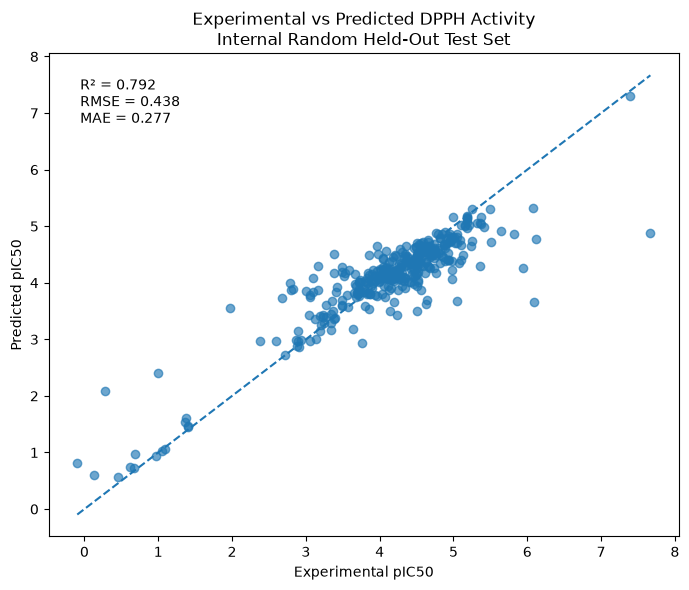

Figure saved to:
C:\Users\user\Project_1_Peptide_Antioxidant_SAR\figures\internal_heldout_experimental_vs_predicted.png


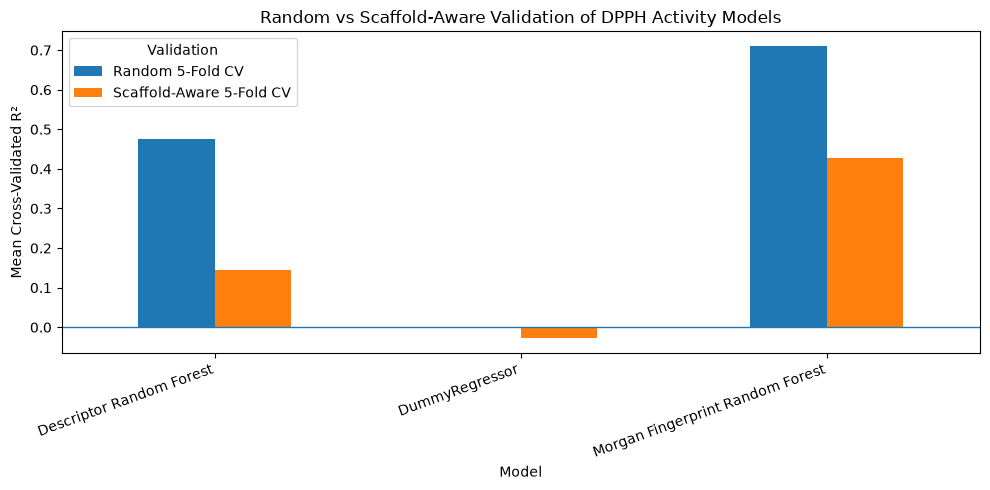

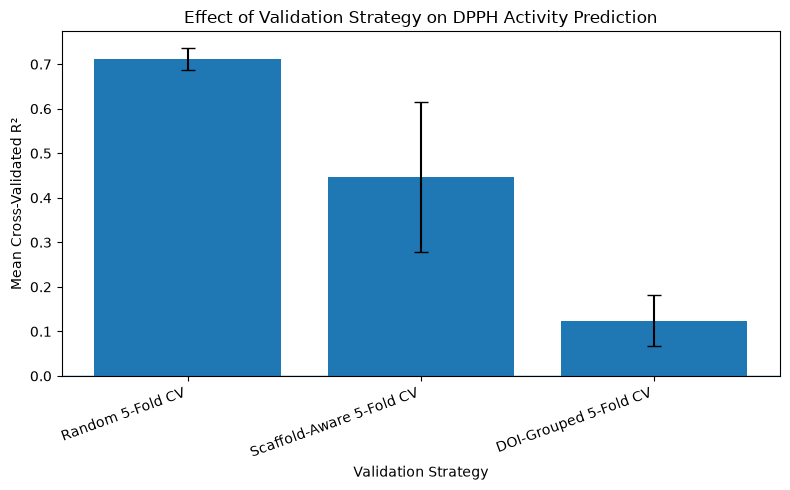

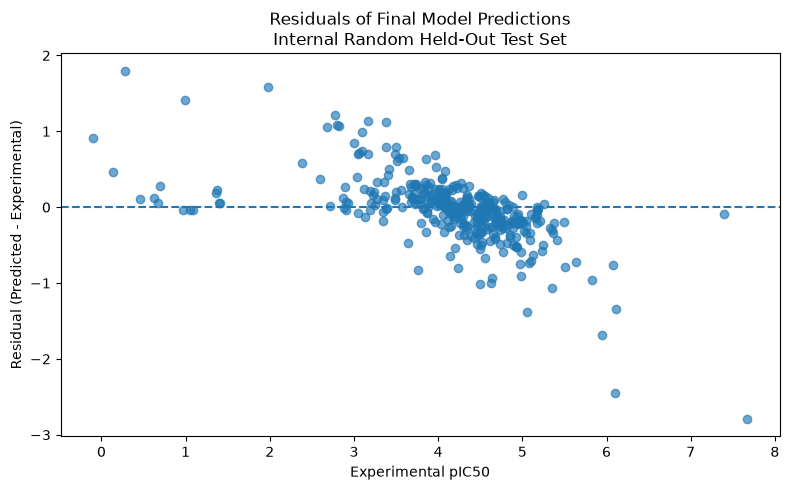

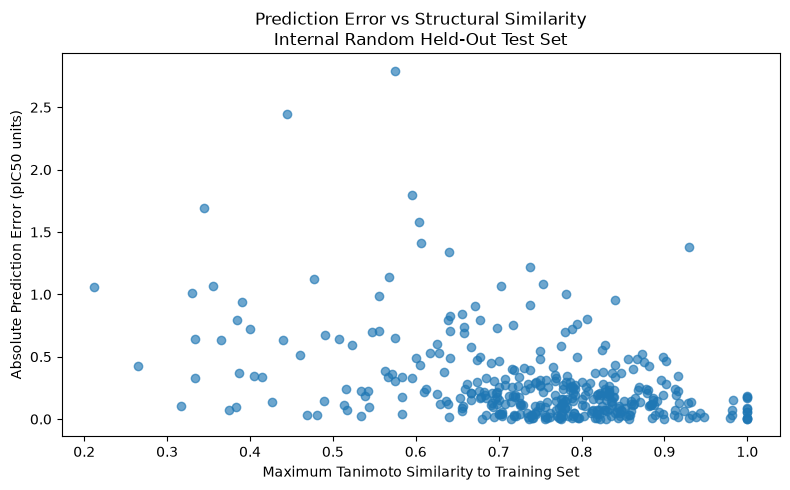

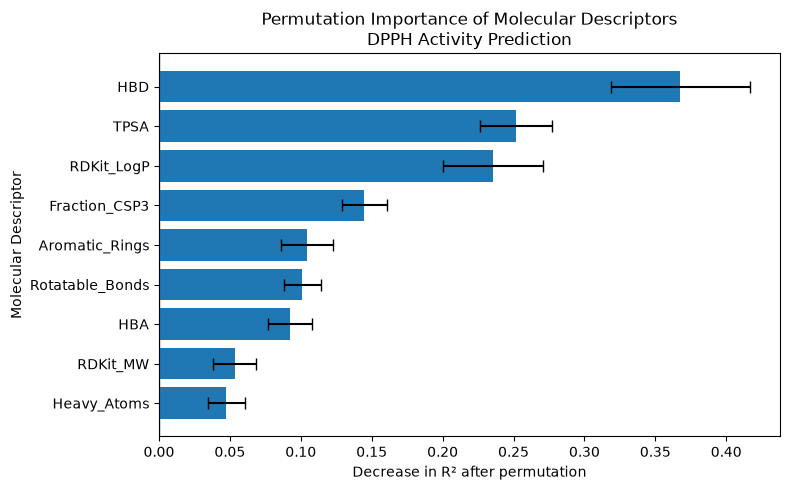

Key final figures saved successfully.


In [87]:
# ============================================================
# Save internal held-out experimental-vs-predicted activity figure
#
# Purpose:
# Create a high-resolution version of the final held-out test
# performance plot for repository and manuscript use.
# ============================================================

plt.figure(figsize=(7, 6))

plt.scatter(
    y_test,
    final_test_predictions,
    alpha=0.65
)

plot_min = min(
    y_test.min(),
    final_test_predictions.min()
)

plot_max = max(
    y_test.max(),
    final_test_predictions.max()
)

# Perfect-prediction reference line
plt.plot(
    [plot_min, plot_max],
    [plot_min, plot_max],
    linestyle="--",
    linewidth=1.5
)

plt.xlabel("Experimental pIC50")
plt.ylabel("Predicted pIC50")

plt.title(
    "Experimental vs Predicted DPPH Activity\n"
    "Internal Random Held-Out Test Set"
)

plt.text(
    0.05,
    0.95,
    f"R² = {final_test_r2:.3f}\n"
    f"RMSE = {final_test_rmse:.3f}\n"
    f"MAE = {final_test_mae:.3f}",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)

plt.tight_layout()

# Save before displaying
figure_path = (
    figures_dir /
    "internal_heldout_experimental_vs_predicted.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved to:")
print(figure_path)

# ============================================================
# Save key final figures
#
# Purpose:
# Regenerate and export the principal figures from the completed
# machine-learning analysis in PNG and SVG formats.
# ============================================================


# ------------------------------------------------------------
# FIGURE 1: Random vs scaffold-aware validation
# ------------------------------------------------------------

r2_comparison = complete_model_comparison.pivot(
    index="Model",
    columns="Validation",
    values="Mean_R2"
)

plt.figure(figsize=(10, 5))

r2_comparison.plot(
    kind="bar",
    ax=plt.gca()
)

plt.axhline(0, linewidth=1)

plt.ylabel("Mean Cross-Validated R²")
plt.xlabel("Model")

plt.title(
    "Random vs Scaffold-Aware Validation of DPPH Activity Models"
)

plt.xticks(rotation=20, ha="right")
plt.tight_layout()

plt.savefig(
    figures_dir / "random_vs_scaffold_validation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    figures_dir / "random_vs_scaffold_validation.svg",
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# FIGURE 2: Random vs scaffold-aware vs DOI-grouped validation
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.bar(
    validation_strategy_comparison["Validation_Strategy"],
    validation_strategy_comparison["Mean_R2"],
    yerr=validation_strategy_comparison["SD_R2"],
    capsize=5
)

plt.axhline(0, linewidth=1)
plt.ylabel("Mean Cross-Validated R²")
plt.xlabel("Validation Strategy")
plt.title("Effect of Validation Strategy on DPPH Activity Prediction")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()

plt.savefig(
    figures_dir / "validation_strategy_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.savefig(
    figures_dir / "validation_strategy_comparison.svg",
    bbox_inches="tight"
)
plt.show()


# ------------------------------------------------------------
# FIGURE 3: Internal held-out residual analysis
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    test_residuals,
    alpha=0.65
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1.5
)

plt.xlabel("Experimental pIC50")
plt.ylabel("Residual (Predicted - Experimental)")

plt.title(
    "Residuals of Final Model Predictions\n"
    "Internal Random Held-Out Test Set"
)

plt.tight_layout()

plt.savefig(
    figures_dir / "internal_heldout_test_residuals.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    figures_dir / "internal_heldout_test_residuals.svg",
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# FIGURE 4: Prediction error vs structural similarity
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.scatter(
    test_prediction_results["Max_Training_Tanimoto"],
    test_prediction_results["Absolute_Error"],
    alpha=0.65
)

plt.xlabel("Maximum Tanimoto Similarity to Training Set")
plt.ylabel("Absolute Prediction Error (pIC50 units)")

plt.title(
    "Prediction Error vs Structural Similarity\n"
    "Internal Random Held-Out Test Set"
)

plt.tight_layout()

plt.savefig(
    figures_dir / "internal_heldout_error_vs_tanimoto.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    figures_dir / "internal_heldout_error_vs_tanimoto.svg",
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# FIGURE 5: Descriptor permutation importance
# ------------------------------------------------------------

plot_importance = descriptor_importance.sort_values(
    "Importance_Mean"
)

plt.figure(figsize=(8, 5))

plt.barh(
    plot_importance["Descriptor"],
    plot_importance["Importance_Mean"],
    xerr=plot_importance["Importance_SD"],
    capsize=4
)

plt.axvline(0, linewidth=1)

plt.xlabel("Decrease in R² after permutation")
plt.ylabel("Molecular Descriptor")

plt.title(
    "Permutation Importance of Molecular Descriptors\n"
    "DPPH Activity Prediction"
)

plt.tight_layout()

plt.savefig(
    figures_dir / "descriptor_permutation_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    figures_dir / "descriptor_permutation_importance.svg",
    bbox_inches="tight"
)

plt.show()


print("Key final figures saved successfully.")


In [88]:
# ============================================================
# Export final model-ready DPPH dataset
#
# Purpose:
# Preserve the QC-passed experimental data together with the
# descriptors and scaffold information used in modeling.
# ============================================================

model_ready_columns = [
    "row ID",
    "Canonical SMILES",
    "inChI",
    "ChEMBL ID",
    "DOI",
    "Assay Description",
    "Molecular Weight",
    "minusLogIC50 (M)",
    "RDKit_MW",
    "RDKit_LogP",
    "HBD",
    "HBA",
    "TPSA",
    "Rotatable_Bonds",
    "Aromatic_Rings",
    "Heavy_Atoms",
    "Fraction_CSP3",
    "Murcko_Scaffold",
    "MW_Difference",
    "Absolute_MW_Difference"
]

# Keep only columns that actually exist
model_ready_columns = [
    column
    for column in model_ready_columns
    if column in model_df.columns
]

model_ready_dataset = model_df[
    model_ready_columns
].copy()

model_ready_path = (
    processed_dir /
    "dpph_model_ready_dataset.csv"
)

model_ready_dataset.to_csv(
    model_ready_path,
    index=False
)

print("Model-ready dataset saved successfully.")
print("Shape:", model_ready_dataset.shape)
print("Path:", model_ready_path)

# ============================================================
# Save Morgan fingerprint matrix
#
# Purpose:
# Preserve the complete 2,048-bit structural representation
# used by the machine-learning models.
# ============================================================

fingerprint_path = (
    processed_dir /
    "morgan_fingerprints_2048.npz"
)

np.savez_compressed(
    fingerprint_path,

    # Binary fingerprint matrix
    fingerprints=X_fp.astype(np.uint8),

    # Experimental pIC50 target aligned row-for-row
    target_pic50=y,

    # Original row order for reproducible alignment
    dataset_index=np.arange(len(model_df))
)

print("Morgan fingerprint matrix saved successfully.")
print("Fingerprint shape:", X_fp.shape)
print("Path:", fingerprint_path)

# ============================================================
# Create final standardized Tyr-Gly case-study dataset
#
# Purpose:
# Preserve experimental provenance, RDKit descriptors,
# ML predictions, and applicability-domain information for
# Compounds 50 and 51.
# ============================================================

case_study_standardized = pd.DataFrame({

    "Compound":
        case_study_compounds["Compound"],

    "SMILES":
        case_study_compounds["SMILES"],

    "Reported_IC50_mg_mL":
        case_study_compounds["Reported_IC50_mg_mL"],

    "Reported_pIC50":
        case_study_compounds["Reported_pIC50"],

    "RDKit_MW":
        case_descriptor_df["RDKit_MW"],

    "RDKit_LogP":
        case_descriptor_df["RDKit_LogP"],

    "HBD":
        case_descriptor_df["HBD"],

    "HBA":
        case_descriptor_df["HBA"],

    "TPSA":
        case_descriptor_df["TPSA"],

    "Rotatable_Bonds":
        case_descriptor_df["Rotatable_Bonds"],

    "Aromatic_Rings":
        case_descriptor_df["Aromatic_Rings"],

    "Heavy_Atoms":
        case_descriptor_df["Heavy_Atoms"],

    "Fraction_CSP3":
        case_descriptor_df["Fraction_CSP3"],

    "Predicted_pIC50":
        case_study_results["Predicted_pIC50"],

    "Predicted_IC50_mg_mL":
        case_study_results["Predicted_IC50_mg_mL"],

    "Max_Tanimoto":
        case_study_results["Max_Tanimoto"],

    "AD_Threshold":
        case_study_results["AD_Threshold"],

    "Inside_AD":
        case_study_results["Inside_AD"],

    "Scaffold_Seen_Externally":
        case_study_results["Scaffold_Seen_Externally"]
})

# Explicit provenance notes
case_study_standardized["Activity_Source"] = (
    "Reported experimental DPPH IC50 from BSc project"
)

case_study_standardized["Activity_Note"] = (
    "Reported IC50 lies below the lowest explicitly reported tested "
    "concentration; treat as reported/extrapolated value unless additional "
    "lower-concentration measurements are available."
)

case_study_standardized["Prediction_Note"] = (
    "Exploratory out-of-domain ML prediction"
)

case_study_path = (
    processed_dir /
    "tyr_gly_case_study_standardized.csv"
)

case_study_standardized.to_csv(
    case_study_path,
    index=False
)

case_study_standardized


Model-ready dataset saved successfully.
Shape: (1891, 20)
Path: C:\Users\user\Project_1_Peptide_Antioxidant_SAR\data\processed\dpph_model_ready_dataset.csv
Morgan fingerprint matrix saved successfully.
Fingerprint shape: (1891, 2048)
Path: C:\Users\user\Project_1_Peptide_Antioxidant_SAR\data\processed\morgan_fingerprints_2048.npz


,Compound,SMILES,Reported_IC50_mg_mL,Reported_pIC50,RDKit_MW,RDKit_LogP,HBD,HBA,TPSA,Rotatable_Bonds,...,Fraction_CSP3,Predicted_pIC50,Predicted_IC50_mg_mL,Max_Tanimoto,AD_Threshold,Inside_AD,Scaffold_Seen_Externally,Activity_Source,Activity_Note,Prediction_Note
0,Compound 50,O=C(NCC(=O)N1CCCCC1)C(Cc1ccc(O)cc1)NS(=O)(=O)c...,0.63,2.849547,445.541,1.41050,3.0,5.0,115.81,8.0,...,0.363636,3.857087,0.061916,0.363636,0.5,False,False,Reported experimental DPPH IC50 from BSc project,Reported IC50 lies below the lowest explicitly...,Exploratory out-of-domain ML prediction
1,Compound 51,O=C(NCC(=O)N1CCCCC1)C(Cc1ccc(O)cc1)NS(=O)(=O)c...,0.74,2.793118,459.568,1.71892,3.0,5.0,115.81,8.0,...,0.391304,3.898707,0.058029,0.333333,0.5,False,False,Reported experimental DPPH IC50 from BSc project,Reported IC50 lies below the lowest explicitly...,Exploratory out-of-domain ML prediction


# Conclusions

This study developed and critically evaluated machine-learning models for
predicting DPPH radical-scavenging activity across a curated dataset of
1,891 structurally diverse small molecules. Morgan fingerprints and RDKit
molecular descriptors were used to represent molecular structure, with
Random Forest retained as the primary predictive model and Extra Trees used
as an additional nonlinear ensemble baseline.

Molecular fingerprints contained substantially more predictive information
than the selected physicochemical descriptors alone. Combining Morgan
fingerprints with molecular descriptors produced a modest additional
improvement, indicating that global molecular properties provide complementary
information to local substructural features.

The apparent predictive performance depended strongly on the validation
strategy. For the combined Random Forest model, R² decreased from
approximately 0.712 under random five-fold cross-validation to approximately
0.447 under Bemis–Murcko scaffold-aware validation and approximately 0.124
under DOI-grouped validation. Extra Trees reproduced the same overall trend,
showing that this decrease in performance was not specific to a single
ensemble algorithm.

These results demonstrate that conventional random splitting provides an
optimistic estimate of generalization because structurally related compounds
and compounds originating from the same literature-derived experimental
series may occur across training and validation subsets. Scaffold-aware
validation therefore provides a more realistic assessment of performance for
novel molecular frameworks, while DOI-grouped validation highlights the
additional difficulty of transferring activity predictions across different
publication-derived chemical and experimental contexts.

The selected Random Forest model achieved an R² of approximately 0.79 on an
internal random held-out test set. However, 289 of the 379 held-out molecules
contained scaffolds already represented in the training data. Performance was
higher for scaffold-seen molecules (R² ≈ 0.82) than for scaffold-unseen
molecules (R² ≈ 0.58), further demonstrating the influence of structural
familiarity on predictive accuracy.

Applicability-domain analysis provided an additional measure of prediction
reliability. Held-out molecules with sufficient structural similarity to the
development set showed markedly better predictive performance than molecules
outside the similarity-based applicability domain.

Descriptor-level interpretation identified hydrogen-bond donor count, polar
surface area, lipophilicity, fraction of sp3 carbon, and aromaticity-related
properties among the influential molecular features. Fingerprint-level
analysis further identified several well-supported oxygenated aromatic
environments associated with higher DPPH activity. These relationships should
be interpreted as statistical structure–activity associations rather than
causal mechanistic effects.

The experimentally investigated sulfonamide–Tyr–Gly derivatives were used as
case studies rather than as validation compounds for a peptide-specific model.
Both compounds were structurally distant from the external modeling dataset,
possessed previously unseen Bemis–Murcko scaffolds, and fell outside the
defined applicability domain. Their predicted activities therefore represent
exploratory extrapolations. In particular, the model overpredicted their
reported experimental activities by approximately one pIC50 unit, and the
small predicted activity difference between the two derivatives was not large
relative to model uncertainty.

Overall, the study shows that machine learning can recover meaningful
structure–activity relationships within heterogeneous DPPH antioxidant data,
but predictive performance depends strongly on chemical-space coverage and
the manner in which validation is performed. The results support the use of
structure-aware validation, study-grouped validation, and applicability-domain
analysis as essential components of rigorous antioxidant QSAR modeling.